# Biblioteka Matplotlib - Część 3

## Histogram, Scatter plot i Pie chart

W tej części nauczysz się trzech kolejnych ważnych typów wykresów: histogramu do analizy rozkładów, wykresu punktowego (scatter) do badania korelacji oraz wykresu kołowego (pie) z jego ograniczeniami.

## Setup - Import bibliotek i danych

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline

In [9]:
# Wczytaj dane
df_prac = pd.read_csv('../data/pracownicy.csv')
df_pogoda = pd.read_csv('../data/pogoda.csv')
df_sprzedaz = pd.read_csv('../data/sprzedaz.csv')
df_sprzedaz['data'] = pd.to_datetime(df_sprzedaz['data'])
df_sprzedaz['wartosc_sprzedazy'] = df_sprzedaz['kwota'] * df_sprzedaz['ilosc']

print("Dane wczytane pomyślnie!")

Dane wczytane pomyślnie!


---
## 0. Wykres pudełkowy - Box plot (`boxplot`)

### Czemu to służy? Prawdziwa historia z firmowego spotkania...

Wyobraź sobie, że jesteś na spotkaniu z zarządem. Prezes pyta:
> "Jak wyglądają pensje w różnych działach? Czy są ucziwe?"

Mógłbyś pokazać średnią - ale to mówi tylko połowę prawdy. Co jeśli w IT większość zarabia 8000 zł, ale jeden senior ma 25000 zł? Średnia będzie zawyżona.

Mógłbyś pokazać histogram dla każdego działu - ale to 5 wykresów, ciężko porównać.

**Rozwiązanie: Box plot!** 

Jeden wykres pokazuje:
- Gdzie jest środek (mediana)
- Gdzie jest większość danych (pudełko = 50% środkowych wartości)
- Jaki jest rozrzut (wąsy = zakres typowych wartości)
- Czy są wartości odstające (outliers = kropki poza wąsami)

### Anatomia box plotu

```
    Outlier (wartość odstająca) →  •
                                   │
                                   │
    Maksimum (bez outliers) →  ────┬────
                               │       │
    Q3 (75% percentyl) →       ├───────┤  ← Pudełko
    Mediana (50%) →            ├───────┤     (50% środkowych
    Q1 (25% percentyl) →       ├───────┤      wartości)
                               │       │
    Minimum (bez outliers) →    ───┴────
                                   │
                                   │
    Outlier →                      •
```

**Co to znaczy w praktyce:**
- **Pudełko** (od Q1 do Q3) - tu znajduje się połowa wszystkich pracowników
- **Linia w środku** (mediana) - połowa zarabia mniej, połowa więcej
- **Wąsy** - typowy zakres pensji (bez ekstremalnych wartości)
- **Kropki** - outliers (np. prezes z pensją 3x wyższą niż reszta)

**Dokładnie: gdzie kończą się wąsy?**

Wąsy **NIE** kończą się na outlierach! Algorytm działa tak:

**Krok 1:** Oblicz **rozstęp ćwiartkowy** (ang. *interquartile range*, IQR):
```
IQR = Q3 - Q1  (wysokość pudełka)
```

**Krok 2:** Wyznacz **granice poszukiwań**:
```
Granica górna:  Q3 + 1.5 × IQR
Granica dolna:  Q1 - 1.5 × IQR
```
⚠️ **Uwaga:** To NIE są wartości, na których kończą się wąsy! To są tylko **granice zakresu**, w którym szukamy końca wąsa.

**Krok 3:** Znajdź **rzeczywiste wartości** w danych:
- **Górny wąs** = największa wartość danych ≤ *granica górna*
- **Dolny wąs** = najmniejsza wartość danych ≥ *granica dolna*

**Krok 4:** Wszystko poza wąsami → **outliery** (kropki)

---

**Przykład liczbowy:**

Dane (pensje): 2000, 5000, 6000, 7000, 8000, 9000, 10000, 15000 zł

1. **Kwartyle:**
   - Q1 = 5000 zł
   - Q3 = 8000 zł
   - IQR = 8000 - 5000 = 3000 zł

2. **Granice poszukiwań:**
   - Granica górna = 8000 + 1.5×3000 = **12500 zł** ← to nie koniec wąsa!
   - Granica dolna = 5000 - 1.5×3000 = **500 zł** ← to nie koniec wąsa!

3. **Gdzie kończą się wąsy?**
   - **Górny wąs:** szukamy największej wartości ≤ 12500 zł
     - 15000 > 12500 ❌ (outlier)
     - 10000 ≤ 12500 ✅ → **górny wąs kończy się na 10000 zł**
   - **Dolny wąs:** szukamy najmniejszej wartości ≥ 500 zł
     - 2000 ≥ 500 ✅ → **dolny wąs kończy się na 2000 zł**

4. **Outliery:** 15000 zł (kropka powyżej górnego wąsa)

---

**Kiedy używać:**
- Porównanie rozkładów między grupami (np. działy, miesiące, produkty)
- Wykrywanie wartości odstających
- Ocena "rozpiętości" danych (czy wszyscy podobnie, czy są skrajności?)

### Przykład 1: Pojedynczy box plot - pensje w firmie

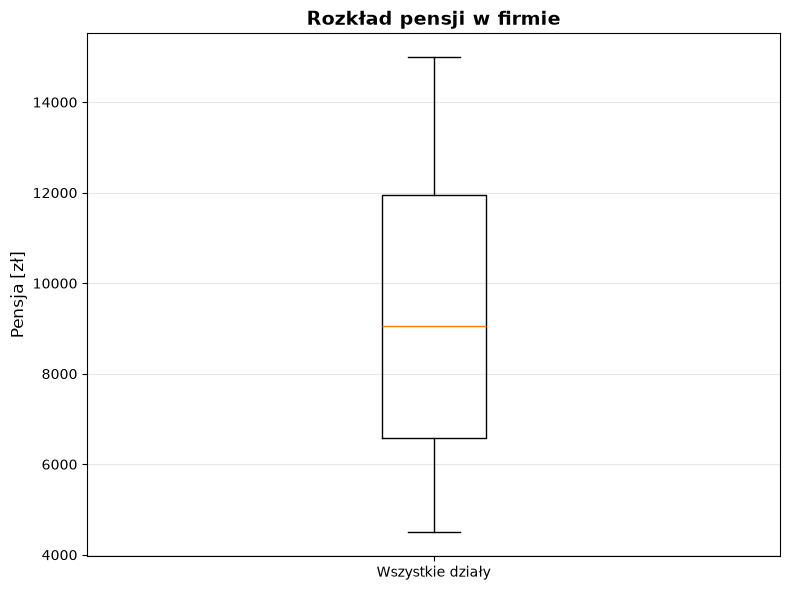

Statystyki pensji:
  Minimum: 4500.00 zł
  Q1 (25%): 6575.00 zł
  Mediana: 9050.00 zł
  Q3 (75%): 11950.00 zł
  Maximum: 15000.00 zł
  Średnia: 9268.00 zł

Czy średnia ≈ mediana? True
  (jeśli tak, rozkład jest symetryczny)


In [4]:
# Prosty box plot
fig, ax = plt.subplots(figsize=(8, 6))

...

ax.set_title('Rozkład pensji w firmie', fontsize=14, fontweight='bold')
ax.set_ylabel('Pensja [zł]', fontsize=12)
ax.set_xticklabels(['Wszystkie działy'])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statystyki dla lepszego zrozumienia
print("Statystyki pensji:")
print(f"  Minimum: {df_prac['pensja'].min():.2f} zł")
print(f"  Q1 (25%): {df_prac['pensja'].quantile(0.25):.2f} zł")
print(f"  Mediana: {df_prac['pensja'].median():.2f} zł")
print(f"  Q3 (75%): {df_prac['pensja'].quantile(0.75):.2f} zł")
print(f"  Maximum: {df_prac['pensja'].max():.2f} zł")
print(f"  Średnia: {df_prac['pensja'].mean():.2f} zł")
print(f"\nCzy średnia ≈ mediana? {abs(df_prac['pensja'].mean() - df_prac['pensja'].median()) < 500}")
print("  (jeśli tak, rozkład jest symetryczny)")

### Przykład 2: Porównanie działów - tu box plot błyszczy!

Teraz prawdziwa moc box plota - porównanie wielu grup jednocześnie:

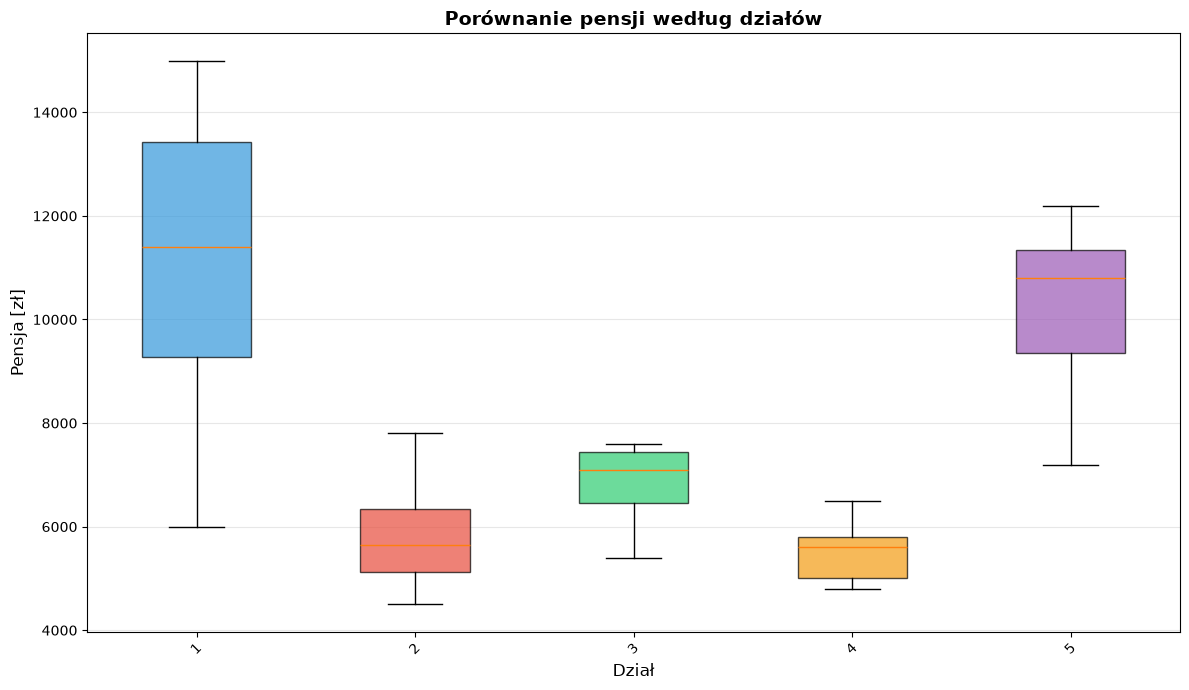

Co widzimy na wykresie?
  • Który dział ma najwyższą medianę?
  • Który dział ma największy rozrzut pensji?
  • Czy są outliers (wysokie pensje)?


In [4]:
# Box plot dla każdego działu
fig, ax = plt.subplots(figsize=(12, 7))

# Przygotuj dane - lista wartości dla każdego działu
dzialy = df_prac['dzial'].unique()
dane_boxplot = [df_prac[df_prac['dzial'] == dzial]['pensja'].values for dzial in dzialy]

# Utwórz box plot
# patch_artist=True - pozwala wypełnić pudełka kolorem (inaczej są tylko obramowania)
bp = ax.boxplot(dane_boxplot, labels=dzialy, patch_artist=True)

# Kolorowanie pudełek
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
for patch, color in zip(bp['boxes'], colors[:len(dzialy)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Porównanie pensji według działów', fontsize=14, fontweight='bold')
ax.set_xlabel('Dział', fontsize=12)
ax.set_ylabel('Pensja [zł]', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Dodaj etykiety na osi X
ax.set_xticklabels(dzialy, rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n📊 Interpretacja box plot:")
print("  • Pudełko (box) - zakres 25%-75% danych (IQR - interquartile range)")
print("  • Linia w środku - mediana (50% danych)")
print("  • Wąsy (whiskers) - 1.5 × IQR")
print("  • Punkty poza wąsami - wartości odstające (outliers)")

### Przykład 3: Box plot vs Seaborn box plot

**Mała podpowiedź:** Za chwilę poznasz Seaborn - bibliotekę, która robi piękniejsze wykresy łatwiej.

Porównajmy szybko matplotlib boxplot z seaborn boxplot:

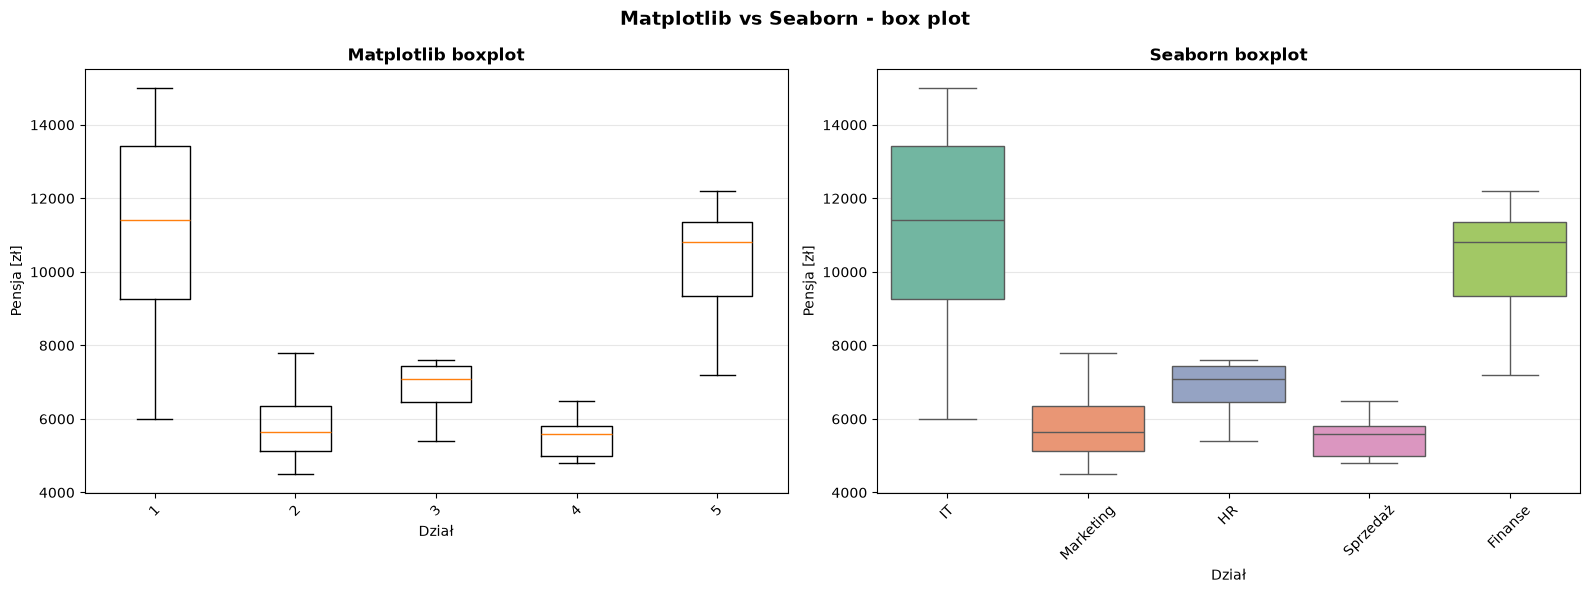

Seaborn jest prostszy w użyciu (mniej kodu), ale matplotlib daje większą kontrolę!
Oba mają swoje miejsce w twoim arsenale.


In [6]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matplotlib boxplot (lewy)
dane_boxplot = [df_prac[df_prac['dzial'] == dzial]['pensja'].values for dzial in dzialy]
axes[0].boxplot(dane_boxplot, label=dzialy)
axes[0].set_title('Matplotlib boxplot', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dział')
axes[0].set_ylabel('Pensja [zł]')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Seaborn boxplot (prawy) (Przekazujemy obiekt axes[1] DO funkcji `boxplot` jako parametr)
sns.boxplot(data=df_prac, x='dzial', y='pensja', hue='dzial', ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Seaborn boxplot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dział')
axes[1].set_ylabel('Pensja [zł]')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Matplotlib vs Seaborn - box plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Seaborn jest prostszy w użyciu (mniej kodu), ale matplotlib daje większą kontrolę!")
print("Oba mają swoje miejsce w twoim arsenale.")

## ---
## Ćwiczenie 0.1 (w trakcie) - Box plot temperatur według miesięcy

**Cel:** Zobaczyć jak temperatura zmienia się w ciągu roku.

**Zadanie:**
1. Z danych pogodowych wyciągnij miesiąc z kolumny 'data'
   - Podpowiedź: `df_pogoda['data'] = pd.to_datetime(df_pogoda['data'])`
   - Potem: `df_pogoda['miesiac'] = df_pogoda['data'].dt.month`
2. Przygotuj listę danych temperatury dla każdego miesiąca (1-12)
3. Utwórz box plot pokazujący rozkład temperatur w każdym miesiącu
4. Dodaj tytuł "Rozkład temperatur według miesięcy"
5. Opisy osi: "Miesiąc" i "Temperatura [°C]"
6. Zastanów się:
   - W którym miesiącu jest największy rozrzut temperatur?
   - Czy są outliers (nietypowo zimne/ciepłe dni)?

**Czas:** 15 minut

In [ ]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Przygotowanie danych
df_pogoda['data'] = pd.to_datetime(df_pogoda['data'])
df_pogoda['miesiac'] = df_pogoda['data'].dt.month

# Przygotuj dane dla box plota
miesiace = range(1, 13)
dane_temp_miesiace = [df_pogoda[df_pogoda['miesiac'] == m]['temperatura'].values for m in miesiace]

# Utworzenie wykresu
fig, ax = plt.subplots(figsize=(14, 6))

# patch_artist=True - pozwala wypełnić pudełka kolorem
bp = ax.boxplot(dane_temp_miesiace, labels=miesiace, patch_artist=True)

# Kolorowanie sezonowe
kolory_sezonowe = [
    '#5DADE2', '#5DADE2', '#A9DFBF',  # Zima/Wiosna (sty-mar)
    '#F8C471', '#F8C471', '#E67E22',  # Wiosna/Lato (kwi-cze)
    '#E59866', '#E59866', '#D35400',  # Lato/Jesień (lip-wrz)
    '#A569BD', '#5499C7', '#5DADE2'   # Jesień/Zima (paź-gru)
]

for patch, color in zip(bp['boxes'], kolory_sezonowe):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title('Rozkład temperatur według miesięcy', fontsize=14, fontweight='bold')
ax.set_xlabel('Miesiąc', fontsize=12)
ax.set_ylabel('Temperatura [°C]', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Dodaj nazwy miesięcy
nazwy_miesiecy = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze', 
                  'Lip', 'Sie', 'Wrz', 'Paź', 'Lis', 'Gru']
ax.set_xticklabels(nazwy_miesiecy)

plt.tight_layout()
plt.show()

# Analiza
print("\nAnaliza rozkładu temperatur:")
print("="*50)
for i, miesiac in enumerate(nazwy_miesiecy, 1):
    dane_m = df_pogoda[df_pogoda['miesiac'] == i]['temperatura']
    if len(dane_m) > 0:
        print(f"{miesiac}: mediana={dane_m.median():.1f}°C, rozrzut={dane_m.std():.1f}°C")
```

</details>

**Kluczowe spostrzeżenia z box plota:**

✅ Box plot świetnie pokazuje:
- Różnice między grupami (mediany)
- Rozpiętość danych (wysokość pudełek i wąsów)
- Wartości odstające (kropki)
- Symetrię rozkładu (czy mediana jest w środku pudełka?)

⚠️ Ale pamiętaj:
- Box plot NIE pokazuje liczby obserwacji (czy w grupie jest 5 czy 500 osób?)
- NIE pokazuje kształtu rozkładu (bimodalny? normalny?)
- Dla małych zbiorów (<10 obs) lepszy jest scatter plot lub bar chart

**Gdy użyć box plot:**
- Porównanie 3+ grup
- Wykrywanie outliers
- Szybki przegląd rozrzutu danych

**Alternatywy:**
- Violin plot (pokazuje kształt rozkładu) - poznasz w Seaborn!
- Histogram (dla pojedynczej zmiennej)
- Scatter plot (dla małych zbiorów)

## 1. Histogram (`hist`)

Histogram pokazuje **rozkład** wartości - ile obserwacji przypada na każdy przedział (bin).

**Kiedy używać:**
- Badanie rozkładu zmiennej (normalny, skośny, etc.)
- Identyfikacja wartości odstających
- Sprawdzenie, czy dane są symetryczne

**Różnica między histogramem a wykresem słupkowym:**
- **Histogram**: oś X to **przedziały wartości** (ciągłe), oś Y to **częstość**
- **Wykres słupkowy**: oś X to **kategorie** (dyskretne), oś Y to **wartość**

### Przykład 1: Histogram pensji

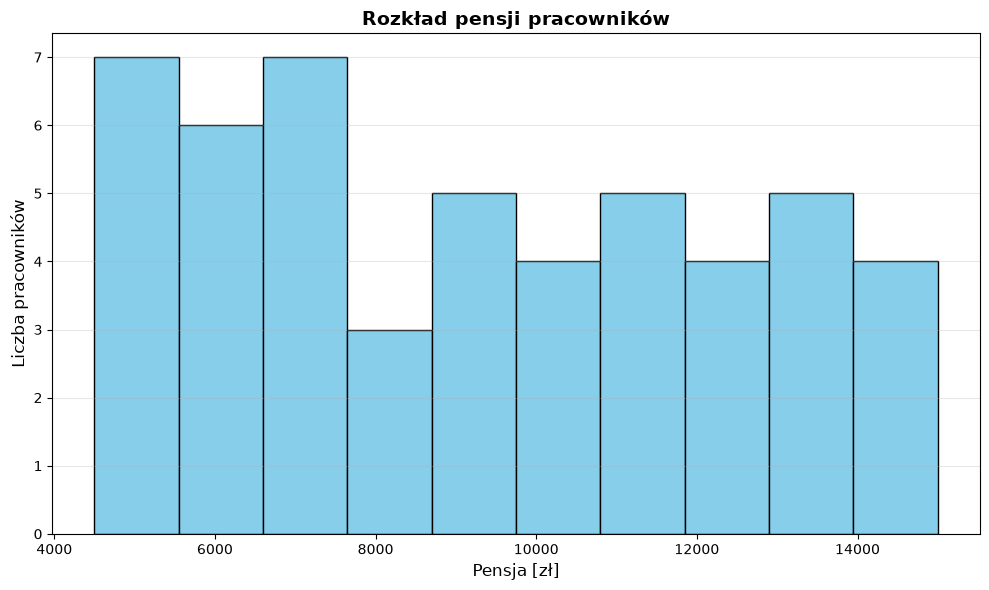

In [7]:
# Prosty histogram pensji
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df_prac['pensja'], bins=10, color='skyblue', edgecolor='black')

ax.set_title('Rozkład pensji pracowników', fontsize=14, fontweight='bold')
ax.set_xlabel('Pensja [zł]', fontsize=12)
ax.set_ylabel('Liczba pracowników', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Parametr `bins` - kluczowy parametr histogramu

Parametr `bins` kontroluje liczbę przedziałów:
- Za mało bins → zbyt ogólny obraz
- Za dużo bins → zbyt szczegółowy, "zaszumiony" obraz

Wypróbujmy różne wartości:

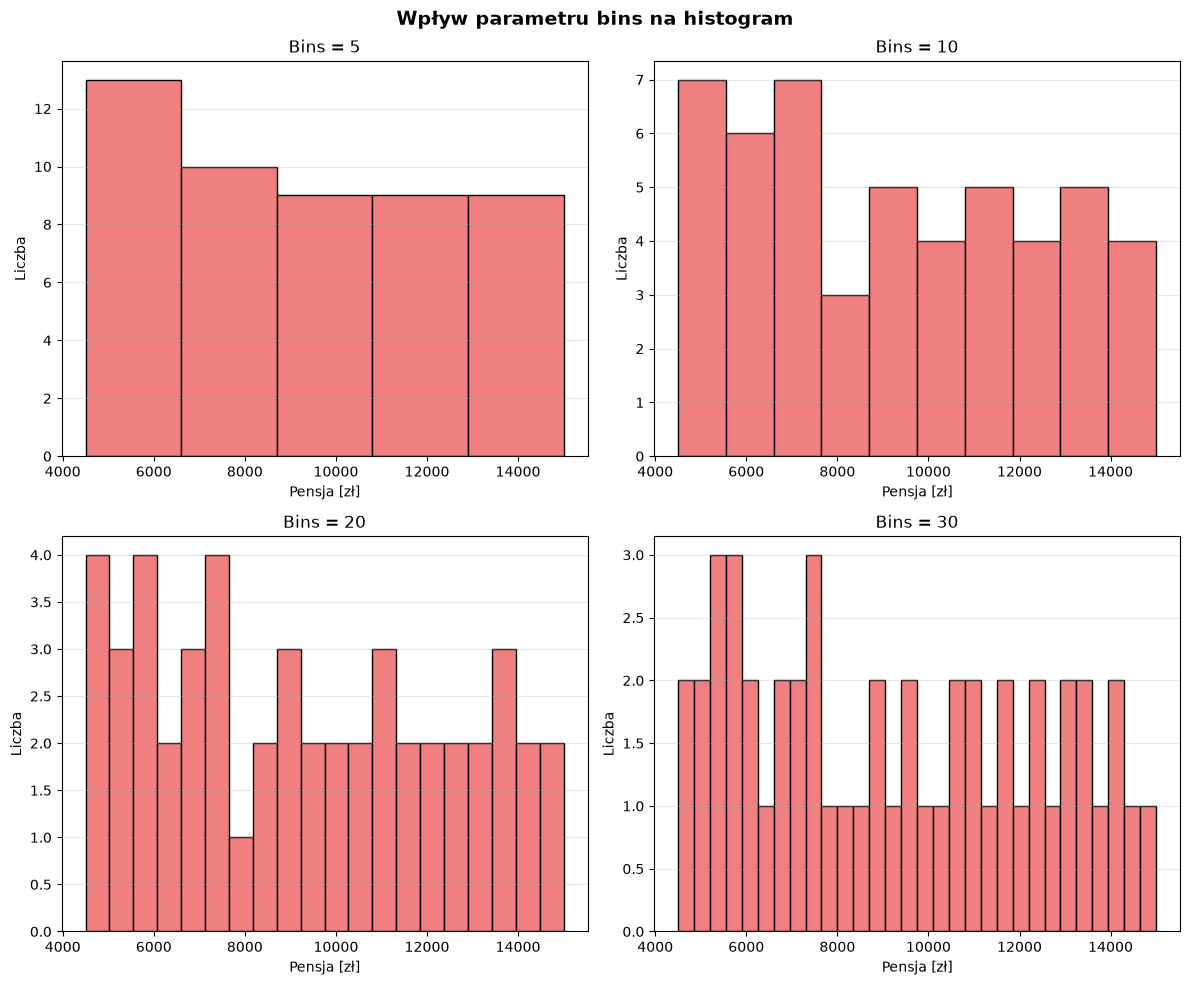

In [3]:
# Porównanie różnych bins
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

bins_values = [5, 10, 20, 30]
axes = axes.ravel()  # Spłaszcz tablicę 2D do 1D

for i, bins in enumerate(bins_values):
    axes[i].hist(df_prac['pensja'], bins=bins, color='lightcoral', edgecolor='black')
    axes[i].set_title(f'Bins = {bins}', fontsize=12)
    axes[i].set_xlabel('Pensja [zł]')
    axes[i].set_ylabel('Liczba')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Wpływ parametru bins na histogram', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Wnioski:**
- bins=5: Za mało szczegółów
- bins=10-15: Zazwyczaj dobry kompromis
- bins=30: Może być za dużo dla małych zbiorów

**Zasada:** Dla małych zbiorów (< 100 obserwacji) używaj 5-15 bins, dla dużych (> 1000) możesz użyć 20-50.

### Przykład 2: Histogram z linią gęstości (KDE)

**Czym jest KDE?**

**KDE** (*Kernel Density Estimation*, pol. **krzywa gęstości prawdopodobieństwa** aka jądrowy estymator gęstości) to metoda tworzenia **wygładzonej krzywej** pokazującej rozkład danych.

**Po co?**
- Histogram ma "schodki" (skoki między binami) - trudno zobaczyć płynny kształt rozkładu
- KDE to **ciągła, gładka krzywa** - łatwiej zobaczyć ogólny trend
- Odpowiada na pytanie: "Jak prawdopodobne jest, że wartość pojawi się w okolicy tego punktu?"

**Kiedy używać:**
- Chcesz zobaczyć **kształt rozkładu** (czy jest symetryczny, skośny, dwumodalny?)
- Potrzebujesz **estetycznej wizualizacji** bez "schodków"
- Masz **dużo danych** (dla małych zbiorów lepszy histogram)

**Histogram vs KDE:**
```
Histogram:  ▂▅▇█▆▃▁   ← Schodki, zależy od bins

KDE:        ╱─╲      ← Gładka krzywa, pokazuje ogólny trend
```

**W praktyce:** Często łączy się oba - histogram (pokazuje konkretne zliczenia) + KDE (pokazuje ogólny kształt)

In [10]:
!pip install scipy


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


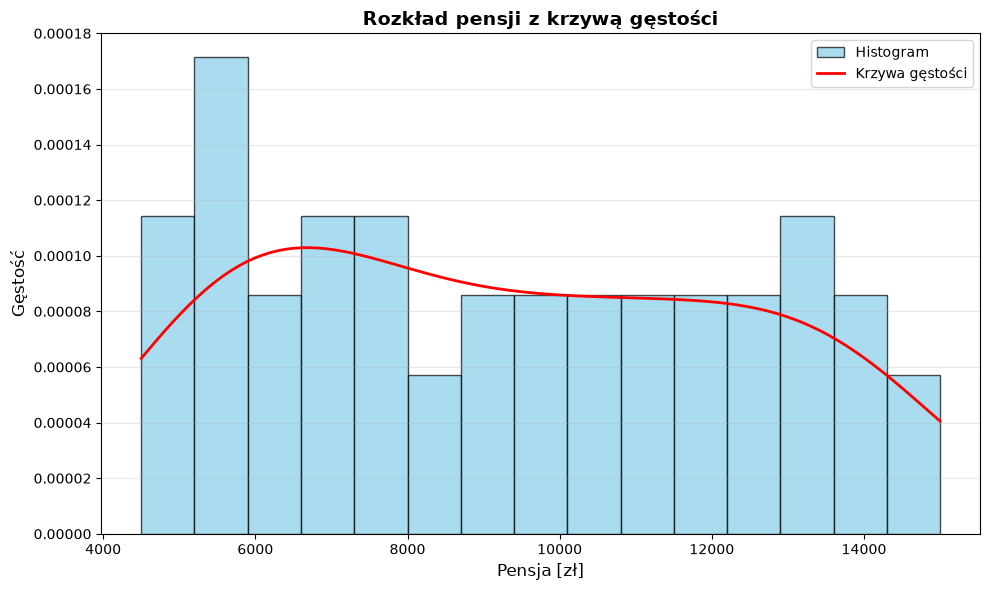

In [6]:
from scipy import stats

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram z normalizacją (density=True)
ax.hist(df_prac['pensja'], bins=15, density=True, alpha=0.7, 
        color='skyblue', edgecolor='black', label='Histogram')

# Linia gęstości
kde = stats.gaussian_kde(df_prac['pensja'])
x_range = np.linspace(df_prac['pensja'].min(), df_prac['pensja'].max(), 100)
ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='Krzywa gęstości')

ax.set_title('Rozkład pensji z krzywą gęstości', fontsize=14, fontweight='bold')
ax.set_xlabel('Pensja [zł]', fontsize=12)
ax.set_ylabel('Gęstość', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**💡 Co oznacza `density=True` (normalizacja histogramu)?**

Bez normalizacji histogram i KDE mają **różne skale** - nie da się ich pokazać razem na jednym wykresie!

**`density=False` (domyślnie):**
- Oś Y = **liczba obserwacji** w każdym binie
- Przykład: "25 osób zarabia 5000-7000 zł"
- **Nie pasuje do KDE** (KDE pokazuje gęstość, nie liczby, a pole pod jej wykresem wynosi 1)

**`density=True` (normalizacja):**
- Oś Y = **gęstość prawdopodobieństwa** (0 do ~1)
- Pole pod histogramem = 1 (100% wszystkich danych)
- **Pasuje do KDE** - obie krzywe na tej samej skali!

**Zasada:** Jeśli chcesz połączyć histogram z KDE → **ZAWSZE** użyj `density=True`!

**💡 Co robią `stats.gaussian_kde()` i `np.linspace()`?**

---

**1. `stats.gaussian_kde(dane)` - tworzy "funkcję gęstości"**

```python
kde = stats.gaussian_kde(df_prac['pensja'])
```

Co to robi:
- Analizuje dane (pensje: 5000, 8000, 12000, ...)
- Tworzy **model gęstości** - funkcję, która dla każdej wartości X zwraca "jak gęsto są dane w okolicy X"
- Zwraca **obiekt funkcyjny** - możesz go wywołać: `kde(7000)` → zwróci gęstość w okolicy 7000 zł

**Analogia:** Masz punkty na mapie (pensje). KDE to "mapa ciepła" pokazująca gdzie jest gęsto, a gdzie pusto.

---

**2. `np.linspace(start, stop, ile_punktów)` - generuje równomiernie rozłożone punkty**

```python
x_range = np.linspace(3000, 15000, 100)
# Wynik: [3000, 3120, 3240, ..., 14880, 15000]  ← 100 równych odstępów
```

Co to robi:
- Dzieli zakres od `start` do `stop` na `ile_punktów` **równych części**
- Zwraca tablicę z tymi wartościami

**Po co?** Żeby narysować **gładką krzywą**, potrzebujesz wielu punktów (100, nie tylko 5). Linspace generuje te punkty.

---

**Razem:**
```python
kde = stats.gaussian_kde(df_prac['pensja'])           # Stwórz model gęstości
x_range = np.linspace(min_pensja, max_pensja, 100)   # 100 punktów na osi X
y_values = kde(x_range)                               # Oblicz gęstość dla każdego punktu
ax.plot(x_range, y_values)                            # Narysuj krzywą
```

**Wizualizacja:**
```
Pensje w danych:      ●    ●●  ●     ●   (nieregularne)
linspace generuje:    | | | | | | | | |  (równe odstępy, gęste)
kde oblicza gęstość:  ▁▃▅█▇▅▃▂▁         (wysokość krzywej)
Wynik:                   ╱──╲            (gładka krzywa)
```

---
## Ćwiczenie 1.1 (w trakcie) - Histogram temperatur

**Cel:** Zbadać rozkład temperatur.

**Zadanie:**
1. Utwórz histogram dla kolumny 'temperatura' z danych pogodowych
2. Użyj 20 bins
3. Dodaj tytuł, opisy osi
4. Użyj koloru 'orange' dla słupków
5. Dodaj czarną krawędź słupków
6. Na podstawie histogramu odpowiedz:
   - Czy rozkład jest symetryczny?
   - Jaki jest najczęstszy przedział temperatur?

**Czas:** 10 minut

In [8]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df_pogoda['temperatura'], bins=20, color='orange', edgecolor='black')

ax.set_title('Rozkład temperatur', fontsize=14, fontweight='bold')
ax.set_xlabel('Temperatura [°C]', fontsize=12)
ax.set_ylabel('Liczba dni', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Dodaj linię dla średniej
mean_temp = df_pogoda['temperatura'].mean()
ax.axvline(mean_temp, color='red', linestyle='--', linewidth=2, 
           label=f'Średnia: {mean_temp:.1f}°C')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Średnia temperatura: {mean_temp:.2f}°C")
print(f"Mediana: {df_pogoda['temperatura'].median():.2f}°C")
print(f"Min: {df_pogoda['temperatura'].min():.2f}°C")
print(f"Max: {df_pogoda['temperatura'].max():.2f}°C")

# Wnioski:
# - Rozkład wygląda dość równomiernie (różne pory roku)
# - Najczęstsze temperatury to około 10-20°C
```

</details>

---
## Ćwiczenie 1.2 (do domu) - Porównanie histogramów

**Cel:** Porównać rozkład wieku i stażu pracowników.

**Zadanie:**
1. Utwórz figurę z dwoma wykresami obok siebie (1 rząd, 2 kolumny)
2. Lewy wykres: histogram wieku
3. Prawy wykres: histogram stażu
4. Użyj tej samej liczby bins dla obu (np. 12)
5. Dodaj tytuły, opisy osi dla każdego wykresu
6. Dodaj główny tytuł dla całej figury
7. Porównaj rozkłady - który jest bardziej równomierny?

**Wskazówka:** Użyj `fig, axes = plt.subplots(1, 2, figsize=(14, 5))`

**Czas:** 15 minut

In [10]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lewy wykres - wiek
axes[0].hist(df_prac['wiek'], bins=12, color='#3498db', edgecolor='black')
axes[0].set_title('Rozkład wieku pracowników', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Wiek [lata]', fontsize=11)
axes[0].set_ylabel('Liczba pracowników', fontsize=11)
axes[0].axvline(df_prac['wiek'].mean(), color='red', linestyle='--', 
                label=f"Średnia: {df_prac['wiek'].mean():.1f}")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Prawy wykres - staż
axes[1].hist(df_prac['staz'], bins=12, color='#2ecc71', edgecolor='black')
axes[1].set_title('Rozkład stażu pracowników', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Staż [lata]', fontsize=11)
axes[1].set_ylabel('Liczba pracowników', fontsize=11)
axes[1].axvline(df_prac['staz'].mean(), color='red', linestyle='--', 
                label=f"Średnia: {df_prac['staz'].mean():.1f}")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Porównanie rozkładu wieku i stażu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Analiza
print("Wiek:")
print(f"  Średnia: {df_prac['wiek'].mean():.1f}, Odchylenie std: {df_prac['wiek'].std():.1f}")
print("\nStaż:")
print(f"  Średnia: {df_prac['staz'].mean():.1f}, Odchylenie std: {df_prac['staz'].std():.1f}")
```

</details>

---
## 2. Wykres punktowy - Scatter plot (`scatter`)

Wykres punktowy pokazuje **związek między dwiema zmiennymi**.

**Kiedy używać:**
- Badanie korelacji między zmiennymi
- Identyfikacja wzorców i grup
- Wykrywanie wartości odstających

**Przykłady:**
- Czy starsi pracownicy zarabiają więcej?
- Czy większe opady oznaczają niższą temperaturę?
- Czy dłuższy staż wiąże się z wyższą pensją?

### Przykład 1: Wiek vs Pensja

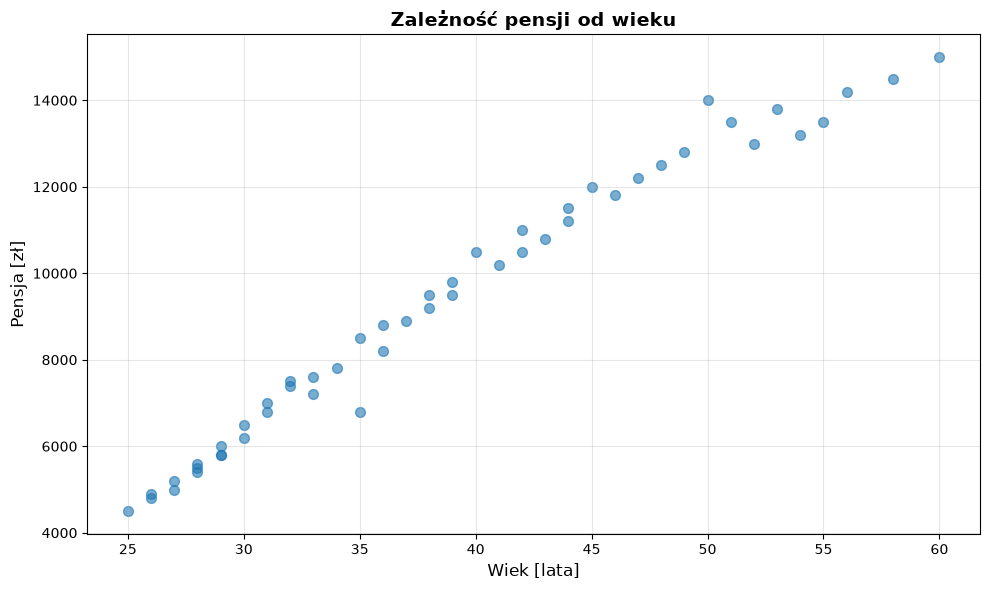

Korelacja wiek-pensja: 0.987


In [11]:
# Prosty scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_prac['wiek'], df_prac['pensja'], alpha=0.6, s=50)

ax.set_title('Zależność pensji od wieku', fontsize=14, fontweight='bold')
ax.set_xlabel('Wiek [lata]', fontsize=12)
ax.set_ylabel('Pensja [zł]', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Korelacja
correlation = df_prac['wiek'].corr(df_prac['pensja'])
print(f"Korelacja wiek-pensja: {correlation:.3f}")

**💡 Podstawowe parametry `ax.scatter()`**

```python
ax.scatter(x, y, s=50, alpha=0.6, c='blue', marker='o')
```

- **`s`** - **size** (rozmiar punktów)
  - `s=50` → małe punkty (domyślnie)
  - `s=200` → duże punkty
  - Może być liczbą (wszystkie punkty tej samej wielkości) lub tablicą (każdy punkt inny rozmiar)

- **`alpha`** - **przezroczystość** (0.0 = niewidoczne, 1.0 = nieprzezroczyste)
  - `alpha=0.3` → bardzo przezroczyste (widać nakładające się punkty)
  - `alpha=1.0` → nieprzezroczyste
  - Przydatne gdy punkty się nakładają

- **`c`** - **color** (kolor punktów)
  - `c='blue'` → wszystkie punkty niebieskie
  - `c=df['kategoria']` → kolor zależy od wartości w kolumnie

- **`marker`** - **kształt punktu**
  - `'o'` → kółko (domyślnie)
  - `'s'` → kwadrat
  - `'^'` → trójkąt
  - `'*'` → gwiazdka

### Przykład 2: Kolorowanie według kategorii

Możemy użyć koloru do pokazania trzeciej zmiennej (kategorii):

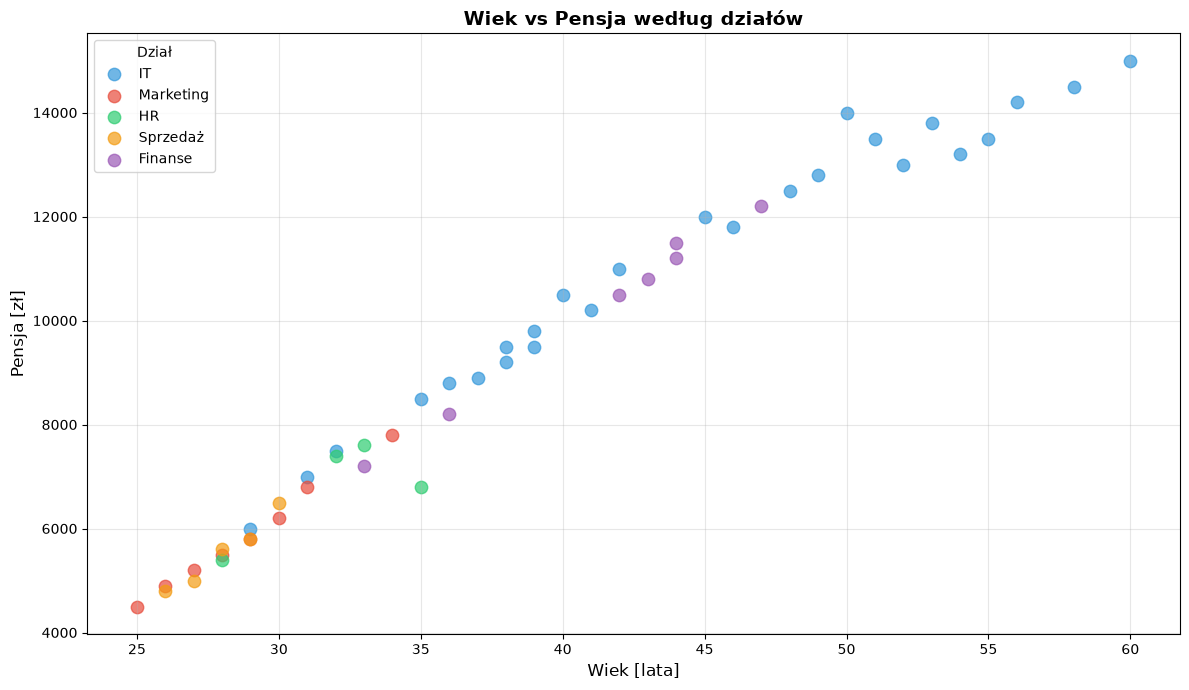

In [12]:
# Scatter plot z kolorowaniem według działów
fig, ax = plt.subplots(figsize=(12, 7))

dzialy = df_prac['dzial'].unique()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, dzial in enumerate(dzialy):
    dane_dzialu = df_prac[df_prac['dzial'] == dzial]
    ax.scatter(dane_dzialu['wiek'], dane_dzialu['pensja'], 
               label=dzial, alpha=0.7, s=80, color=colors[i])

ax.set_title('Wiek vs Pensja według działów', fontsize=14, fontweight='bold')
ax.set_xlabel('Wiek [lata]', fontsize=12)
ax.set_ylabel('Pensja [zł]', fontsize=12)
ax.legend(title='Dział')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Przykład 3: Rozmiar punktów jako czwarta zmienna

Możemy użyć rozmiaru punktów do pokazania czwartej zmiennej:

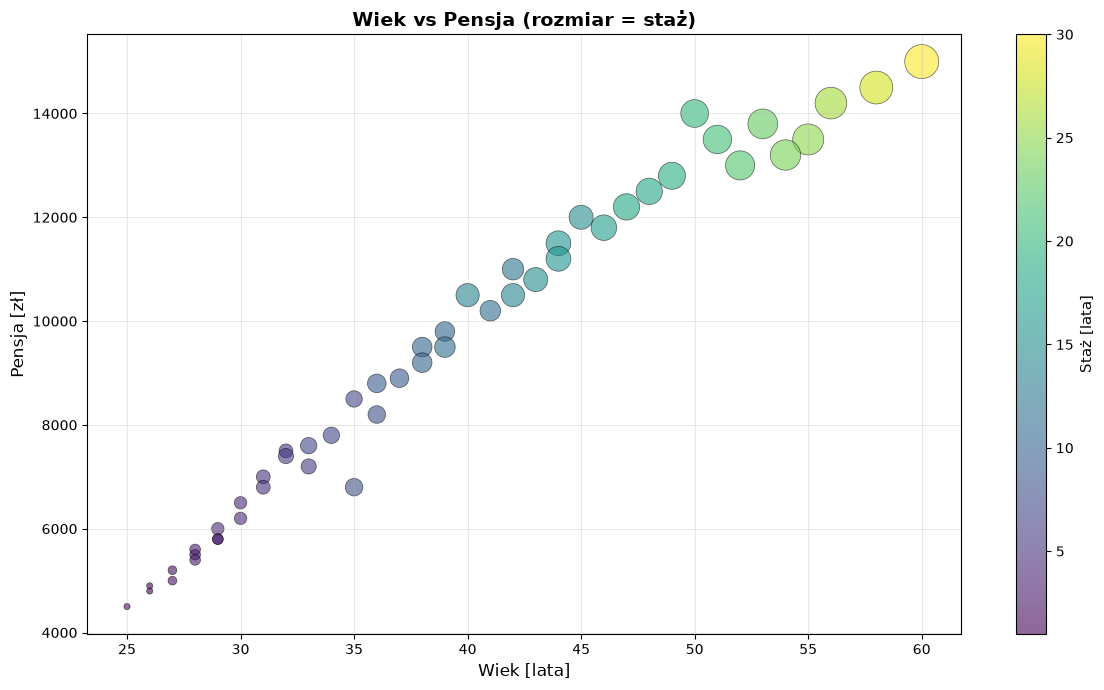

In [13]:
# Rozmiar punktu = staż pracy
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(df_prac['wiek'], df_prac['pensja'], 
                     s=df_prac['staz']*20,  # Rozmiar zależy od stażu
                     c=df_prac['staz'],      # Kolor też zależy od stażu
                     cmap='viridis',         # Paleta kolorów
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=0.5)

# Dodaj colorbar (legendę kolorów)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Staż [lata]', fontsize=11)

ax.set_title('Wiek vs Pensja (rozmiar = staż)', fontsize=14, fontweight='bold')
ax.set_xlabel('Wiek [lata]', fontsize=12)
ax.set_ylabel('Pensja [zł]', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**💡 Co to jest `cmap` (color map / paleta kolorów)?**

`cmap` to **mapa kolorów** - określa jak wartości numeryczne są przekształcane na kolory.

**Jak to działa:**
1. Masz wartości liczbowe (np. staż: 1, 5, 10, 15 lat)
2. `cmap` przekształca je na kolory (np. 1→żółty, 5→zielony, 10→niebieski, 15→fioletowy)
3. Matplotlib automatycznie tworzy **płynny gradient** między kolorami

**Przykład:**
```python
ax.scatter(x, y, c=df['staz'], cmap='viridis')
```
- `c=df['staz']` → kolor zależy od wartości stażu
- `cmap='viridis'` → małe wartości = żółty, duże = fioletowy

**Najpopularniejsze mapy kolorów:**
- `'viridis'` - uniwersalna, czytelna dla daltonistów (żółty→zielony→niebieski→fioletowy)
- `'coolwarm'` - niebieskie (zimno) → czerwone (gorąco), intuicyjna dla temperatury
- `'RdYlGn'` - czerwony→żółty→zielony, dobra dla wartości dodatnich/ujemnych
- `'Blues'`, `'Reds'` - jeden kolor od jasnego do ciemnego
- 
**Wizualizacja najpopularniejszych map kolorów:**

Zobaczmy jak wyglądają najpopularniejsze `cmap` - od wartości minimalnej (lewa strona) do maksymalnej (prawa strona):

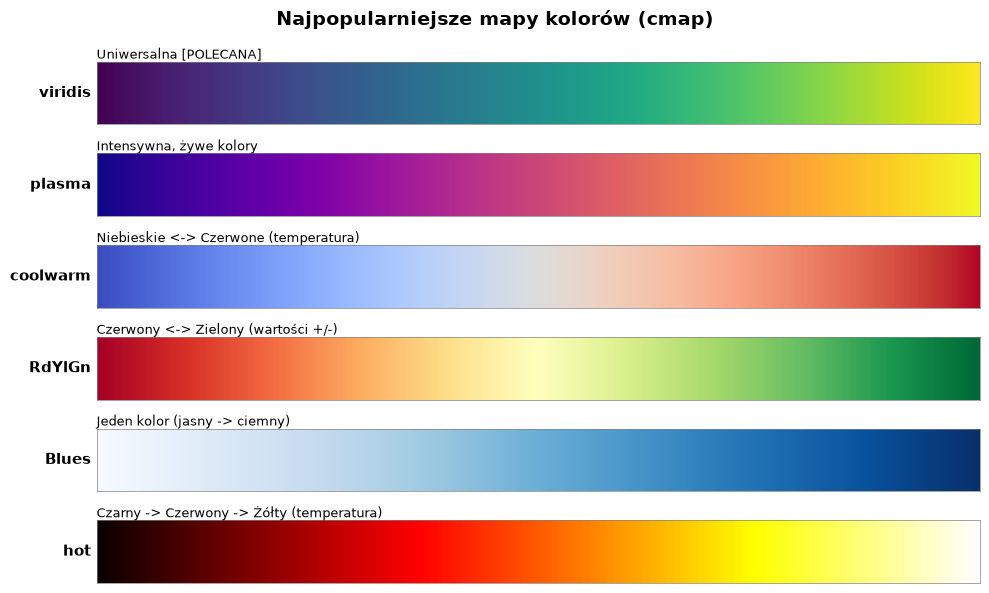

Wybieraj mapę kolorów odpowiednio do typu danych:
   - Wartości rosnące (staż, wiek) -> 'viridis', 'Blues'
   - Temperatura -> 'coolwarm', 'hot'
   - Wartości dodatnie/ujemne -> 'RdYlGn', 'RdBu'


In [14]:
# Najpopularniejsze mapy kolorów
cmaps = {
    'viridis': 'Uniwersalna [POLECANA]',
    'plasma': 'Intensywna, żywe kolory',
    'coolwarm': 'Niebieskie <-> Czerwone (temperatura)',
    'RdYlGn': 'Czerwony <-> Zielony (wartości +/-)',
    'Blues': 'Jeden kolor (jasny -> ciemny)',
    'hot': 'Czarny -> Czerwony -> Żółty (temperatura)'
}

# Gradient od 0 do 1 (256 wartości)
gradient = np.linspace(0, 1, 256).reshape(1, -1)

fig, axes = plt.subplots(len(cmaps), 1, figsize=(10, 6))

for ax, (cmap_name, opis) in zip(axes, cmaps.items()):
    # Rysuj gradient z daną mapą kolorów
    ax.imshow(gradient, aspect='auto', cmap=cmap_name)
    
    # Usuń osie, dodaj opis
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(cmap_name, fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')
    ax.set_title(opis, fontsize=9, loc='left', pad=2)
    
    # Ramka
    for spine in ax.spines.values():
        spine.set_edgecolor('gray')
        spine.set_linewidth(0.5)

plt.suptitle('Najpopularniejsze mapy kolorów (cmap)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("Wybieraj mapę kolorów odpowiednio do typu danych:")
print("   - Wartości rosnące (staż, wiek) -> 'viridis', 'Blues'")
print("   - Temperatura -> 'coolwarm', 'hot'")
print("   - Wartości dodatnie/ujemne -> 'RdYlGn', 'RdBu'")

---
## Ćwiczenie 2.0.1 (w trakcie) - Scatter plot: temperatura vs opady

**Cel:** Zbadać zależność między temperaturą a opadami.

**Zadanie:**
1. Utwórz scatter plot z danymi pogodowymi
2. Oś X: temperatura
3. Oś Y: opady
4. Dodaj tytuł i opisy osi
5. Oblicz i wyświetl korelację między temperaturą a opadami
6. Na podstawie wykresu odpowiedz:
   - Czy jest jakaś zależność między temperaturą a opadami?
   - Czy widzisz jakieś wzorce?

**Wskazówka:** Użyj `df['kolumna1'].corr(df['kolumna2'])` do obliczenia korelacji

**Czas:** 10 minut

In [15]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_pogoda['temperatura'], df_pogoda['opady'], 
           alpha=0.6, s=50, color='steelblue', edgecolor='black', linewidth=0.5)

ax.set_title('Zależność opadów od temperatury', fontsize=14, fontweight='bold')
ax.set_xlabel('Temperatura [°C]', fontsize=12)
ax.set_ylabel('Opady [mm]', fontsize=12)
ax.grid(True, alpha=0.3)

# Oblicz korelację
corr = df_pogoda['temperatura'].corr(df_pogoda['opady'])
ax.text(0.05, 0.95, f'Korelacja: {corr:.3f}', 
        transform=ax.transAxes, fontsize=11, 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        verticalalignment='top')

plt.tight_layout()
plt.show()

print(f"Korelacja: {corr:.3f}")
if abs(corr) < 0.3:
    print("Słaba korelacja - brak wyraźnej zależności liniowej")
elif abs(corr) < 0.7:
    print("Umiarkowana korelacja")
else:
    print("Silna korelacja")
```

</details>

---

## 2.1. Paleta kolorów - Colorbar (legenda dla kolorów)

### Historia z raportu sprzedażowego - kiedy kolor ma znaczenie

Dyrektor sprzedaży przychodzi z pytaniem:

> "Mam scatter plot pokazujący wiek i pensję pracowników. **Użyłem koloru, żeby pokazać staż pracy** - niebieskie to nowi pracownicy, czerwone to weterani. Ale jak moi odbiorcy mają wiedzieć, **który kolor oznacza ile lat stażu?** Potrzebuję jakiejś legendy dla kolorów!"

Właśnie do tego służy **colorbar** - to legenda pokazująca, **co oznaczają kolory na wykresie**.

---

### Kiedy używać colorbar?

✅ **Użyj colorbar gdy:**
- Używasz kolorów do zakodowania **trzeciej zmiennej** na scatter plot (obok X i Y)
- Kolor reprezentuje **wartość ciągłą** (temperatura, pensja, wiek, itp.)
- Chcesz pokazać **skalę kolorystyczną** (od niskich do wysokich wartości)
- Masz heatmap, contour plot lub inny wykres z gradientem kolorów

❌ **Nie używaj colorbar gdy:**
- Kolory reprezentują kategorie (użyj zwykłej legendy: `plt.legend()`)
- Masz tylko 2-3 kolory dyskretne (lepiej użyć legendy z etykietami)

---

### Jak działa colorbar?

**Krok 1:** Utwórz scatter plot z kolorami reprezentującymi wartości
```python
scatter = ax.scatter(x, y, c=wartosci, cmap='viridis')  # c=wartosci dla każdego punktu
```

**Krok 2:** Dodaj colorbar
```python
plt.colorbar(scatter, label='Nazwa zmiennej')
```

**Kluczowe parametry:**
- `c=` w `scatter()` - wartości określające kolor każdego punktu
- `cmap=` - paleta kolorów ('viridis', 'plasma', 'coolwarm', 'RdYlGn', itp.)
- `vmin=`, `vmax=` - zakres wartości dla kolorów (automatycznie jeśli nie podasz)

---

### Przykład 1: Podstawowy colorbar - wiek vs pensja z kolorem wg stażu

Stworzymy scatter plot gdzie:
- **Oś X:** Wiek pracownika
- **Oś Y:** Pensja
- **Kolor:** Staż pracy (im ciemniejszy kolor, tym dłuższy staż)

Colorbar pokaże, co oznaczają poszczególne kolory.

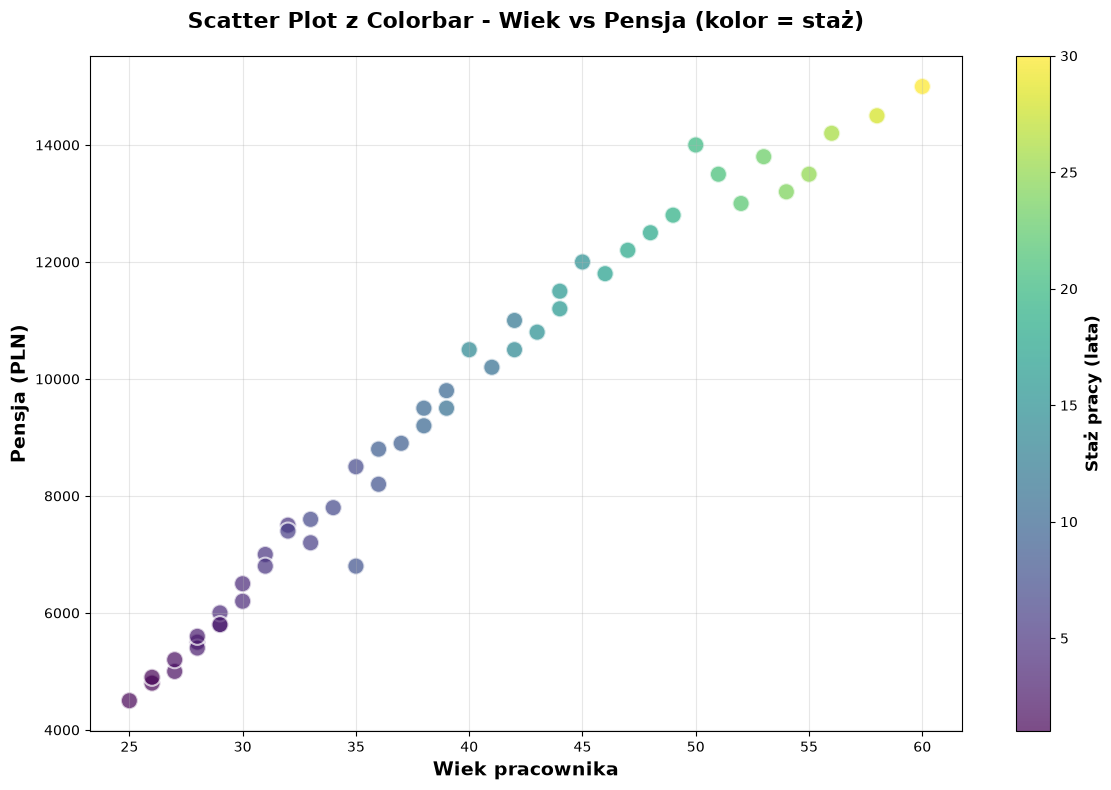

📊 Co widzimy?
   - Ciemniejsze punkty (fioletowe) = krótszy staż pracy
   - Jaśniejsze punkty (żółte) = dłuższy staż
   - Colorbar po prawej stronie pokazuje dokładną skalę wartości


In [19]:
# Przygotuj dane
x = df_prac['wiek']
y = df_prac['pensja']
kolory = df_prac['staz']  # KLUCZOWE: wartości dla kolorów (staż pracy)

# Wykres
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot z kolorami wg stażu
scatter = ax.scatter(
    x, y, 
    c=kolory,           # c= określa kolor na podstawie wartości stażu
    cmap='viridis',     # Paleta kolorów (żółty-zielony-niebieski-fioletowy)
    s=150,              # Rozmiar punktów
    alpha=0.7,          # Przezroczystość
    edgecolor='white',  # Biała ramka wokół punktów
    linewidth=1.5
)

# DODAJ COLORBAR - legenda kolorów!
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Staż pracy (lata)', fontsize=12, fontweight='bold')

# Stylizacja
ax.set_xlabel('Wiek pracownika', fontsize=14, fontweight='bold')
ax.set_ylabel('Pensja (PLN)', fontsize=14, fontweight='bold')
ax.set_title('Scatter Plot z Colorbar - Wiek vs Pensja (kolor = staż)', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("📊 Co widzimy?")
print("   - Ciemniejsze punkty (fioletowe) = krótszy staż pracy")
print("   - Jaśniejsze punkty (żółte) = dłuższy staż")
print("   - Colorbar po prawej stronie pokazuje dokładną skalę wartości")

### Przykład 2: Różne palety kolorów (cmap) - wybór koloru ma znaczenie!

Parametr `cmap=` określa **paletę kolorów**. Wybór palety powinien pasować do typu danych:

**Palety sekwencyjne** (od jasnego do ciemnego) - dla wartości od minimum do maximum:
- `'viridis'` - uniwersalna, czytelna nawet dla daltonistów ✅ POLECANA
- `'plasma'` - fioletowo-różowa
- `'Blues'`, `'Greens'`, `'Reds'` - jednokolorowe

**Palety dywergencyjne** (dwa kolory od środka) - gdy środek ma specjalne znaczenie (np. zero):
- `'coolwarm'` - niebieski (zimny) do czerwonego (ciepły)
- `'RdYlGn'` - czerwony-żółty-zielony (dobry dla wartości ujemne/neutralne/dodatnie)

**Palety kategoryczne** (dyskretne kolory) - dla kategorii:
- `'tab10'`, `'Set1'`, `'Paired'` - ale wtedy lepiej użyć legendy, nie colorbar!

W matplotlib dostępnych jest znacznie więcej map kolorów. Kilka przykładów:

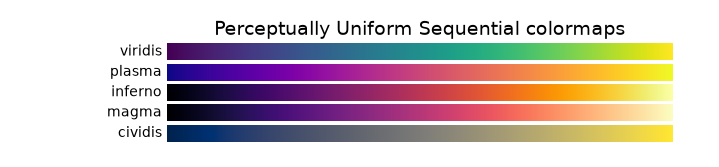

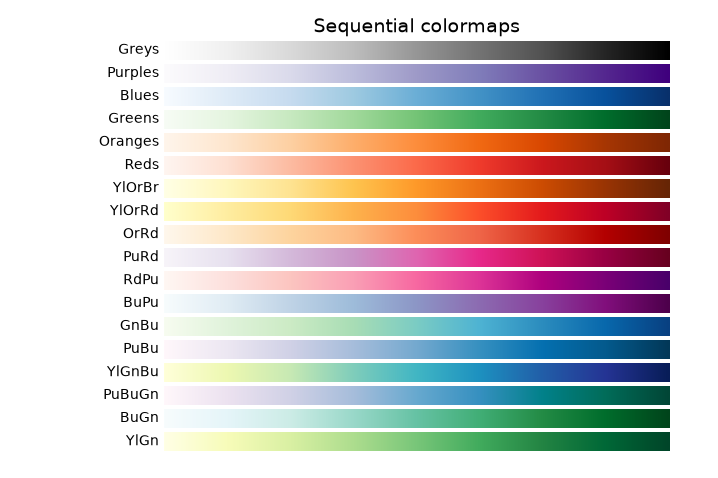

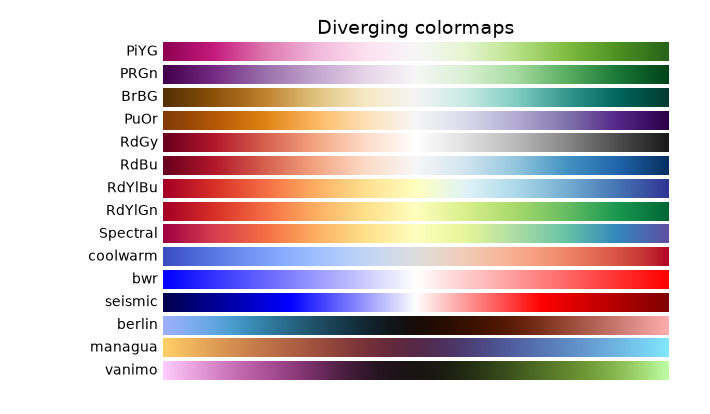

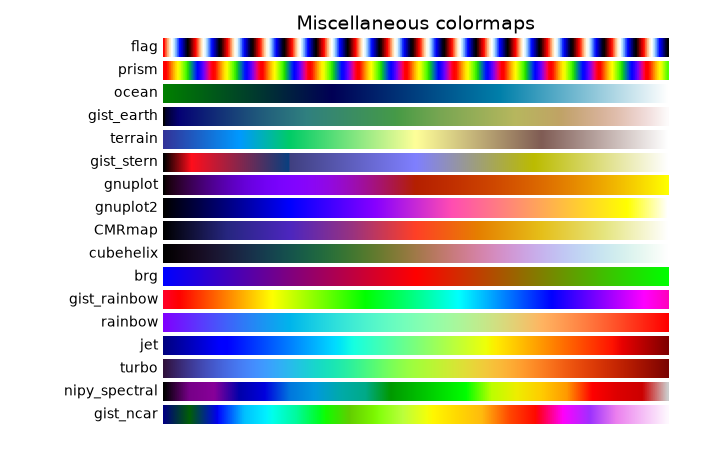

Więcej szczegółów znajdziesz na https://matplotlib.org/stable/users/explain/colors/colormaps.html

Zobaczmy porównanie:

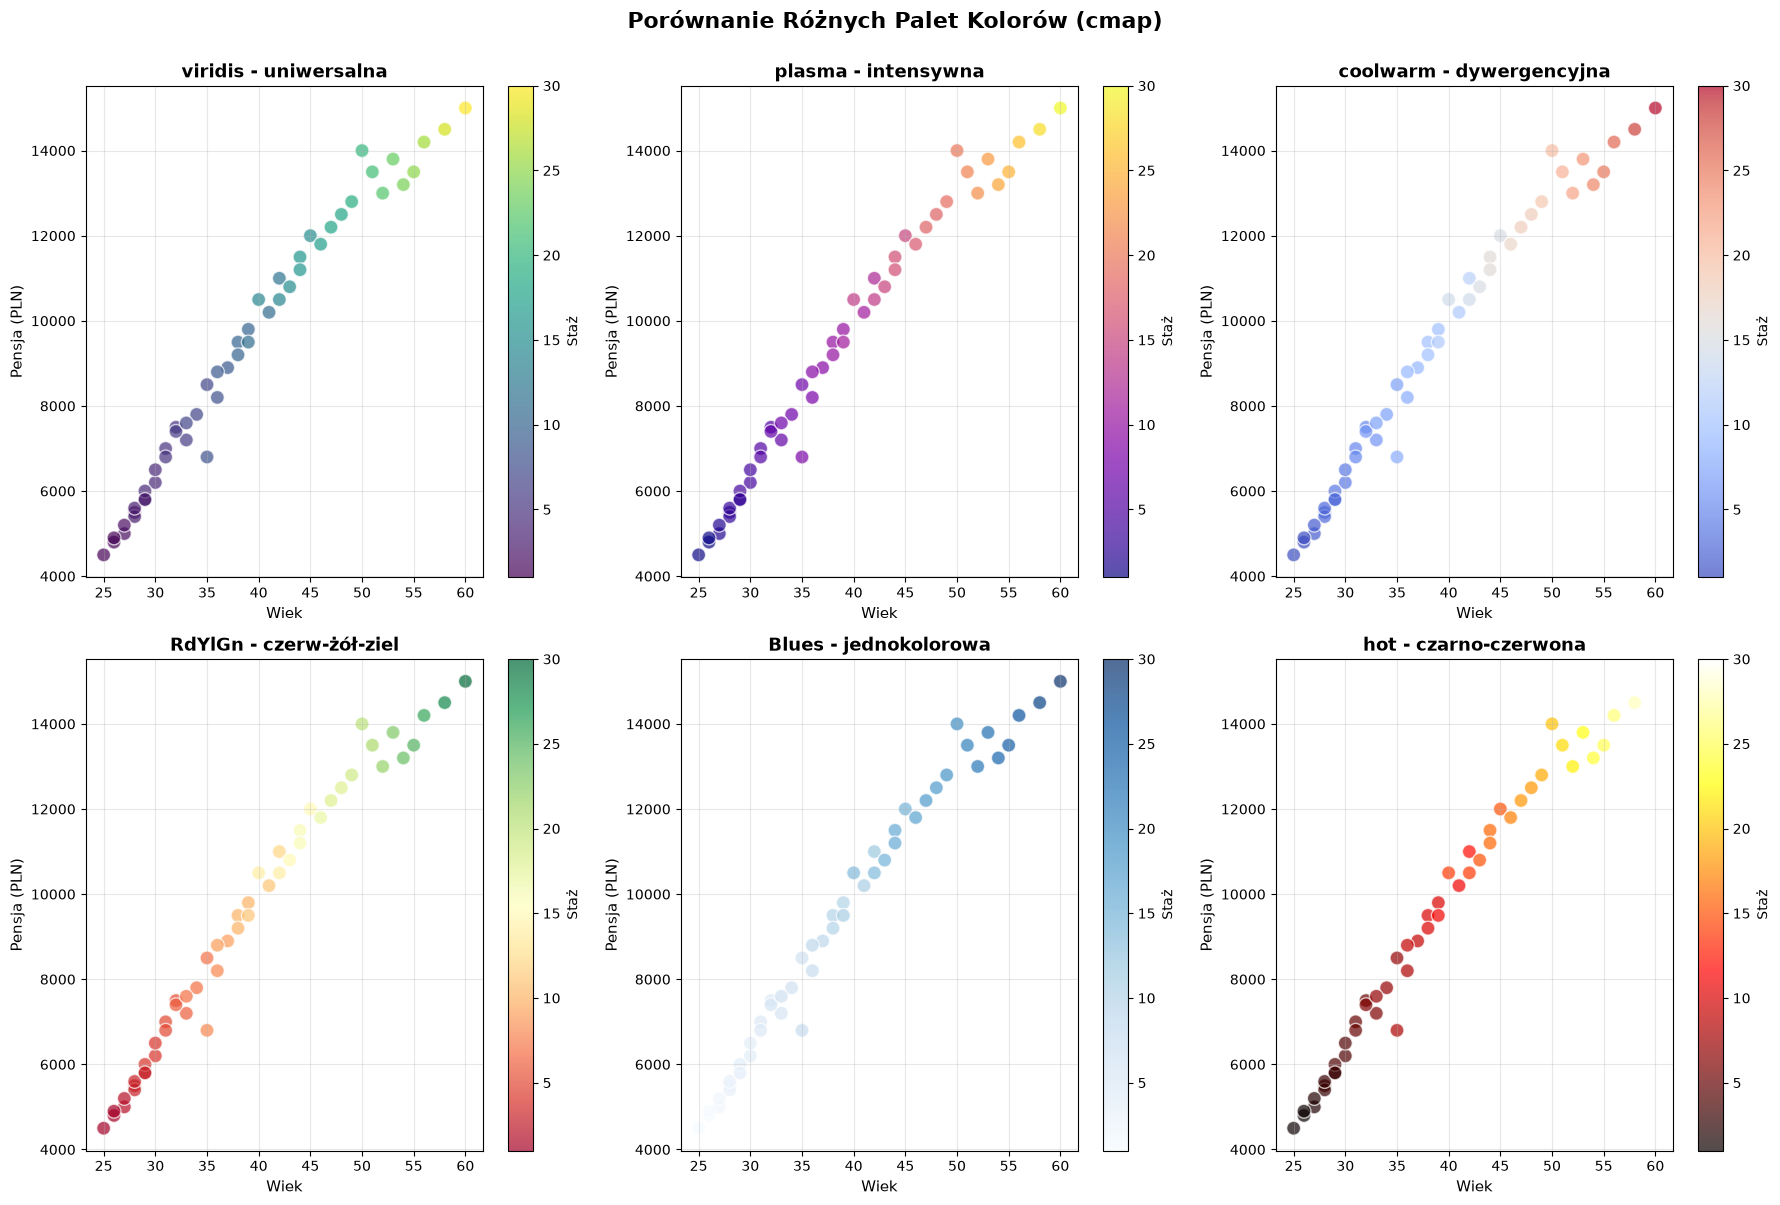

💡 KtóraĆwiczenie 2.2 (do domu) - Scatter plot z kolorowaniem paleta najlepsza?
   - 'viridis' - uniwersalny wybór, czytelna, przyjazna dla daltonistów
   - 'coolwarm' lub 'RdYlGn' - gdy wartości mają 'neutralny środek' (np. zero)
   - Unikaj 'jet' i 'rainbow' - trudne do odczytu!

🎨 Pełna lista palet: https://matplotlib.org/stable/tutorials/colors/colormaps.html


In [21]:
# Porównanie różnych palet kolorów
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

cmaps = ['viridis', 'plasma', 'coolwarm', 'RdYlGn', 'Blues', 'hot']
titles = [
    'viridis - uniwersalna', 
    'plasma - intensywna',
    'coolwarm - dywergencyjna',
    'RdYlGn - czerw-żół-ziel',
    'Blues - jednokolorowa',
    'hot - czarno-czerwona'
]

x = df_prac['wiek']
y = df_prac['pensja']
kolory = df_prac['staz']

for i, (cmap_name, title) in enumerate(zip(cmaps, titles)):
    ax = axes[i]
    
    scatter = ax.scatter(x, y, c=kolory, cmap=cmap_name, 
                        s=100, alpha=0.7, edgecolor='white', linewidth=1)
    
    # Colorbar dla każdego subplot
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Staż', fontsize=10)
    
    # Stylizacja
    ax.set_xlabel('Wiek', fontsize=11)
    ax.set_ylabel('Pensja (PLN)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Porównanie Różnych Palet Kolorów (cmap)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("💡 KtóraĆwiczenie 2.2 (do domu) - Scatter plot z kolorowaniem paleta najlepsza?")
print("   - 'viridis' - uniwersalny wybór, czytelna, przyjazna dla daltonistów")
print("   - 'coolwarm' lub 'RdYlGn' - gdy wartości mają 'neutralny środek' (np. zero)")
print("   - Unikaj 'jet' i 'rainbow' - trudne do odczytu!")
print("\n🎨 Pełna lista palet: https://matplotlib.org/stable/tutorials/colors/colormaps.html")

### Przykład 3: Dostosowanie colorbar - formatowanie i pozycjonowanie

Colorbar można dostosować na wiele sposobów:
- **Orientacja:** pozioma (`orientation='horizontal'`) lub pionowa (domyślna)
- **Etykiety:** własne ticks i labels
- **Format:** formatowanie liczb (np. `%.0f` dla całkowitych)
- **Pozycja i rozmiar:** `shrink=`, `pad=`, `aspect=`

Zobaczmy przykład z customizacją:

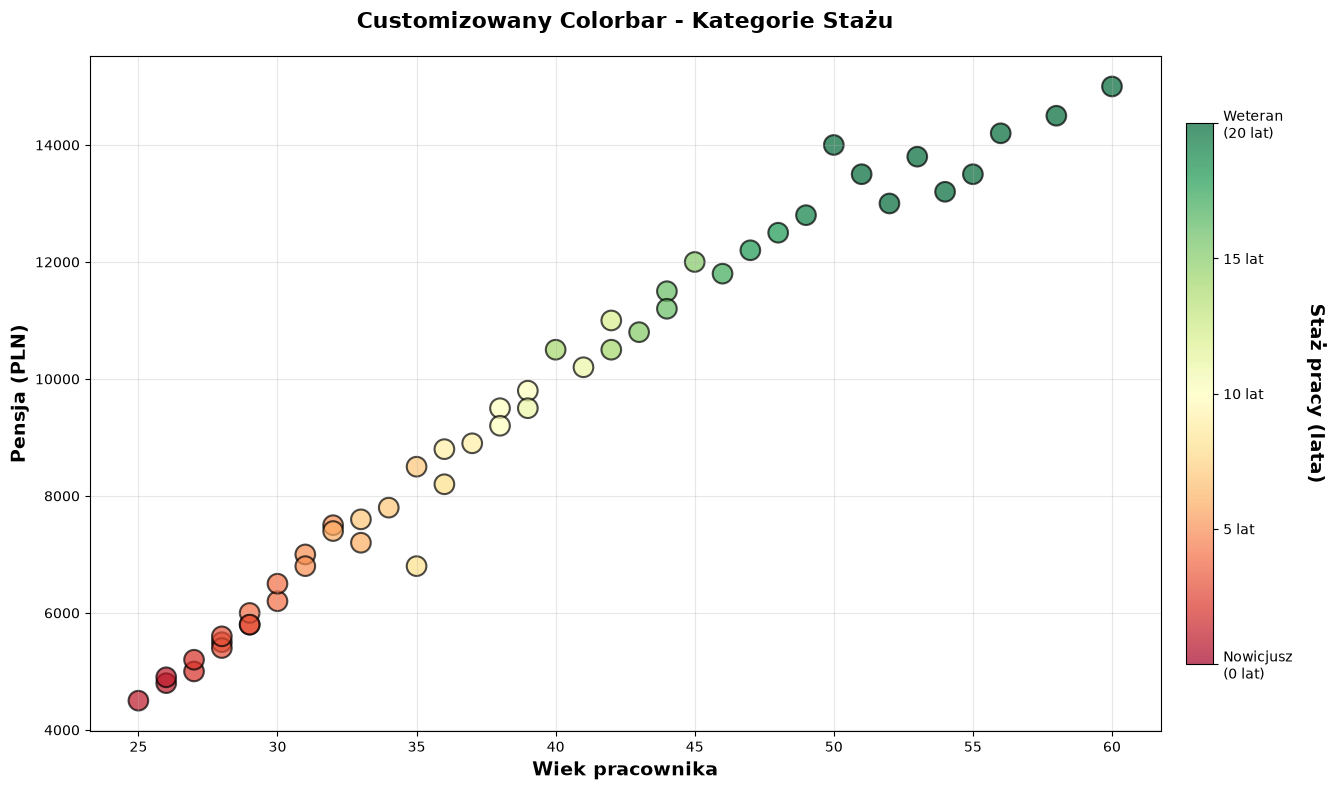

🎨 Customizacje zastosowane:
   - vmin=0, vmax=20: Ustalona skala (zamiast automatycznej)
   - shrink=0.8: Colorbar zajmuje 80% wysokości wykresu
   - Custom ticks: Własne etykiety zamiast liczb
   - rotation=270, labelpad=25: Pionowy label z odstępem


In [23]:
# Scatter plot z zaawansowaną customizacją colorbar
fig, ax = plt.subplots(figsize=(14, 8))

x = df_prac['wiek']
y = df_prac['pensja']
kolory = df_prac['staz']

# Scatter plot
scatter = ax.scatter(
    x, y, 
    c=kolory, 
    cmap='RdYlGn',      # Paleta czerwony-żółty-zielony
    s=200,
    alpha=0.7,
    edgecolor='black',
    linewidth=1.5,
    vmin=0,             # Minimalna wartość dla kolorów (zamiast auto)
    vmax=20             # Maksymalna wartość (rozszerza skalę)
)

# CUSTOMIZACJA COLORBAR
cbar = plt.colorbar(
    scatter, 
    ax=ax,
    orientation='vertical',  # 'horizontal' dla poziomego
    shrink=0.8,              # Skrócenie do 80% wysokości wykresu
    aspect=20,               # Proporcje (szerokość vs wysokość)
    pad=0.02                 # Odstęp od wykresu
)

# Formatowanie colorbar
cbar.set_label('Staż pracy (lata)', fontsize=14, fontweight='bold', rotation=270, labelpad=25)

# Custom ticks (własne podziałki)
cbar.set_ticks([0, 5, 10, 15, 20])  # Gdzie pokazać etykiety
cbar.set_ticklabels(['Nowicjusz\n(0 lat)', '5 lat', '10 lat', '15 lat', 'Weteran\n(20 lat)'])

# Stylizacja wykresu
ax.set_xlabel('Wiek pracownika', fontsize=14, fontweight='bold')
ax.set_ylabel('Pensja (PLN)', fontsize=14, fontweight='bold')
ax.set_title('Customizowany Colorbar - Kategorie Stażu', fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎨 Customizacje zastosowane:")
print("   - vmin=0, vmax=20: Ustalona skala (zamiast automatycznej)")
print("   - shrink=0.8: Colorbar zajmuje 80% wysokości wykresu")
print("   - Custom ticks: Własne etykiety zamiast liczb")
print("   - rotation=270, labelpad=25: Pionowy label z odstępem")

---

## Ćwiczenie 2.1.1 (w trakcie) - Scatter plot z colorbar dla temperatury

**Cel:** Stworzyć scatter plot z colorbar pokazujący dane pogodowe.

**Zadanie:**
1. Utwórz scatter plot dla danych pogodowych:
   - **Oś X:** Wilgotność (`df_pogoda['wilgotnosc']`)
   - **Oś Y:** Ciśnienie (`df_pogoda['cisnienie']`)
   - **Kolor:** Temperatura (`df_pogoda['temp']`)
2. Użyj palety kolorów `'coolwarm'` (niebieskie = zimno, czerwone = gorąco)
3. Dodaj colorbar z labelką "Temperatura (°C)"
4. Ustaw `vmin=0, vmax=30` dla czytelnej skali
5. Stylizuj wykres (tytuł, etykiety osi, grid)

**Podpowiedź:**
- `c=df_pogoda['temp']` dla kolorowania według temperatury
- `cmap='coolwarm'` dla niebiesko-czerwonej palety
- `cbar.set_label(...)` dla labela colorbar

In [ ]:
# TWÓJ KOD TUTAJ


<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Przygotuj dane
x = df_pogoda['wilgotnosc']
y = df_pogoda['cisnienie']
kolory = df_pogoda['temp']  # Temperatura dla kolorów

# Wykres
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot z kolorowaniem według temperatury
scatter = ax.scatter(
    x, y, 
    c=kolory,           # Kolor = temperatura
    cmap='coolwarm',    # Niebieskie (zimno) do czerwonego (gorąco)
    s=100,
    alpha=0.7,
    edgecolor='white',
    linewidth=1,
    vmin=0,             # Min temperatura dla skali kolorów
    vmax=30             # Max temperatura
)

# Dodaj colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Temperatura (°C)', fontsize=12, fontweight='bold')

# Stylizacja
ax.set_xlabel('Wilgotność (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Ciśnienie (hPa)', fontsize=14, fontweight='bold')
ax.set_title('Zależność Wilgotność vs Ciśnienie (kolor = temperatura)', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Analiza:")
print("   - Czerwone punkty = wysokie temperatury (ciepłe dni)")
print("   - Niebieskie punkty = niskie temperatury (zimne dni)")
print("   - Colorbar pokazuje dokładną skalę temperatur od 0°C do 30°C")
```

**Obserwacje:**
- Paleta `'coolwarm'` jest intuicyjna - niebieski = zimno, czerwony = gorąco
- `vmin=0, vmax=30` ustala stałą skalę (dobra praktyka dla porównań)
- Colorbar działa jak "legenda" dla trzeciej zmiennej (temperatura)

</details>

---
## Ćwiczenie 2.0.2 (do domu) - Scatter plot z kolorowaniem

**Cel:** Stworzyć zaawansowany scatter plot z kolorowaniem.

**Zadanie:**
1. Utwórz scatter plot: staż vs pensja
2. Pokoloruj punkty według działu (jak w przykładzie 2)
3. Dodaj legendę
4. Dodaj tytuł i opisy osi
5. Dla każdego działu oblicz korelację staż-pensja
6. Który dział ma najsilniejszą zależność staż-pensja?

**Czas:** 20 minut

In [17]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
fig, ax = plt.subplots(figsize=(12, 7))

dzialy = df_prac['dzial'].unique()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, dzial in enumerate(dzialy):
    dane_dzialu = df_prac[df_prac['dzial'] == dzial]
    ax.scatter(dane_dzialu['staz'], dane_dzialu['pensja'], 
               label=dzial, alpha=0.7, s=80, color=colors[i], edgecolor='black', linewidth=0.5)

ax.set_title('Staż vs Pensja według działów', fontsize=14, fontweight='bold')
ax.set_xlabel('Staż [lata]', fontsize=12)
ax.set_ylabel('Pensja [zł]', fontsize=12)
ax.legend(title='Dział')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analiza korelacji dla każdego działu
print("\nKorelacja staż-pensja według działów:")
print("="*40)
for dzial in dzialy:
    dane_dzialu = df_prac[df_prac['dzial'] == dzial]
    corr = dane_dzialu['staz'].corr(dane_dzialu['pensja'])
    print(f"{dzial:15s}: {corr:.3f}")

# Znajdź dział z najsilniejszą korelacją
korelacje = {}
for dzial in dzialy:
    dane_dzialu = df_prac[df_prac['dzial'] == dzial]
    korelacje[dzial] = dane_dzialu['staz'].corr(dane_dzialu['pensja'])

najsilniejszy = max(korelacje, key=lambda k: abs(korelacje[k]))
print(f"\nNajsilniejsza korelacja: {najsilniejszy} ({korelacje[najsilniejszy]:.3f})")
```

</details>

**Kluczowe spostrzeżenia z Colorbar:**

✅ **Colorbar świetnie pokazuje:**
- Trzecią zmienną na scatter plot (obok X i Y)
- Skalę wartości ciągłych (temperatura, pensja, czas, itp.)
- Gradację kolorów w heatmap, contour plot, itd.
- Intuicyjną wizualizację wielkości

📊 **Kluczowe parametry:**
```python
# W scatter()
scatter = ax.scatter(
    x, y, 
    c=wartosci,        # Wartości dla kolorów (array)
    cmap='viridis',    # Paleta kolorów
    vmin=0,            # Min wartość dla skali (opcjonalne)
    vmax=100           # Max wartość dla skali (opcjonalne)
)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Nazwa zmiennej', fontsize=12)

# Customizacja (opcjonalnie)
cbar.set_ticks([0, 25, 50, 75, 100])  # Custom podziałki
cbar.set_ticklabels(['Niskie', 'Średnie-', 'Średnie', 'Średnie+', 'Wysokie'])
```

🎨 **Popularne palety kolorów:**
- **Sekwencyjne:** `'viridis'` ✅, `'plasma'`, `'Blues'`, `'Greens'`
- **Dywergencyjne:** `'coolwarm'`, `'RdYlGn'`, `'RdBu'`
- **Unikaj:** `'jet'`, `'rainbow'` (trudne do odczytu, nieczytelne dla daltonistów)

⚠️ **Kiedy NIE używać colorbar:**
- Masz kategorie (użyj `plt.legend()` zamiast colorbar)
- Tylko 2-3 dyskretne kolory (legenda jest lepsza)
- Kolor nie niesie informacji (jest tylko ozdobą)

💡 **Best practices:**
- Używaj `cmap='viridis'` jako domyślnej (uniwersalna, czytelna)
- Dla temperatury: `'coolwarm'` (intuicyjna: niebieski=zimno, czerwony=gorąco)
- Dla wartości dodatnie/ujemne: `'RdYlGn'` lub `'RdBu'` (dywergencyjne)
- Zawsze dodaj `label` do colorbar (opisz co oznaczają kolory!)
- Rozważ `vmin=` i `vmax=` dla stabilnej skali (ważne przy porównaniach)

---

---

## 2.2. Linie trendu - Trend lines (dopasowanie krzywej)

### Historia z działu HR - czy pensja rośnie z wiekiem?

Szefowa HR przychodzi do Ciebie z pytaniem:

> "Mamy dane o wieku i pensjach pracowników. **Chciałabym zobaczyć ogólny trend** - czy pensja rośnie wraz z wiekiem? Nie chcę tylko punktów na wykresie, bo to trochę chaotyczne. **Pokaż mi linię, która pokazuje ogólną zależność!**"

Scatter plot pokazuje wszystkie punkty, ale czasami **trudno wyłapać ogólny kierunek**. Właśnie do tego służą **linie trendu** (trend lines)!

---

### Kiedy używać linii trendu?

✅ **Użyj trend line gdy:**
- Masz scatter plot z dużą liczbą punktów
- Chcesz pokazać **ogólny kierunek zależności** między zmiennymi
- Chcesz **przewidzieć** wartość Y dla nowego X (prosta regresja)
- Dane mają jakiś wzorzec, ale z dużym rozrzutem

❌ **Nie używaj gdy:**
- Dane są zbyt chaotyczne (brak żadnego wzorca)
- Zależność jest nieliniowa, a używasz linii prostej (użyj wtedy krzywej wielomianowej)

---

### Jak dodać linię trendu?

**Krok 1:** Dopasuj linię do danych używając `np.polyfit()`
```python
z = np.polyfit(x, y, degree)  # degree=1 to linia prosta, degree=2 to parabola
```

**Krok 2:** Stwórz funkcję do predykcji używając `np.poly1d()`
```python
p = np.poly1d(z)  # p(x) zwróci przewidywaną wartość Y
```

**Krok 3:** Narysuj linię trendu
```python
plt.plot(x, p(x), '--', label='Trend')
```

---

### Przykład 1: Podstawowa linia trendu - wiek vs pensja (linia prosta)

Zacznijmy od najczęstszego przypadku - **linia prosta** (regresja liniowa).

Pokażemy scatter plot wieku i pensji pracowników, a następnie dodamy **linię trendu**, która pokaże ogólną zależność.

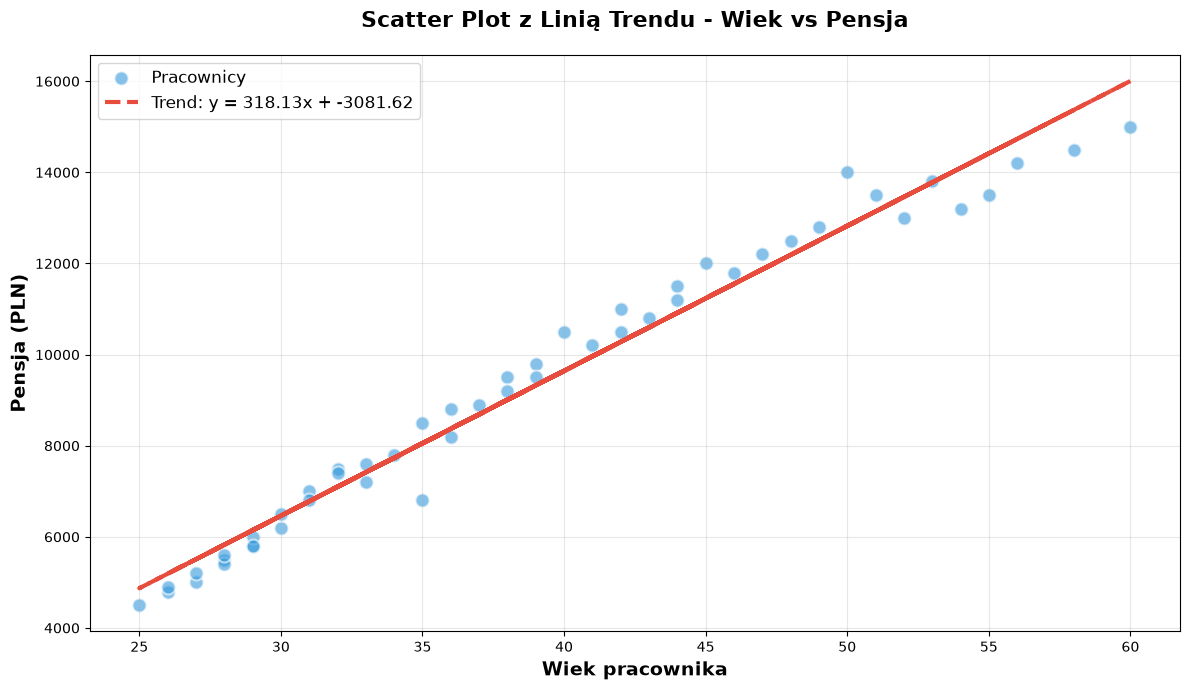

📊 Równanie linii trendu: y = 318.13x + -3081.62
   Czyli: pensja = 318.13 × wiek + -3081.62

💡 Interpretacja:
   - Każdy dodatkowy rok wieku zwiększa pensję średnio o 318.13 PLN
   - Teoretyczna pensja dla osoby w wieku 0 lat byłaby -3081.62 PLN (to tylko punkt przecięcia, nie ma sensu biznesowego)


In [24]:
import numpy as np

# Przygotuj dane
x = df_prac['wiek'].values
y = df_prac['pensja'].values

# Krok 1: Dopasuj linię prostą (degree=1)
z = np.polyfit(x, y, 1)  # 1 = linia prosta (y = ax + b)
p = np.poly1d(z)         # p(x) to funkcja która liczy y dla danego x

# Wyciągnij współczynniki
a = z[0]  # nachylenie (slope)
b = z[1]  # przecięcie z osią Y (intercept)

# Narysuj wykres
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter plot - oryginalne dane
ax.scatter(x, y, alpha=0.6, s=100, color='#3498db', edgecolor='white', linewidth=1.5, label='Pracownicy')

# Linia trendu
ax.plot(x, p(x), color='#e74c3c', linestyle='--', linewidth=3, label=f'Trend: y = {a:.2f}x + {b:.2f}')

# Stylizacja
ax.set_xlabel('Wiek pracownika', fontsize=14, fontweight='bold')
ax.set_ylabel('Pensja (PLN)', fontsize=14, fontweight='bold')
ax.set_title('Scatter Plot z Linią Trendu - Wiek vs Pensja', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Wypisz równanie
print(f"📊 Równanie linii trendu: y = {a:.2f}x + {b:.2f}")
print(f"   Czyli: pensja = {a:.2f} × wiek + {b:.2f}")
print(f"\n💡 Interpretacja:")
print(f"   - Każdy dodatkowy rok wieku zwiększa pensję średnio o {a:.2f} PLN")
print(f"   - Teoretyczna pensja dla osoby w wieku 0 lat byłaby {b:.2f} PLN (to tylko punkt przecięcia, nie ma sensu biznesowego)")

### Co to jest `np.polyfit` i `np.poly1d`?

---

**`np.polyfit(x, y, degree)` - dopasowanie wielomianu**

Znajduje **najlepiej dopasowany wielomian** do twoich danych metodą najmniejszych kwadratów (minimalizuje sumę kwadratów błędów).

**Co zwraca?** Tablicę współczynników wielomianu **od najwyższego stopnia do najniższego**.

**Przykłady:**

```python
# degree=1 (linia prosta: y = ax + b)
z = np.polyfit(x, y, 1)
# Zwraca: [a, b]
# z[0] = a (nachylenie)
# z[1] = b (wyraz wolny)

# degree=2 (parabola: y = ax² + bx + c)
z = np.polyfit(x, y, 2)
# Zwraca: [a, b, c]
# z[0] = a (współczynnik przy x²)
# z[1] = b (współczynnik przy x)
# z[2] = c (wyraz wolny)

# degree=3 (sześcian: y = ax³ + bx² + cx + d)
z = np.polyfit(x, y, 3)
# Zwraca: [a, b, c, d]
```

**Jak to działa?** Minimalizuje **sumę kwadratów różnic** między rzeczywistymi wartościami y a przewidywanymi:
```
Loss = Σ(y_rzeczywiste - y_przewidywane)²
```
To klasyczna **regresja najmniejszych kwadratów** (Ordinary Least Squares, OLS).

---

**`np.poly1d(współczynniki)` - tworzy funkcję z współczynników**

Bierze współczynniki wielomianu i tworzy **funkcję**, którą możesz wywołać.

**Przykład:**
```python
z = np.polyfit(x, y, 2)        # Dopasuj parabolę, dostaniesz [a, b, c]
p = np.poly1d(z)                # Stwórz funkcję p(x) = ax² + bx + c

# Teraz możesz wywołać funkcję:
y_przewidywane = p(35)          # Oblicz wartość dla x=35
y_krzywa = p(x_range)           # Oblicz wartości dla wielu x-ów (do rysowania)
```

**Dlaczego dwa kroki?**
- `polyfit` → znajdź współczynniki (a, b, c...)
- `poly1d` → stwórz funkcję, którą możesz wielokrotnie wywoływać

---

**Razem w praktyce:**

```python
# Dane: wiek pracowników (x) i pensje (y)
x = np.array([25, 30, 35, 40, 45])
y = np.array([3000, 4000, 5500, 6000, 7500])

# Krok 1: Dopasuj linię prostą (degree=1)
z = np.polyfit(x, y, 1)
# z = [120, -600]  ← y = 120x - 600

# Krok 2: Stwórz funkcję
p = np.poly1d(z)

# Krok 3: Użyj funkcji do predykcji
p(30)    # = 120*30 - 600 = 3000  ← pensja dla 30 lat
p(50)    # = 120*50 - 600 = 5400  ← przewidywana pensja dla 50 lat

# Krok 4: Narysuj linię trendu
x_linia = np.linspace(25, 50, 100)  # 100 punktów do gładkiej krzywej
y_linia = p(x_linia)                 # Oblicz y dla każdego x
plt.plot(x_linia, y_linia, '--')     # Narysuj
```

---

### Przykład 2: Krzywa wielomianowa (polynomial trend) - lepsze dopasowanie

Czasami **linia prosta nie wystarcza** - dane mają bardziej skomplikowany wzorzec (np. krzywa, parabola).

W takim przypadku możemy użyć **wielomianu wyższego stopnia**:
- `degree=1` → linia prosta
- `degree=2` → parabola (krzywa)
- `degree=3` → krzywa kubiczna

⚠️ **Uwaga:** Zbyt wysoki stopień (degree > 3) może prowadzić do **overfittingu** (linia zbyt idealnie dopasowana do danych, ale nieużyteczna do predykcji).

Porównajmy różne stopnie wielomianu:

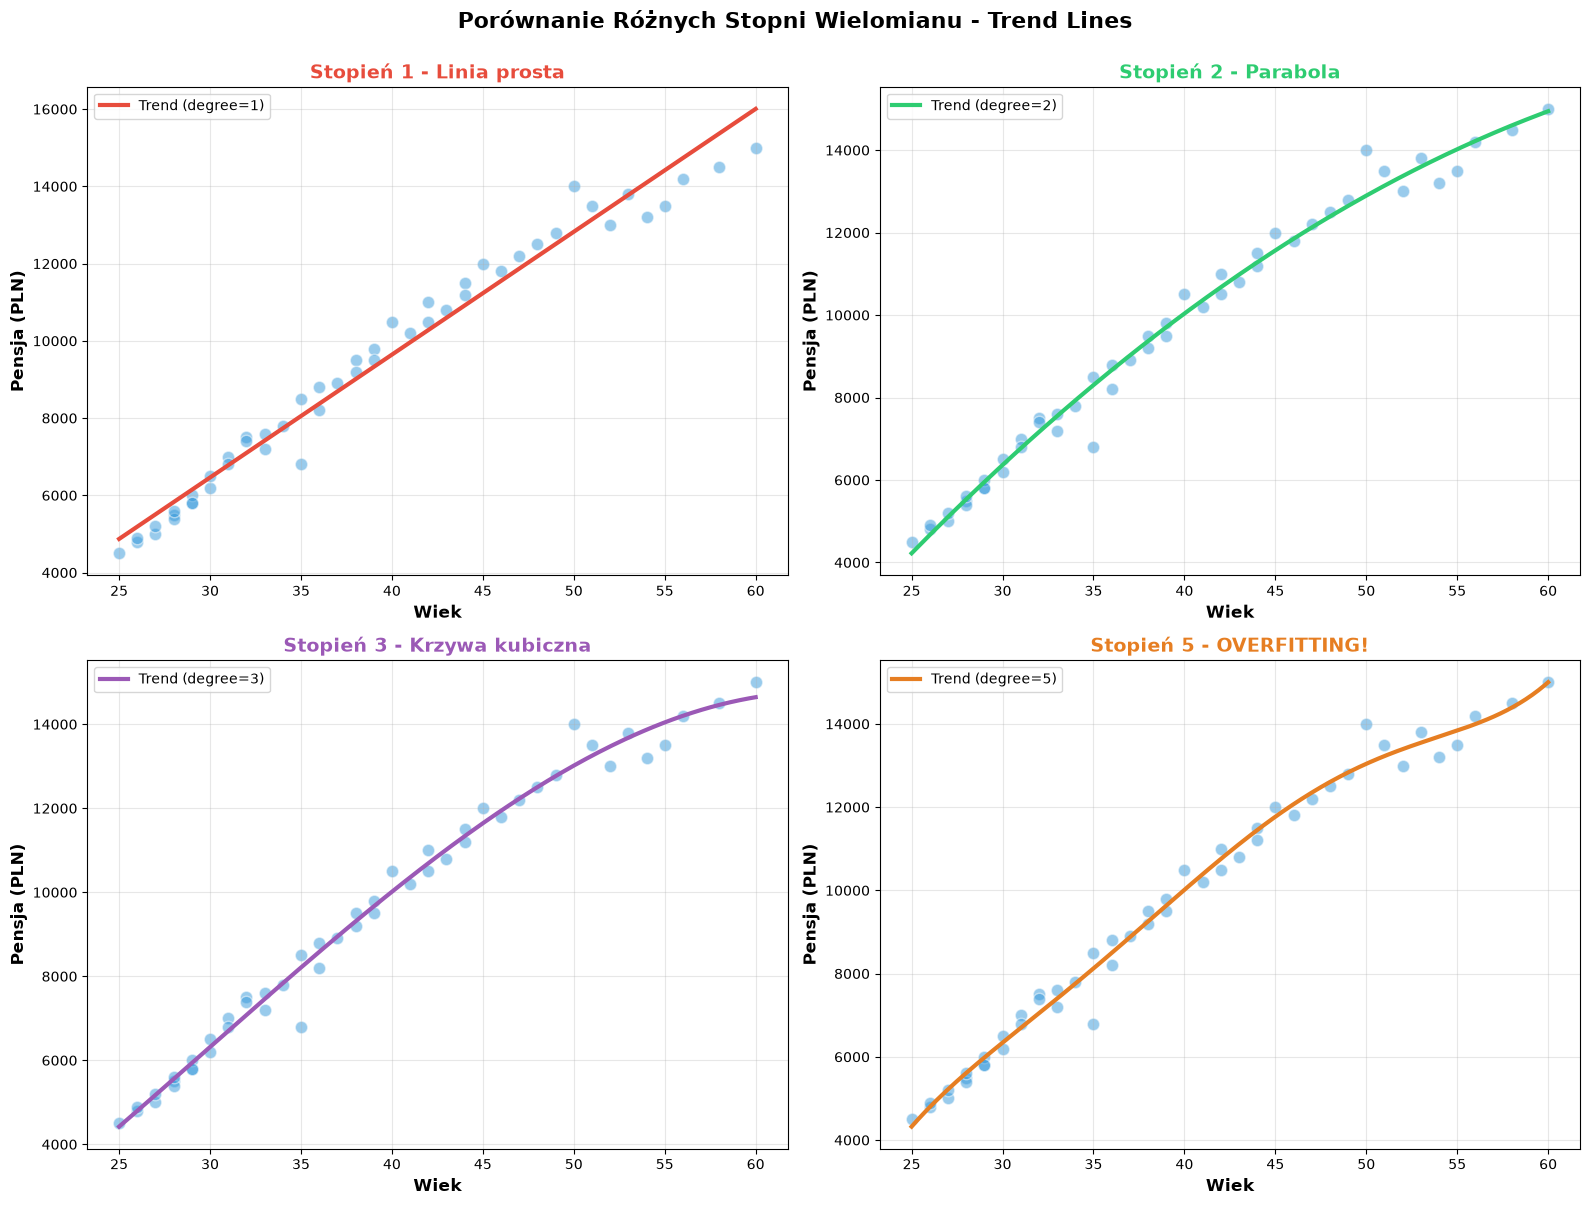

🔍 Analiza:
   - Stopień 1 (linia prosta): Prosty, ale może nie wyłapać wszystkich zależności
   - Stopień 2 (parabola): Często najlepszy kompromis - wyłapuje krzywizny
   - Stopień 3: Czasami potrzebny dla bardziej złożonych danych
   - Stopień 5: OVERFITTING - krzywa 'tańczy' wokół punktów, ale nie pokazuje trendu!

💡 Zasada: Używaj NAJMNIEJSZEGO stopnia, który rozsądnie pasuje do danych (zazwyczaj 1-2)


In [25]:
# Porównanie różnych stopni wielomianu
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

degrees = [1, 2, 3, 5]  # Linia prosta, parabola, kubiczna, stopień 5
titles = ['Stopień 1 - Linia prosta', 'Stopień 2 - Parabola', 'Stopień 3 - Krzywa kubiczna', 'Stopień 5 - OVERFITTING!']
colors = ['#e74c3c', '#2ecc71', '#9b59b6', '#e67e22']

x = df_prac['wiek'].values
y = df_prac['pensja'].values

# Stwórz gładką linię dla lepszego wyświetlenia krzywej
x_smooth = np.linspace(x.min(), x.max(), 200)

for i, (degree, title, color) in enumerate(zip(degrees, titles, colors)):
    ax = axes[i]
    
    # Dopasuj wielomian
    z = np.polyfit(x, y, degree)
    p = np.poly1d(z)
    
    # Scatter plot
    ax.scatter(x, y, alpha=0.5, s=80, color='#3498db', edgecolor='white', linewidth=1)
    
    # Linia trendu (gładka krzywa)
    ax.plot(x_smooth, p(x_smooth), color=color, linewidth=3, label=f'Trend (degree={degree})')
    
    # Stylizacja
    ax.set_xlabel('Wiek', fontsize=12, fontweight='bold')
    ax.set_ylabel('Pensja (PLN)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', color=color)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Porównanie Różnych Stopni Wielomianu - Trend Lines', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("🔍 Analiza:")
print("   - Stopień 1 (linia prosta): Prosty, ale może nie wyłapać wszystkich zależności")
print("   - Stopień 2 (parabola): Często najlepszy kompromis - wyłapuje krzywizny")
print("   - Stopień 3: Czasami potrzebny dla bardziej złożonych danych")
print("   - Stopień 5: OVERFITTING - krzywa 'tańczy' wokół punktów, ale nie pokazuje trendu!")
print("\n💡 Zasada: Używaj NAJMNIEJSZEGO stopnia, który rozsądnie pasuje do danych (zazwyczaj 1-2)")

**⚖️ Bias-Variance Tradeoff (kompromis błąd-wariancja)**

To fundamentalny problem w machine learning: **jak skomplikowany powinien być model?**

---

**UNDERFITTING (niedouczenie) - model zbyt prosty:**
- **Wysoki BIAS** (błąd systematyczny) - model nie wychwytuje prawdziwych wzorców
- Słabe dopasowanie do danych treningowych
- Słabe wyniki też na nowych danych

**Przykład:** Linia prosta (degree=1) dla danych, które wyraźnie są krzywą.
```
Dane:      ●    ●●●●    ●     ← wyraźna krzywa
Model:     _______________    ← prosta linia (za prosta!)
Wynik:     Nie wychwytuje krzywizny, słabe dopasowanie
```

---

**GOOD FIT (złoty środek) - odpowiednia złożoność:**
- **Balans** między bias a variance
- Wychwytuje prawdziwe wzorce, ignoruje szum
- Dobre dopasowanie + dobre uogólnienie na nowe dane

**Przykład:** Parabola (degree=2) dla danych krzywoliniowych.
```
Dane:      ●    ●●●●    ●     ← wyraźna krzywa
Model:        ╱────╲          ← parabola (idealnie!)
Wynik:     Wychwytuje trend, nie "pamięta" szumu
```

---

**OVERFITTING (przeuczenie) - model zbyt skomplikowany:**
- **Wysoka VARIANCE** (wariancja) - model "pamięta" szum w danych
- Bardzo dobre dopasowanie do treningu (czasem 100%!)
- **Słabe uogólnienie** na nowe dane - model nie wychwycił trendu, tylko "zapamiętał" punkty

**Przykład:** Wielomian stopnia 10 dla kilkunastu punktów.
```
Dane:      ●    ●●●●    ●     ← wyraźna krzywa + szum
Model:     ╱╲╱╲╱──╲╱╲╱╲      ← meandruje przez punkty
Wynik:     Przechodzi przez każdy punkt, ale nie uogólnia
```

---

**Wizualizacja:**

```
        UNDERFITTING              GOOD FIT             OVERFITTING
             (bias ↑)           (balans ✓)            (variance ↑)
    
Trening:      ★★☆☆☆             ★★★★☆                ★★★★★
Nowe dane:    ★★☆☆☆             ★★★★★                ★☆☆☆☆  ← Źle!
                                    
degree:          1                   2-3                  10+
```

---

**Praktyczna wskazówka dla linii trendu:**
- Zacznij od `degree=1` (prosta)
- Jeśli widać wyraźną krzywiznę → spróbuj `degree=2` (parabola)
- Rzadko używaj `degree > 3` → duże ryzyko overfittingu
- **Zawsze sprawdź wizualnie** - czy linia wygląda sensownie?

---

### Przykład 3: Predykcja - przewidywanie wartości

Jedną z najciekawszych funkcji linii trendu jest **predykcja** - możemy przewidzieć wartość Y dla nowego X, którego nie ma w naszych danych!

**Scenariusz:**
> "Jaką pensję powinniśmy zaoferować nowemu pracownikowi w wieku 35 lat, jeśli chcemy być spójni z naszym obecnym systemem wynagrodzeń?"

Użyjmy funkcji `p(x)` do predykcji:

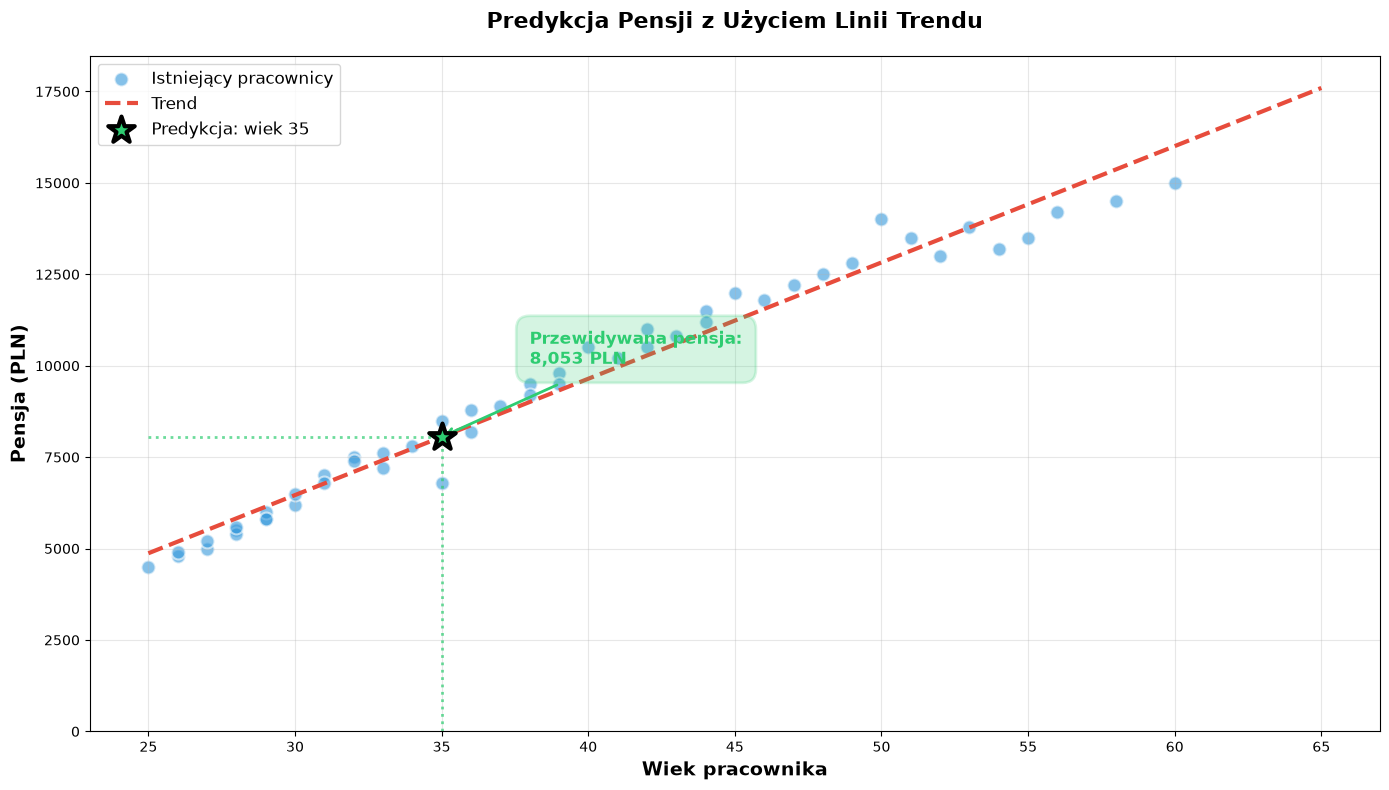

📊 Równanie trendu: y = 318.13x + -3081.62

🎯 PREDYKCJA:
   Dla pracownika w wieku 35 lat:
   Przewidywana pensja = 318.13 × 35 + -3081.62
   Przewidywana pensja = 8,052.76 PLN

💡 To tylko SZACUNEK bazujący na obecnych danych!
   Rzeczywista pensja może być inna (zależy od stanowiska, doświadczenia, itp.)


In [29]:
# Dopasuj linię trendu
x = df_prac['wiek'].values
y = df_prac['pensja'].values

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# PREDYKCJA: Jaka pensja dla osoby w wieku 35 lat?
nowy_wiek = 35
przewidywana_pensja = p(nowy_wiek)

# Narysuj wykres z predykcją
fig, ax = plt.subplots(figsize=(14, 8))

# Scatter plot - istniejący pracownicy
ax.scatter(x, y, alpha=0.6, s=100, color='#3498db', edgecolor='white', linewidth=1.5, label='Istniejący pracownicy')

# Linia trendu
x_smooth = np.linspace(x.min(), x.max() + 5, 100)
ax.plot(x_smooth, p(x_smooth), color='#e74c3c', linestyle='--', linewidth=3, label=f'Trend')

# Punkt predykcji - NOWY pracownik
ax.scatter([nowy_wiek], [przewidywana_pensja], 
           s=400, color='#2ecc71', edgecolor='black', linewidth=3, 
           marker='*', zorder=5, label=f'Predykcja: wiek {nowy_wiek}')

# Linie pomocnicze (grid lines do punktu)
ax.plot([nowy_wiek, nowy_wiek], [0, przewidywana_pensja], 
        color='#2ecc71', linestyle=':', linewidth=2, alpha=0.7)
ax.plot([x.min(), nowy_wiek], [przewidywana_pensja, przewidywana_pensja], 
        color='#2ecc71', linestyle=':', linewidth=2, alpha=0.7)

# Adnotacja z przewidywaną wartością
ax.annotate(f'Przewidywana pensja:\n{przewidywana_pensja:,.0f} PLN', 
            xy=(nowy_wiek, przewidywana_pensja), 
            xytext=(nowy_wiek + 3, przewidywana_pensja + 2000),
            fontsize=12, fontweight='bold', color='#2ecc71',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#2ecc71', alpha=0.2, edgecolor='#2ecc71', linewidth=2),
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2))

# Stylizacja
ax.set_xlabel('Wiek pracownika', fontsize=14, fontweight='bold')
ax.set_ylabel('Pensja (PLN)', fontsize=14, fontweight='bold')
ax.set_title('Predykcja Pensji z Użyciem Linii Trendu', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# Wyniki predykcji
a = z[0]
b = z[1]
print(f"📊 Równanie trendu: y = {a:.2f}x + {b:.2f}")
print(f"\n🎯 PREDYKCJA:")
print(f"   Dla pracownika w wieku {nowy_wiek} lat:")
print(f"   Przewidywana pensja = {a:.2f} × {nowy_wiek} + {b:.2f}")
print(f"   Przewidywana pensja = {przewidywana_pensja:,.2f} PLN")
print(f"\n💡 To tylko SZACUNEK bazujący na obecnych danych!")
print(f"   Rzeczywista pensja może być inna (zależy od stanowiska, doświadczenia, itp.)")

---

## Ćwiczenie 2.2.1 (w trakcie) - Scatter plot z linią trendu

**Cel:** Stworzyć scatter plot z linią trendu pokazującą zależność między stażem pracy a pensją.

**Zadanie:**
1. Stwórz scatter plot: staż pracy (oś X) vs pensja (oś Y)
2. Dodaj linię trendu (stopień 1 - linia prosta)
3. Wypisz równanie linii trendu
4. **DODATKOWE:** Przewidź pensję dla osoby ze stażem 15 lat i zaznacz ten punkt na wykresie
5. Zinterpretuj wyniki: o ile średnio wzrasta pensja za każdy rok stażu?

**Podpowiedź:**
- Użyj `df_prac['staz']` i `df_prac['pensja']`
- `np.polyfit(x, y, 1)` dla linii prostej
- `p(15)` zwróci przewidywaną pensję dla stażu 15 lat

In [ ]:
# TWÓJ KOD TUTAJ


<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Przygotuj dane
x = df_prac['staz'].values
y = df_prac['pensja'].values

# Dopasuj linię trendu (stopień 1 - linia prosta)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# Predykcja dla stażu 15 lat
staż_nowy = 15
pensja_przewidywana = p(staż_nowy)

# Współczynniki
a = z[0]  # nachylenie
b = z[1]  # przecięcie

# Wykres
fig, ax = plt.subplots(figsize=(14, 8))

# Scatter plot - istniejący pracownicy
ax.scatter(x, y, alpha=0.6, s=100, color='#3498db', edgecolor='white', linewidth=1.5, 
           label='Pracownicy')

# Linia trendu
x_smooth = np.linspace(x.min(), x.max() + 2, 100)
ax.plot(x_smooth, p(x_smooth), color='#e74c3c', linestyle='--', linewidth=3, 
        label=f'Trend: y = {a:.2f}x + {b:.2f}')

# Punkt predykcji
ax.scatter([staż_nowy], [pensja_przewidywana], 
           s=400, color='#2ecc71', edgecolor='black', linewidth=3, 
           marker='*', zorder=5, label=f'Predykcja: staż {staż_nowy} lat')

# Adnotacja
ax.annotate(f'{pensja_przewidywana:,.0f} PLN', 
            xy=(staż_nowy, pensja_przewidywana), 
            xytext=(staż_nowy + 1, pensja_przewidywana + 2500),
            fontsize=12, fontweight='bold', color='#2ecc71',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#2ecc71', alpha=0.2),
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2))

# Stylizacja
ax.set_xlabel('Staż pracy (lata)', fontsize=14, fontweight='bold')
ax.set_ylabel('Pensja (PLN)', fontsize=14, fontweight='bold')
ax.set_title('Scatter Plot z Linią Trendu - Staż vs Pensja', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# Interpretacja
print(f"📊 Równanie linii trendu: y = {a:.2f}x + {b:.2f}")
print(f"\n💡 Interpretacja:")
print(f"   - Każdy dodatkowy rok stażu zwiększa pensję średnio o {a:.2f} PLN")
print(f"\n🎯 Predykcja dla stażu {staż_nowy} lat:")
print(f"   - Przewidywana pensja: {pensja_przewidywana:,.2f} PLN")
```

**Analiza wyników:**
- **Współczynnik nachylenia (a):** Pokazuje, o ile wzrasta pensja za każdy rok stażu
- **Punkt przecięcia (b):** Teoretyczna pensja dla stażu = 0 (osoba bez doświadczenia)
- **Predykcja:** Możemy oszacować pensję dla dowolnego stażu (w rozsądnych granicach!)

⚠️ **Uwaga:** To tylko model statystyczny! Rzeczywista pensja zależy od wielu innych czynników (stanowisko, umiejętności, dział, itd.)

</details>

**Kluczowe spostrzeżenia z Trend Lines:**

✅ **Linie trendu świetnie pokazują:**
- Ogólny kierunek zależności między zmiennymi
- Umożliwiają prostą predykcję wartości
- Upraszczają wizualizację danych z dużym rozrzutem
- Pomagają wyłapać wzorce w "chaotycznych" danych

📊 **Kluczowe parametry:**
```python
# Dopasowanie
z = np.polyfit(x, y, degree)  # degree: 1=linia, 2=parabola, 3=kubiczna
p = np.poly1d(z)              # Funkcja do predykcji

# Współczynniki (dla degree=1)
a = z[0]  # nachylenie (slope) - o ile wzrasta Y na jednostkę X
b = z[1]  # przecięcie (intercept) - wartość Y gdy X=0

# Predykcja
y_nowe = p(x_nowe)  # Przewidywana wartość dla nowego X
```

⚠️ **Kiedy NIE używać:**
- Dane są zbyt chaotyczne (brak jakiegokolwiek wzorca)
- Chcesz pokazać szczegóły, nie ogólny trend
- Używasz zbyt wysokiego stopnia wielomianu → overfitting!

💡 **Best practice:**
- Zacznij od `degree=1` (linia prosta)
- Jeśli nie pasuje, spróbuj `degree=2` (parabola)
- Rzadko używaj `degree > 3` (ryzyko overfittingu)
- Zawsze sprawdź wizualnie, czy linia trendu ma sens biznesowy!

---

---
## 3. Wykresy z paskami błędów - Error bars (`errorbar`)

### Historia z laboratorium meteorologicznego - niepewność pomiarów

Wyobraź sobie, że jesteś naukowcem badającym zmiany klimatu. Mierzysz temperaturę każdego dnia przez cały rok. Po miesiącu masz 30-31 pomiarów dla każdego miesiąca.

Szef laboratorium pyta:
> "Jaka była **średnia** temperatura w każdym miesiącu? I jak **pewne** są te pomiary?"

Możesz pokazać sam wykres liniowy ze średnimi - ale to nie mówi nic o **niepewności**:
- Czy wszystkie dni w styczniu miały podobną temperaturę (±1°C)?
- Czy były duże wahania (±10°C)?
- Jak bardzo możemy ufać tym średnim?

**Rozwiązanie: Error bars!**

Paski błędów pokazują **niepewność** lub **rozrzut** danych wokół każdego punktu. To jak wizualne "może być trochę wyżej lub niżej".

### Czemu to służy?

**Error bars pokazują:**
- **Niepewność pomiarową** - jak precyzyjny jest nasz instrument (np. termometr ±0.5°C)
- **Zmienność danych** - jak bardzo dane się rozrzucają (odchylenie standardowe)
- **Przedziały ufności** - zakres w którym prawdopodobnie leży prawdziwa wartość
- **Błąd standardowy** - jak pewna jest średnia

**Kiedy używać:**
- Przedstawianie wyników eksperymentów naukowych
- Pokazywanie średnich z przedziałami rozrzutu
- Dane z pomiarami (fizyka, biologia, medycyna)
- Porównywanie grup z uwzględnieniem niepewności

**Przykłady:**
- Średnia temperatura miesięczna ± odchylenie standardowe
- Wyniki testów leku (grupa kontrolna vs eksperymentalna)  
- Wydajność algorytmów ± błąd standardowy
- Pomiary fizyczne z niepewnością przyrządu

### Przykład 1: Podstawowy wykres z error bars - średnia temperatura miesięczna

Policzymy średnią temperaturę dla każdego miesiąca i pokażemy odchylenie standardowe jako paski błędów:

Statystyki temperatury według miesięcy:
    miesiac    mean       std
0         1  -1.460  1.668091
1         2   2.780  1.352036
2         3   9.035  1.337427
3         4  14.065  1.382703
4         5  19.025  1.426396
5         6  23.830  1.481778
6         7  27.830  1.481778
7         8  28.800  1.551344
8         9  22.250  1.332708
9        10  15.250  1.332708
10       11   8.250  1.332708
11       12   2.250  1.332708



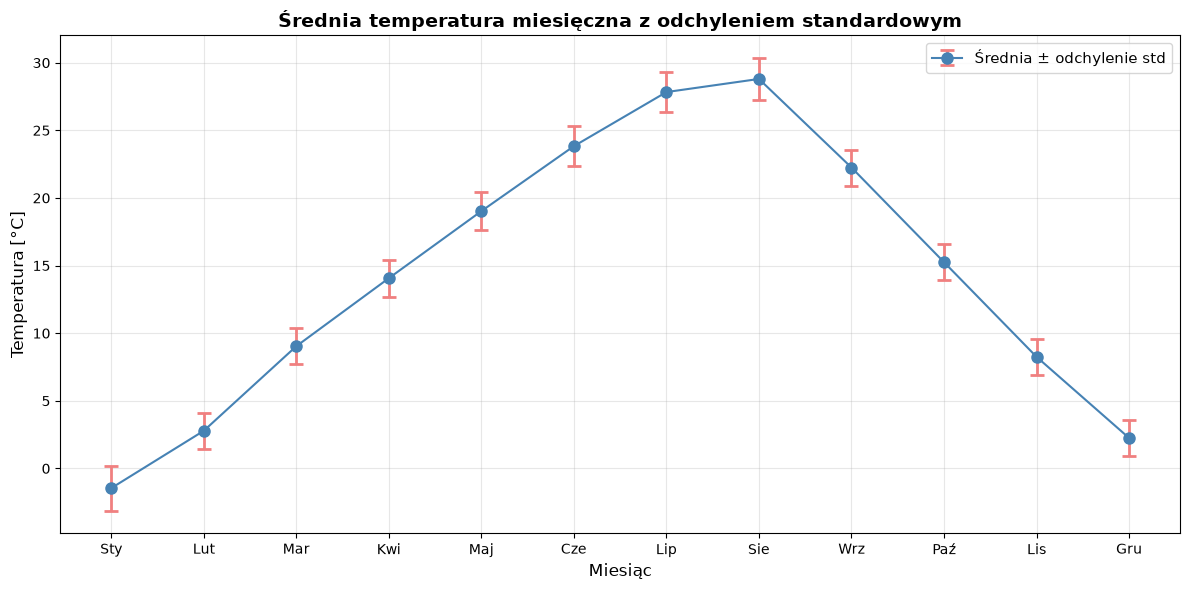

📊 Interpretacja:
  • Punkty = średnia temperatura w każdym miesiącu
  • Paski błędów = odchylenie standardowe (rozrzut temperatur)
  • Długie paski = duża zmienność (np. marzec - przejście zima-wiosna)
  • Krótkie paski = stabilna temperatura (np. lipiec)


In [30]:
# Przygotuj dane - średnia i odchylenie standardowe dla każdego miesiąca
df_pogoda['data'] = pd.to_datetime(df_pogoda['data'])
df_pogoda['miesiac'] = df_pogoda['data'].dt.month

# Oblicz średnią i std dla każdego miesiąca
temp_stats = df_pogoda.groupby('miesiac')['temperatura'].agg(['mean', 'std']).reset_index()

print("Statystyki temperatury według miesięcy:")
print(temp_stats)
print()

# Prosty wykres z error bars
fig, ax = plt.subplots(figsize=(12, 6))

miesiace_num = temp_stats['miesiac']
srednie = temp_stats['mean']
odchylenia = temp_stats['std']

# plt.errorbar(x, y, yerr=błąd)
ax.errorbar(miesiace_num, srednie, yerr=odchylenia, 
            fmt='o-',           # 'o-' = punkty połączone linią
            capsize=5,          # Szerokość "daszków" na końcach pasków
            capthick=2,         # Grubość daszków
            elinewidth=2,       # Grubość pasków błędu
            markersize=8,       # Rozmiar punktów
            color='steelblue',
            ecolor='lightcoral', # Kolor pasków błędu
            label='Średnia ± odchylenie std')

ax.set_title('Średnia temperatura miesięczna z odchyleniem standardowym', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Miesiąc', fontsize=12)
ax.set_ylabel('Temperatura [°C]', fontsize=12)
ax.set_xticks(miesiace_num)
ax.set_xticklabels(['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze', 
                    'Lip', 'Sie', 'Wrz', 'Paź', 'Lis', 'Gru'])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Interpretacja:")
print("  • Punkty = średnia temperatura w każdym miesiącu")
print("  • Paski błędów = odchylenie standardowe (rozrzut temperatur)")
print("  • Długie paski = duża zmienność (np. marzec - przejście zima-wiosna)")
print("  • Krótkie paski = stabilna temperatura (np. lipiec)")

### Przykład 2: Różne style error bars - parametr `fmt`

Parametr `fmt` kontroluje wygląd punktów i linii. Zobaczmy różne opcje:

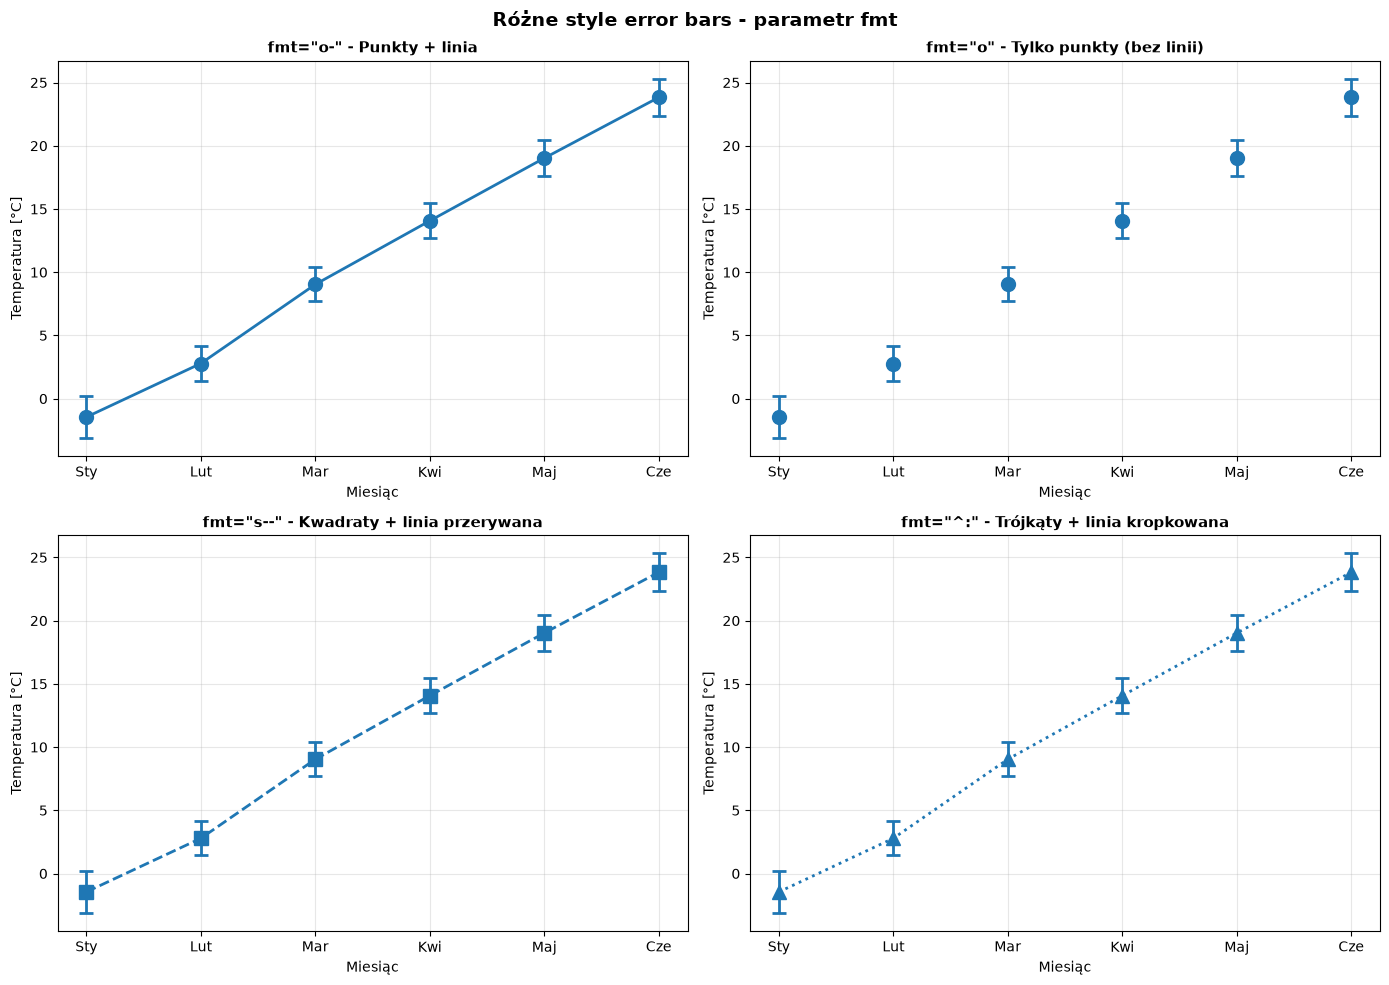

Parametr fmt składa się z 3 części:
  marker + linia + kolor
  Np. 'ro-' = red circles connected with line
       's--' = squares with dashed line
       '^:g' = green triangles with dotted line


In [31]:
# Porównanie różnych stylów error bars
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

# Weź dane dla pierwszych 6 miesięcy (dla czytelności)
dane_6m = temp_stats.head(6)
x = dane_6m['miesiac']
y = dane_6m['mean']
yerr = dane_6m['std']

style_formaty = [
    ('o-', 'Punkty + linia'),
    ('o', 'Tylko punkty (bez linii)'),
    ('s--', 'Kwadraty + linia przerywana'),
    ('^:', 'Trójkąty + linia kropkowana')
]

for i, (fmt, opis) in enumerate(style_formaty):
    axes[i].errorbar(x, y, yerr=yerr, 
                     fmt=fmt, 
                     capsize=5, 
                     capthick=2,
                     markersize=10,
                     linewidth=2,
                     elinewidth=2)
    
    axes[i].set_title(f'fmt="{fmt}" - {opis}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Miesiąc')
    axes[i].set_ylabel('Temperatura [°C]')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze'])
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Różne style error bars - parametr fmt', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Parametr fmt składa się z 3 części:")
print("  marker + linia + kolor")
print("  Np. 'ro-' = red circles connected with line")
print("       's--' = squares with dashed line")
print("       '^:g' = green triangles with dotted line")

### Przykład 3: Porównanie grup z error bars - średnie pensje działów

Error bars są świetne do porównywania grup - pozwalają zobaczyć czy różnice są **istotne**, czy mogą wynikać z przypadku:

Średnia pensja według działów:
       dzial          mean          std
0    Finanse  10228.571429  1831.860881
1         HR   6800.000000   993.310962
2         IT  11161.538462  2545.125054
3  Marketing   5837.500000  1075.622743
4   Sprzedaż   5540.000000   676.756973



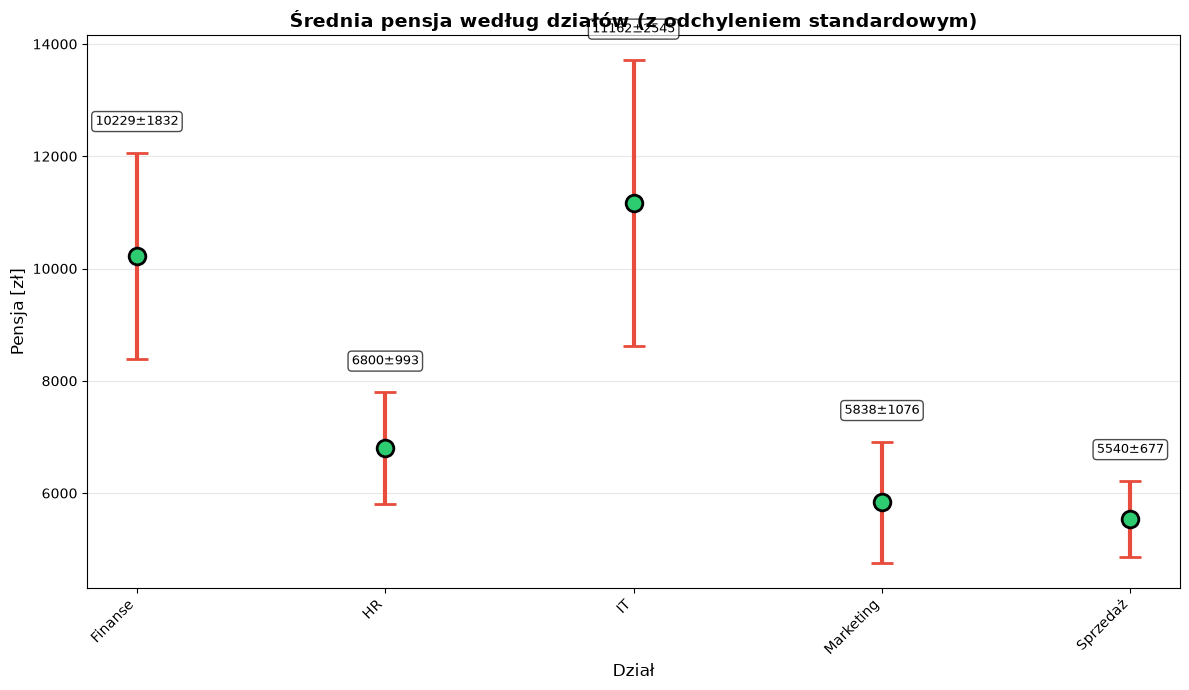

💡 Jak interpretować:
  • Jeśli paski błędów się NIE nakładają → różnica prawdopodobnie istotna
  • Jeśli paski się nakładają → różnica może wynikać z przypadku
  • Przykład: IT vs Marketing - paski się nie nakładają, więc różnica jest wyraźna

⚠️ Uwaga: To uproszczona interpretacja. Dla dokładnej analizy użyj testów statystycznych!


In [32]:
# Porównanie średnich pensji według działów z error bars
pensja_stats = df_prac.groupby('dzial')['pensja'].agg(['mean', 'std']).reset_index()

print("Średnia pensja według działów:")
print(pensja_stats)
print()

fig, ax = plt.subplots(figsize=(12, 7))

dzialy_lista = pensja_stats['dzial']
x_positions = range(len(dzialy_lista))
srednie_pensji = pensja_stats['mean']
std_pensji = pensja_stats['std']

# Error bar plot dla działów
ax.errorbar(x_positions, srednie_pensji, yerr=std_pensji,
            fmt='o',
            capsize=8,
            capthick=3,
            markersize=12,
            elinewidth=3,
            color='#2ecc71',
            ecolor='#e74c3c',
            markeredgecolor='black',
            markeredgewidth=2)

ax.set_title('Średnia pensja według działów (z odchyleniem standardowym)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Dział', fontsize=12)
ax.set_ylabel('Pensja [zł]', fontsize=12)
ax.set_xticks(x_positions)
ax.set_xticklabels(dzialy_lista, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Dodaj wartości na wykresie
for i, (x, y, s) in enumerate(zip(x_positions, srednie_pensji, std_pensji)):
    ax.text(x, y + s + 500, f'{y:.0f}±{s:.0f}', 
            ha='center', fontsize=9, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

print("💡 Jak interpretować:")
print("  • Jeśli paski błędów się NIE nakładają → różnica prawdopodobnie istotna")
print("  • Jeśli paski się nakładają → różnica może wynikać z przypadku")
print("  • Przykład: IT vs Marketing - paski się nie nakładają, więc różnica jest wyraźna")
print()
print("⚠️ Uwaga: To uproszczona interpretacja. Dla dokładnej analizy użyj testów statystycznych!")


---
## Ćwiczenie 3.1 (w trakcie) - Error bars dla opadów według kwartałów

**Cel:** Stworzyć wykres z error bars pokazujący średnie opady w każdym kwartale roku.

**Kontekst zadania:**  
Jesteś hydrolog badającym opady. Chcesz pokazać klientowi (firmie budowlanej), jak wygląda średnia ilość opadów w każdym kwartale roku, wraz z informacją o zmienności.

**Zadanie krok po kroku:**
1. Z danych pogodowych wyciągnij kwartał z kolumny 'data'
   - Podpowiedź: `df_pogoda['kwartal'] = df_pogoda['data'].dt.quarter`
2. Oblicz średnią i odchylenie standardowe opadów dla każdego kwartału (1-4)
   - Użyj `groupby('kwartal')['opady'].agg(['mean', 'std'])`
3. Utwórz wykres errorbar:
   - X = numer kwartału (1, 2, 3, 4)
   - Y = średnie opady
   - yerr = odchylenie standardowe
4. Użyj parametrów:
   - fmt='s-' (kwadraty połączone linią)
   - capsize=6
   - kolor punktów zielony, kolor error bars czerwony
5. Dodaj tytuł, opisy osi, grid
6. Zastanów się: W którym kwartale opady są najbardziej zmienne?

**Czas:** 15 minut

In [ ]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Krok 1: Wyciągnij kwartał
df_pogoda['kwartal'] = df_pogoda['data'].dt.quarter

# Krok 2: Oblicz statystyki
opady_stats = df_pogoda.groupby('kwartal')['opady'].agg(['mean', 'std']).reset_index()

print("Średnie opady według kwartałów:")
print(opady_stats)
print()

# Krok 3 & 4: Utwórz wykres
fig, ax = plt.subplots(figsize=(10, 6))

kwartaly = opady_stats['kwartal']
srednie_opady = opady_stats['mean']
std_opady = opady_stats['std']

ax.errorbar(kwartaly, srednie_opady, yerr=std_opady,
            fmt='s-',           # Kwadraty + linia
            capsize=6,
            capthick=2,
            markersize=12,
            linewidth=2,
            elinewidth=2,
            color='green',
            ecolor='red',
            markeredgecolor='black',
            markeredgewidth=2,
            label='Średnie opady ± std')

ax.set_title('Średnie opady według kwartałów (z odchyleniem standardowym)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Kwartał', fontsize=12)
ax.set_ylabel('Opady [mm]', fontsize=12)
ax.set_xticks(kwartaly)
ax.set_xticklabels(['Q1\n(Sty-Mar)', 'Q2\n(Kwi-Cze)', 
                    'Q3\n(Lip-Wrz)', 'Q4\n(Paź-Gru)'])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analiza
print("\n📊 Analiza wyników:")
print("="*60)
for _, row in opady_stats.iterrows():
    q = int(row['kwartal'])
    m = row['mean']
    s = row['std']
    print(f"Q{q}: średnia={m:.2f}mm, std={s:.2f}mm, zmienność={(s/m*100):.1f}%")

najbardziej_zmienny = opady_stats.loc[opady_stats['std'].idxmax(), 'kwartal']
print(f"\nNajbardziej zmienny: Q{int(najbardziej_zmienny)}")
```

</details>

**Kluczowe spostrzeżenia z Error bars:**

✅ **Error bars świetnie pokazują:**
- Niepewność pomiarową (precyzja instrumentu)
- Zmienność danych (rozrzut wokół średniej)
- Przedziały ufności (gdzie prawdopodobnie leży prawdziwa wartość)
- Czy różnice między grupami są istotne

⚠️ **Ale pamiętaj:**
- Error bar to NIE przedział ufności dla średniej (chyba że tak go oznaczyłeś)
- Standardowe odchylenie ≠ błąd standardowy (SE = SD / √n)
- Jeśli paski się nakładają, różnica może być przypadkowa
- Dla dokładnej analizy użyj testów statystycznych (t-test, ANOVA)

**Najważniejsze parametry `plt.errorbar()`:**
- `yerr` - pionowe paski błędów (może być liczba lub tablica)
- `xerr` - poziome paski błędów (opcjonalne)
- `fmt` - format punktów i linii ('o-', 's--', '^:', etc.)
- `capsize` - szerokość "daszków" na końcach pasków
- `capthick` - grubość daszków
- `elinewidth` - grubość pasków błędu
- `ecolor` - kolor pasków błędu

**Rodzaje błędów do pokazania:**
- **Odchylenie standardowe (SD)** - rozrzut danych wokół średniej
- **Błąd standardowy (SE)** - niepewność samej średniej (SE = SD/√n)
- **Przedział ufności (CI)** - zakres gdzie leży prawdziwa średnia (np. 95% CI)
- **Min/Max** - zakres wartości (rzadko używane, lepszy box plot)

**Kiedy używać error bars:**
- ✅ Prezentacje naukowe (publikacje, konferencje)
- ✅ Porównywanie wyników eksperymentów
- ✅ Dane z pomiarami (fizyka, chemia, biologia)
- ✅ A/B testing (czy wersja B jest lepsza?)
- ❌ NIE: dane bez powtórzeń/pomiarów (jeden pomiar na grupę)

**Alternatywy:**
- Box plot - pokazuje rozkład całych danych (nie tylko średnią)
- Violin plot - kształt rozkładu + statystyki
- Confidence interval bands - ciągłe przedziały (dla funkcji)

---
## 4. Wykres warstwowy - Stacked area plot (`stackplot`)

### Historia z kwartału Q4 - jak szef chciał zobaczyć "całość"

Wyobraź sobie, że jesteś analitykiem sprzedaży. Szef przychodzi do Ciebie w grudniu i pyta:
> "Jak wygląda nasza sprzedaż w czasie? Widzę wykres liniowy dla każdej kategorii, ale **chcę zobaczyć całość** - jak każda kategoria **składa się na całkowitą sprzedaż**."

Możesz pokazać 3 linie na jednym wykresie - ale wtedy nie widać jak wszystko się sumuje.

Możesz pokazać wykres słupkowy stacked - ale wtedy tracisz trend w czasie.

**Rozwiązanie: Stacked area plot!**

To jak wykres liniowy, ale przestrzeń pod każdą linią jest **wypełniona kolorem** i każda kolejna kategoria **nakłada się na poprzednią**, tworząc warstwy.

### Czemu to służy?

**Stacked area plot pokazuje:**
- Jak **części składowe** zmieniają się w czasie
- Jaki jest **trend całości** (górna linia = suma wszystkich kategorii)
- Która kategoria **dominuje** w danym okresie
- Jak **proporcje** między kategoriami się zmieniają

**Kiedy używać:**
- Masz dane czasowe (miesiące, dni, lata)
- Masz 2-5 kategorii, które **sumują się do całości**
- Chcesz pokazać zarówno **trendy**, jak i **proporcje**
- Np.: sprzedaż produktów, budżet według działów, zużycie energii

**Kiedy NIE używać:**
- Kategorie nie sumują się do sensownej całości
- Masz więcej niż 5-6 kategorii (wykres staje się nieczytelny)
- Dokładne wartości są ważne (trudno odczytać środkowe warstwy)

**Różnica vs inne wykresy:**
- **Wykres liniowy** - pokazuje trendy, ale nie proporcje
- **Stacked bar chart** - pokazuje proporcje, ale nie płynny trend w czasie
- **Stacked area plot** - łączy oba: trendy + proporcje ✨

### Przykład 1: Podstawowy stacked area plot - sprzedaż według kategorii

Zobaczmy jak sprzedaż 3 kategorii (Komputery, Peryferia, Audio) kumuluje się w czasie:

Sprzedaż według kategorii i miesięcy:
kategoria      Audio  Komputery  Peryferia
rok_miesiac                               
2023-01       5700.0    22500.0    17700.0
2023-02       6840.0    49100.0    17600.0
2023-03      13860.0    53700.0    21110.0
2023-04      14200.0    69300.0    30150.0
2023-05      17200.0    80500.0    28200.0
2023-06      19440.0    93900.0    36880.0
2023-07      21300.0   111800.0    34050.0
2023-08      18510.0    96200.0    36680.0
2023-09      22610.0   118600.0    35390.0
2023-10      24850.0   132000.0    44750.0

Kategorie: ['Audio', 'Komputery', 'Peryferia']


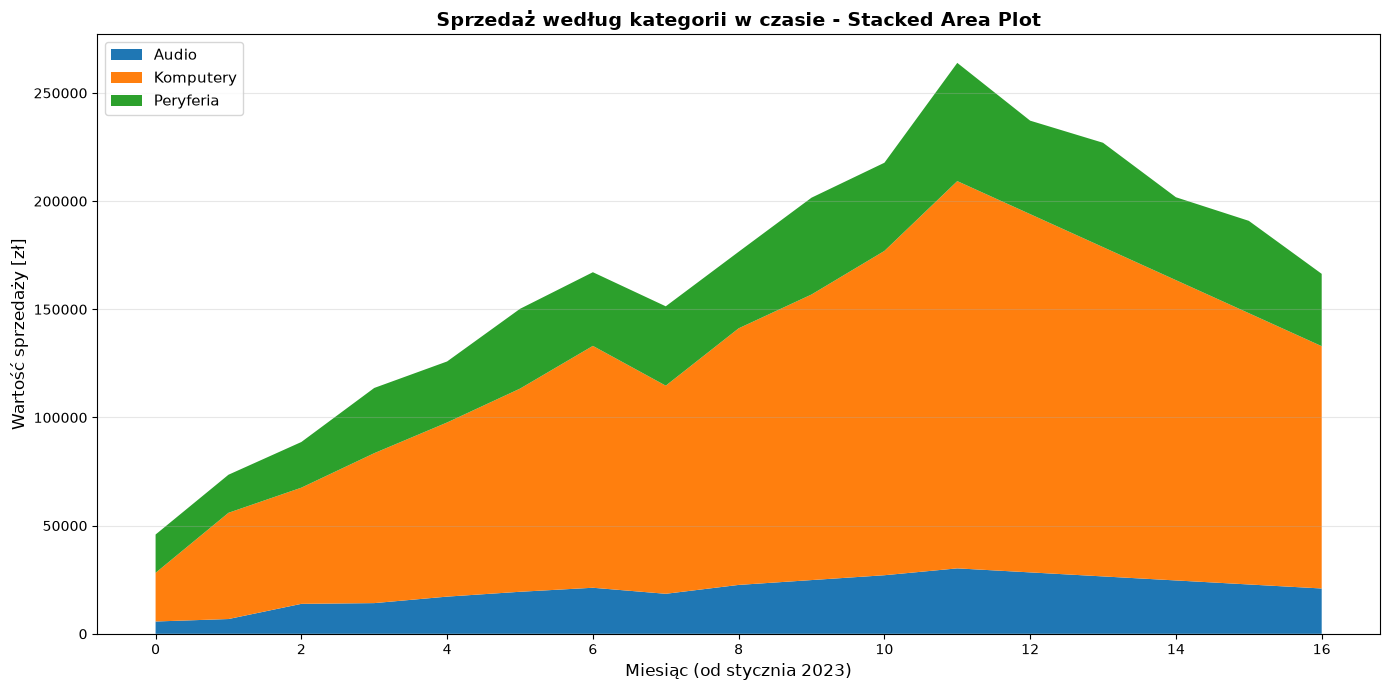


💡 Co widzimy na wykresie?
  • Dolna warstwa (Audio) - najmniejszy udział
  • Środkowa warstwa (Komputery) - największy udział
  • Górna warstwa (Peryferia)
  • Górna linia = całkowita sprzedaż we wszystkich kategoriach
  • Wysokość każdej warstwy = wartość sprzedaży tej kategorii


In [33]:
# Przygotowanie danych - agregacja sprzedaży według miesiąca i kategorii
df_sprzedaz['rok_miesiac'] = df_sprzedaz['data'].dt.to_period('M')

# Suma sprzedaży według miesiąca i kategorii
sprzedaz_kat_czas = df_sprzedaz.groupby(['rok_miesiac', 'kategoria'])['wartosc_sprzedazy'].sum().unstack(fill_value=0)

print("Sprzedaż według kategorii i miesięcy:")
print(sprzedaz_kat_czas.head(10))
print(f"\nKategorie: {sprzedaz_kat_czas.columns.tolist()}")

# Przygotuj dane dla stackplot
miesiace = range(len(sprzedaz_kat_czas))  # Indeksy miesięcy (0, 1, 2, ...)
audio = sprzedaz_kat_czas['Audio'].values
komputery = sprzedaz_kat_czas['Komputery'].values
peryferia = sprzedaz_kat_czas['Peryferia'].values

# Prosty stacked area plot
fig, ax = plt.subplots(figsize=(14, 7))

ax.stackplot(miesiace, audio, komputery, peryferia, 
             labels=['Audio', 'Komputery', 'Peryferia'])

ax.set_title('Sprzedaż według kategorii w czasie - Stacked Area Plot', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Miesiąc (od stycznia 2023)', fontsize=12)
ax.set_ylabel('Wartość sprzedaży [zł]', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Co widzimy na wykresie?")
print("  • Dolna warstwa (Audio) - najmniejszy udział")
print("  • Środkowa warstwa (Komputery) - największy udział")
print("  • Górna warstwa (Peryferia)")
print("  • Górna linia = całkowita sprzedaż we wszystkich kategoriach")
print("  • Wysokość każdej warstwy = wartość sprzedaży tej kategorii")

### Przykład 2: Stylizowany stacked area plot - ładniejsze kolory i formatowanie

Teraz dodajmy custom kolory, przezroczystość i lepsze etykiety osi X:

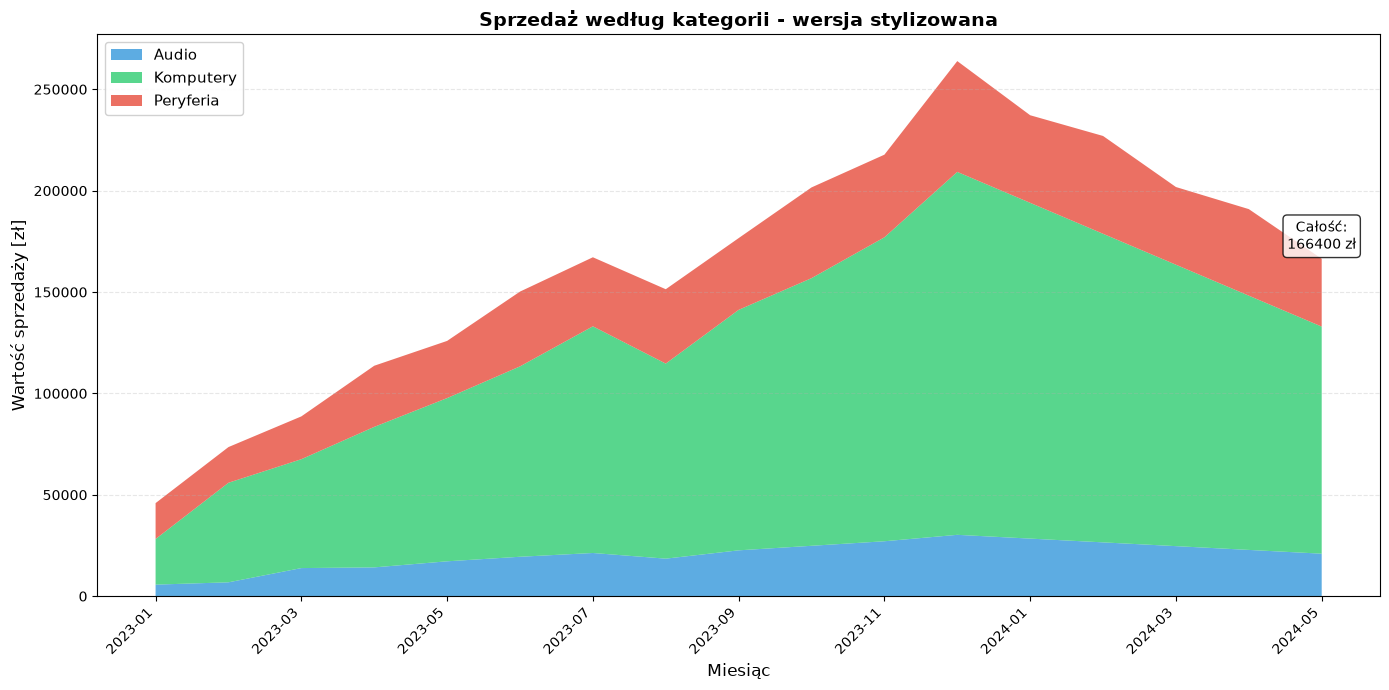

✨ Ulepszenia:
  • Ładniejsze kolory (niebiesko-zielono-czerwone)
  • Alpha=0.8 dla lepszej estetyki
  • Etykiety miesięcy zamiast numerów
  • Anotacja z całkowitą wartością w ostatnim miesiącu


In [34]:
# Stylizowany stacked area plot
fig, ax = plt.subplots(figsize=(14, 7))

# Custom kolory dla każdej kategorii
kolory = ['#3498db', '#2ecc71', '#e74c3c']  # Niebieski, Zielony, Czerwony

ax.stackplot(miesiace, audio, komputery, peryferia, 
             labels=['Audio', 'Komputery', 'Peryferia'],
             colors=kolory,
             alpha=0.8)  # Przezroczystość

# Lepsza oś X - nazwy miesięcy zamiast numerów
etykiety_miesiecy = [str(m) for m in sprzedaz_kat_czas.index]
# Pokaż co 2. miesiąc (żeby nie było za gęsto)
ax.set_xticks(range(0, len(miesiace), 2))
ax.set_xticklabels(etykiety_miesiecy[::2], rotation=45, ha='right')

ax.set_title('Sprzedaż według kategorii - wersja stylizowana', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Miesiąc', fontsize=12)
ax.set_ylabel('Wartość sprzedaży [zł]', fontsize=12)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Dodaj wartość całkowitej sprzedaży w ostatnim miesiącu
ostatni_miesiac_idx = len(miesiace) - 1
calkowita_ostatni = audio[-1] + komputery[-1] + peryferia[-1]
ax.text(ostatni_miesiac_idx, calkowita_ostatni + 5000, 
        f'Całość:\n{calkowita_ostatni:.0f} zł', 
        ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("✨ Ulepszenia:")
print("  • Ładniejsze kolory (niebiesko-zielono-czerwone)")
print("  • Alpha=0.8 dla lepszej estetyki")
print("  • Etykiety miesięcy zamiast numerów")
print("  • Anotacja z całkowitą wartością w ostatnim miesiącu")

### Przykład 3: Porównanie - Stacked area vs Line plot vs Stacked bar

**Pytanie:** Kiedy stackplot, a kiedy inny wykres?

Zobaczmy te same dane na 3 sposoby:

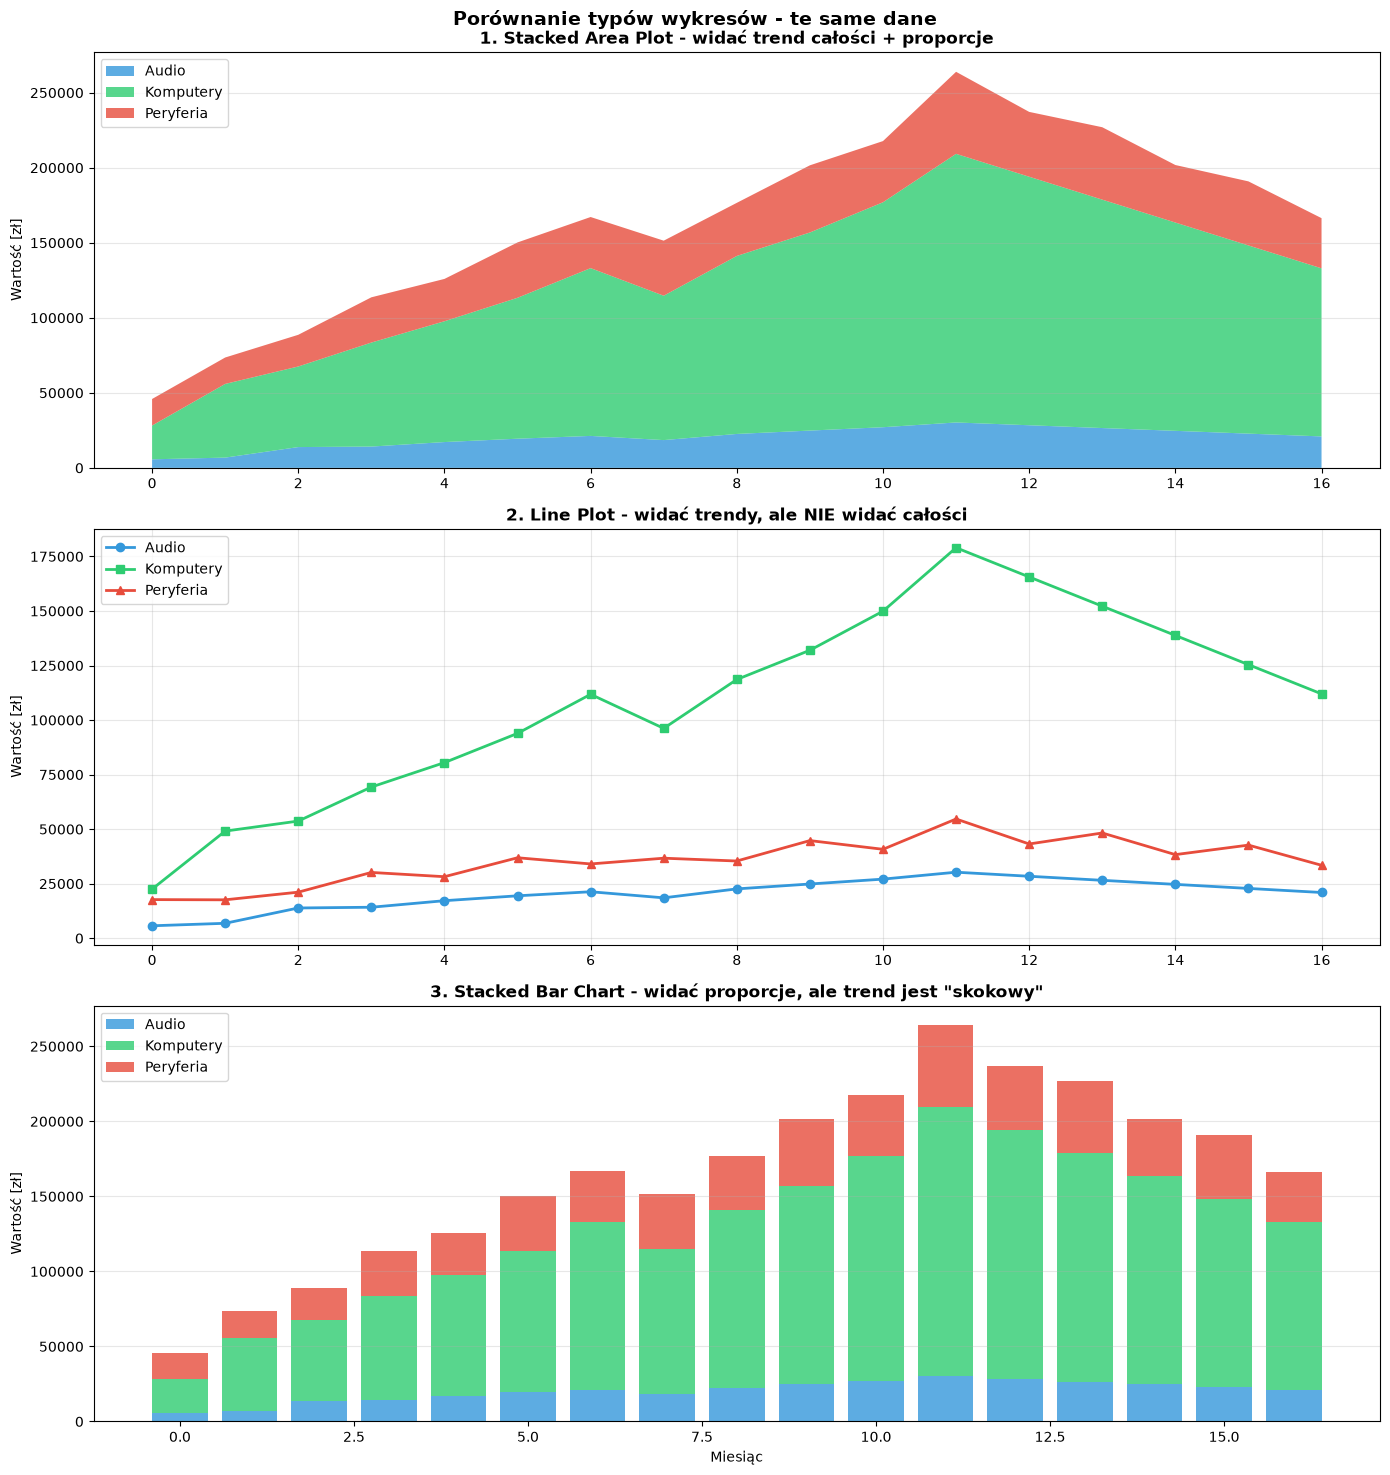


📊 Które wybrać?
✅ STACKED AREA PLOT - gdy:
   • Chcesz pokazać zarówno trend całości, jak i proporcje
   • Masz dane czasowe (ciągłe)
   • Kategorie sumują się do sensownej całości
   • Przykład: budżet, zużycie energii, sprzedaż produktów

✅ LINE PLOT - gdy:
   • Chcesz porównać trendy między kategoriami
   • Kategorie NIE sumują się (są niezależne)
   • Przykład: temperatura w różnych miastach

✅ STACKED BAR CHART - gdy:
   • Masz dane dyskretne (nie ciągłe w czasie)
   • Dokładne wartości są ważne
   • Przykład: budżet według działów w różnych latach


In [35]:
# Porównanie 3 typów wykresów
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

kolory = ['#3498db', '#2ecc71', '#e74c3c']

# 1. Stacked area plot
axes[0].stackplot(miesiace, audio, komputery, peryferia, 
                  labels=['Audio', 'Komputery', 'Peryferia'],
                  colors=kolory, alpha=0.8)
axes[0].set_title('1. Stacked Area Plot - widać trend całości + proporcje', 
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Wartość [zł]')
axes[0].legend(loc='upper left')
axes[0].grid(axis='y', alpha=0.3)

# 2. Line plot (zwykłe linie)
axes[1].plot(miesiace, audio, label='Audio', color=kolory[0], linewidth=2, marker='o')
axes[1].plot(miesiace, komputery, label='Komputery', color=kolory[1], linewidth=2, marker='s')
axes[1].plot(miesiace, peryferia, label='Peryferia', color=kolory[2], linewidth=2, marker='^')
axes[1].set_title('2. Line Plot - widać trendy, ale NIE widać całości', 
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Wartość [zł]')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# 3. Stacked bar chart
axes[2].bar(miesiace, audio, label='Audio', color=kolory[0], alpha=0.8)
axes[2].bar(miesiace, komputery, bottom=audio, label='Komputery', color=kolory[1], alpha=0.8)
axes[2].bar(miesiace, peryferia, bottom=audio+komputery, label='Peryferia', color=kolory[2], alpha=0.8)
axes[2].set_title('3. Stacked Bar Chart - widać proporcje, ale trend jest "skokowy"', 
                   fontsize=12, fontweight='bold')
axes[2].set_xlabel('Miesiąc')
axes[2].set_ylabel('Wartość [zł]')
axes[2].legend(loc='upper left')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Porównanie typów wykresów - te same dane', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Które wybrać?")
print("="*60)
print("✅ STACKED AREA PLOT - gdy:")
print("   • Chcesz pokazać zarówno trend całości, jak i proporcje")
print("   • Masz dane czasowe (ciągłe)")
print("   • Kategorie sumują się do sensownej całości")
print("   • Przykład: budżet, zużycie energii, sprzedaż produktów")
print()
print("✅ LINE PLOT - gdy:")
print("   • Chcesz porównać trendy między kategoriami")
print("   • Kategorie NIE sumują się (są niezależne)")
print("   • Przykład: temperatura w różnych miastach")
print()
print("✅ STACKED BAR CHART - gdy:")
print("   • Masz dane dyskretne (nie ciągłe w czasie)")
print("   • Dokładne wartości są ważne")
print("   • Przykład: budżet według działów w różnych latach")

---
## Ćwiczenie 4.1 (w trakcie) - Stacked area plot dla top 4 produktów

**Cel:** Stworzyć stacked area plot pokazujący sprzedaż top 4 produktów w czasie.

**Kontekst zadania:**  
Szef marketingu chce zobaczyć, jak 4 najpopularniejsze produkty (według całkowitej sprzedaży) radzą sobie w czasie. Chce wiedzieć:
- Który produkt dominuje?
- Czy proporcje się zmieniają?
- Jaki jest trend całkowitej sprzedaży tych 4 produktów?

**Zadanie krok po kroku:**
1. Znajdź top 4 produkty według całkowitej wartości sprzedaży
   - Podpowiedź: `df_sprzedaz.groupby('produkt')['wartosc_sprzedazy'].sum().nlargest(4)`
2. Przefiltruj dane sprzedaży tylko dla tych 4 produktów
3. Agreguj sprzedaż według miesiąca i produktu
   - Użyj `groupby(['rok_miesiac', 'produkt'])` i `.unstack(fill_value=0)`
4. Utwórz stacked area plot z:
   - Custom kolorami (np. 4 różne kolory)
   - Legendą
   - Tytułem "Top 4 produkty - sprzedaż w czasie"
   - Opisami osi
5. Dodaj grid dla lepszej czytelności

**Czas:** 20 minut

In [ ]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Krok 1: Znajdź top 4 produkty
top4_produkty = df_sprzedaz.groupby('produkt')['wartosc_sprzedazy'].sum().nlargest(4)
print("Top 4 produkty według wartości sprzedaży:")
print(top4_produkty)
print()

# Krok 2: Przefiltruj dane tylko dla top 4
df_top4 = df_sprzedaz[df_sprzedaz['produkt'].isin(top4_produkty.index)]

# Krok 3: Agreguj według miesiąca i produktu
sprzedaz_prod_czas = df_top4.groupby(['rok_miesiac', 'produkt'])['wartosc_sprzedazy'].sum().unstack(fill_value=0)
print("Sprzedaż top 4 produktów w czasie:")
print(sprzedaz_prod_czas.head())
print()

# Przygotuj dane dla stackplot
miesiace_prod = range(len(sprzedaz_prod_czas))
produkty_series = [sprzedaz_prod_czas[prod].values for prod in sprzedaz_prod_czas.columns]

# Krok 4: Utwórz stacked area plot
fig, ax = plt.subplots(figsize=(14, 7))

kolory_prod = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']  # Niebieski, Czerwony, Zielony, Pomarańczowy

ax.stackplot(miesiace_prod, *produkty_series, 
             labels=sprzedaz_prod_czas.columns,
             colors=kolory_prod,
             alpha=0.8)

ax.set_title('Top 4 produkty - sprzedaż w czasie', fontsize=14, fontweight='bold')
ax.set_xlabel('Miesiąc', fontsize=12)
ax.set_ylabel('Wartość sprzedaży [zł]', fontsize=12)
ax.legend(loc='upper left', fontsize=11, title='Produkt')
ax.grid(axis='y', alpha=0.3)

# Dodaj etykiety miesięcy na osi X
etykiety_m = [str(m) for m in sprzedaz_prod_czas.index]
ax.set_xticks(range(0, len(miesiace_prod), 2))
ax.set_xticklabels(etykiety_m[::2], rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Analiza
print("\n📈 Analiza wyników:")
print("="*60)
for produkt in top4_produkty.index:
    total = top4_produkty[produkt]
    print(f"{produkt:15s}: {total:>12,.2f} zł")
    
print(f"\n{'SUMA TOP 4':15s}: {top4_produkty.sum():>12,.2f} zł")
print(f"% całkowitej sprzedaży: {(top4_produkty.sum() / df_sprzedaz['wartosc_sprzedazy'].sum() * 100):.1f}%")
```

</details>

**Kluczowe spostrzeżenia ze Stacked Area Plot:**

✅ **Stacked area plot świetnie pokazuje:**
- Trend całości (górna linia = suma wszystkich kategorii)
- Zmianę proporcji w czasie (szerokość każdej warstwy)
- Dominujące kategorie (które zajmują najwięcej przestrzeni)
- Płynne przejścia (lepsze niż skokowe słupki)

⚠️ **Ale pamiętaj:**
- Trudno odczytać dokładne wartości środkowych warstw
- Nie używaj dla więcej niż 5-6 kategorii (staje się nieczytelny)
- Kategorie powinny się sumować do sensownej całości
- Kolejność warstw ma znaczenie (największe często daje się na dole lub górze)

**Kiedy używać stackplot:**
- ✅ Budżet według działów w czasie
- ✅ Zużycie energii według źródeł
- ✅ Sprzedaż produktów w czasie
- ✅ Liczba użytkowników według platform
- ❌ NIE: dane które się nie sumują (np. temperatura w różnych miastach)

**Najważniejsze parametry `plt.stackplot()`:**
- `labels` - nazwy kategorii dla legendy
- `colors` - kolory warstw (lista)
- `alpha` - przezroczystość (0-1)
- `baseline` - jak układać warstwy ('zero', 'sym', 'wiggle', 'weighted_wiggle')

**Alternatywy:**
- Line plot - gdy kategorie nie sumują się
- Stacked bar chart - dla danych dyskretnych
- 100% stacked area - gdy chcesz pokazać tylko proporcje (nie wartości bezwzględne)

---
## 5. Wykres kołowy - Pie chart (`pie`)

Wykres kołowy pokazuje **proporcje części do całości**.

**Kiedy używać (ostrożnie!):**
- Masz 2-5 kategorii
- Kategorie sumują się do 100%
- Chcesz pokazać proporcje

**Kiedy NIE używać:**
- Więcej niż 5-7 kategorii → użyj wykresu słupkowego
- Porównanie wielu grup → użyj wykresu słupkowego
- Dokładne wartości są ważne → użyj wykresu słupkowego

**Uwaga:** Wykres kołowy jest często nadużywany. W większości przypadków wykres słupkowy jest lepszy!

### Przykład 1: Podstawowy pie chart - udział kategorii w sprzedaży

In [36]:
# Agregacja - suma sprzedaży według kategorii
sprzedaz_kat = df_sprzedaz.groupby('kategoria')['wartosc_sprzedazy'].sum()

print(sprzedaz_kat)
print(f"\nCałkowita sprzedaż: {sprzedaz_kat.sum():.2f} zł")

kategoria
Audio         345260.0
Komputery    1850500.0
Peryferia     603800.0
Name: wartosc_sprzedazy, dtype: float64

Całkowita sprzedaż: 2799560.00 zł


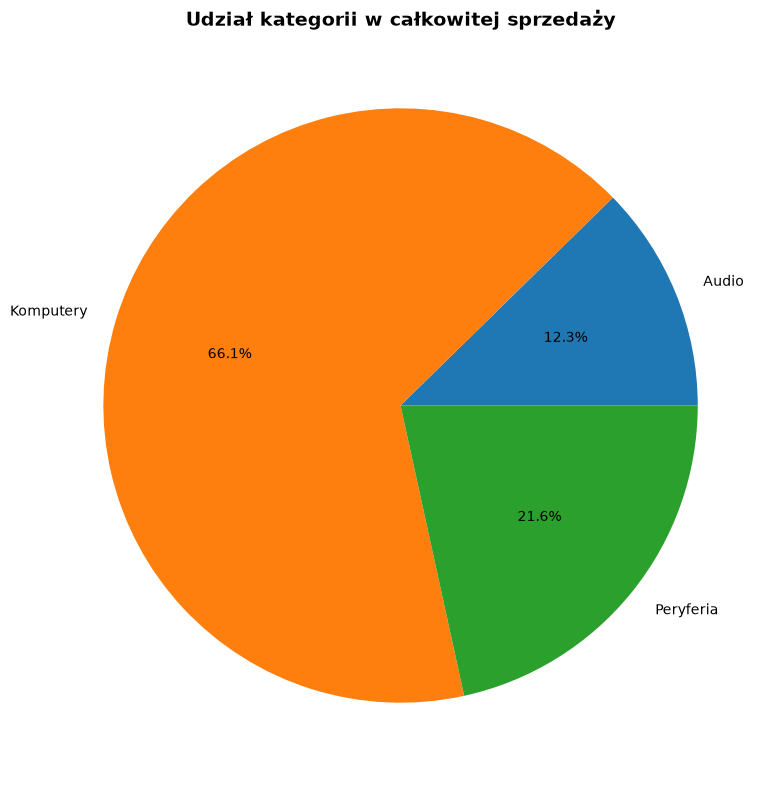

In [37]:
# Prosty wykres kołowy
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(sprzedaz_kat.values, labels=sprzedaz_kat.index, autopct='%1.1f%%')

ax.set_title('Udział kategorii w całkowitej sprzedaży', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**💡 Co to jest `autopct`?**

Parametr `autopct` automatycznie dodaje **etykiety procentowe** na wykresie kołowym.

**Składnia formatowania:**
```python
autopct='%1.1f%%'
```

Rozbijmy to:
- `%` - początek formatu
- `1.1f` - format liczby zmiennoprzecinkowej:
  - `1` przed kropką = minimalna szerokość (ignorowane dla procentów)
  - `.1` = **1 cyfra po przecinku**
  - `f` = float (liczba zmiennoprzecinkowa)
- `%%` - wyświetl znak `%` (podwójne %% potrzebne, bo pojedyncze % ma specjalne znaczenie)

**Przykłady:**

```python
autopct='%1.1f%%'  → "25.5%"   # 1 cyfra po przecinku
autopct='%1.0f%%'  → "26%"     # 0 cyfr (zaokrąglenie)
autopct='%.2f%%'   → "25.50%"  # 2 cyfry po przecinku
autopct='%d%%'     → "25%"     # liczba całkowita (bez przecinka)
```

Jeśli nie podasz `autopct`, wykres kołowy **nie** będzie miał procentów na wycinkach.

### Przykład 2: Pie chart z dostosowaniem

Dodajmy więcej opcji stylizacji:

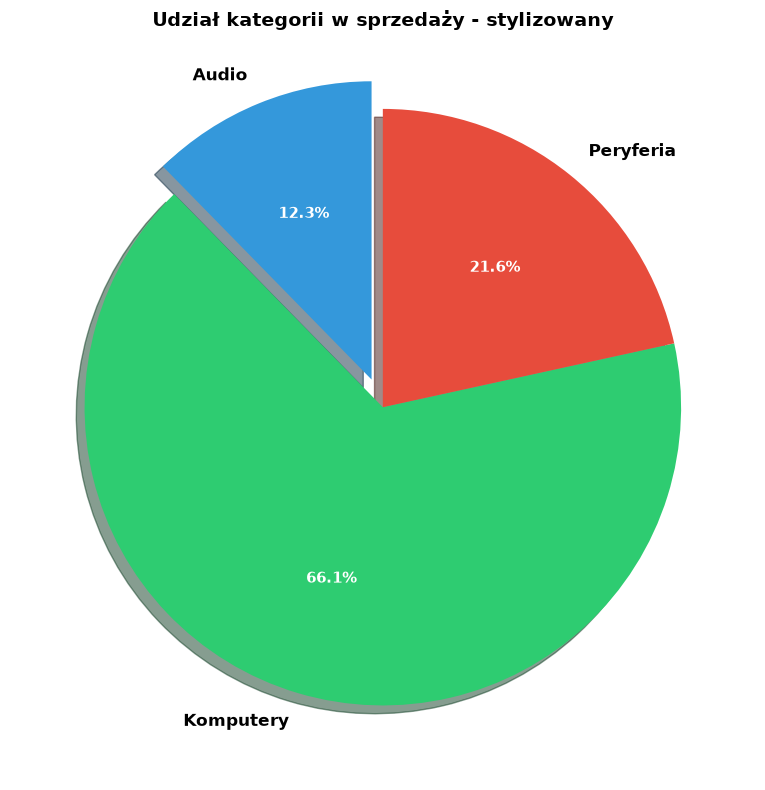

In [20]:
# Zaawansowany pie chart
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#3498db', '#2ecc71', '#e74c3c']
explode = (0.1, 0, 0)  # "Wysunięcie" pierwszego wycinka

wedges, texts, autotexts = ax.pie(sprzedaz_kat.values, 
                                    labels=sprzedaz_kat.index, 
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    explode=explode,
                                    shadow=True,
                                    startangle=90)  # Rozpocznij od góry

# Dostosuj czcionki
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Udział kategorii w sprzedaży - stylizowany', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Przykład 3: Porównanie - Pie chart vs Bar chart

Zobacz, dlaczego czasem wykres słupkowy jest lepszy:

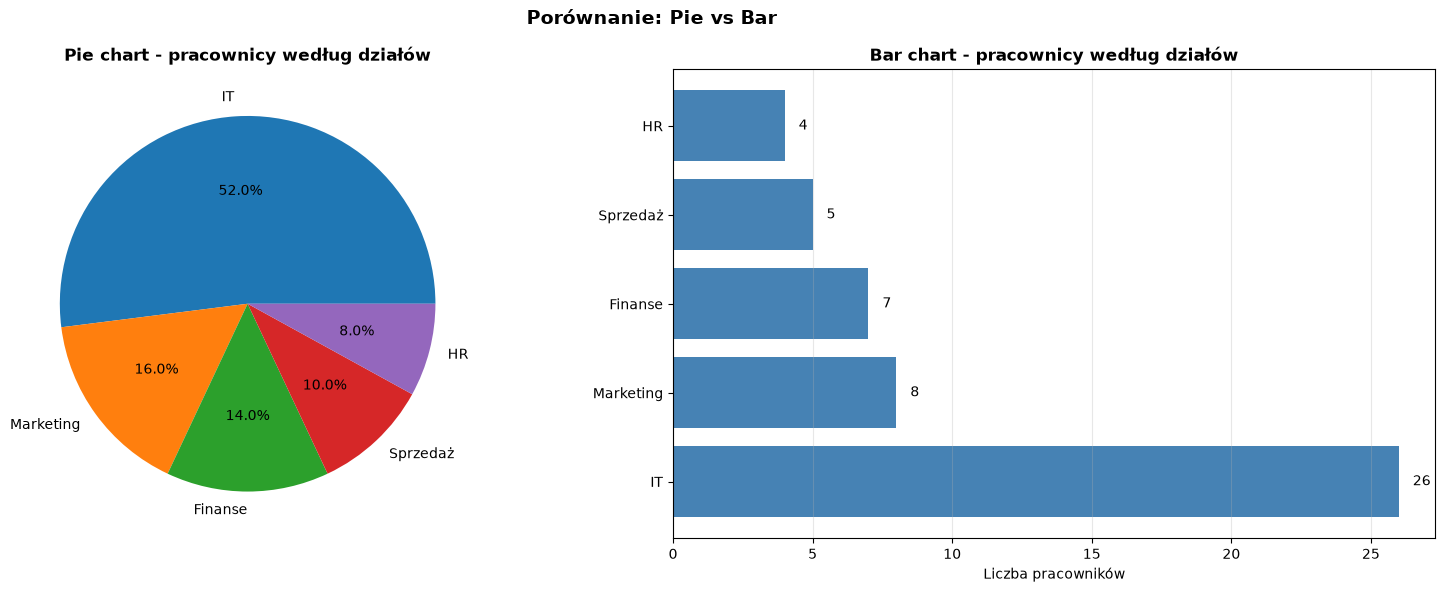

Który wykres jest łatwiejszy do odczytania?
Bar chart pozwala na dokładniejsze porównanie wartości!


In [38]:
# Dane z wieloma kategoriami - pracownicy według działów
prac_dzialy = df_prac['dzial'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
axes[0].pie(prac_dzialy.values, labels=prac_dzialy.index, autopct='%1.1f%%')
axes[0].set_title('Pie chart - pracownicy według działów', fontsize=12, fontweight='bold')

# Bar chart
axes[1].barh(prac_dzialy.index, prac_dzialy.values, color='steelblue')
axes[1].set_title('Bar chart - pracownicy według działów', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Liczba pracowników')
axes[1].grid(axis='x', alpha=0.3)

# Dodaj wartości na słupkach
for i, v in enumerate(prac_dzialy.values):
    axes[1].text(v + 0.5, i, str(v), va='center')

plt.suptitle('Porównanie: Pie vs Bar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Który wykres jest łatwiejszy do odczytania?")
print("Bar chart pozwala na dokładniejsze porównanie wartości!")

---
## Ćwiczenie 5.0.1 (w trakcie) - Wykres kołowy

**Cel:** Stworzyć wykres kołowy dla sprzedaży produktów.

**Zadanie:**
1. Oblicz całkowitą wartość sprzedaży dla każdego produktu
2. Wybierz top 5 produktów
3. Utwórz wykres kołowy
4. Użyj `autopct` do pokazania procentów
5. Wysun największy wycinek (użyj `explode`)
6. Dodaj tytuł

**Wskazówka:** 
- Użyj `df.groupby('produkt')['wartosc_sprzedazy'].sum().nlargest(5)`
- explode to krotka, np. (0.1, 0, 0, 0, 0)

**Czas:** 15 minut

In [ ]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Top 5 produktów
top5_produkty = df_sprzedaz.groupby('produkt')['wartosc_sprzedazy'].sum().nlargest(5)

print("Top 5 produktów:")
print(top5_produkty)

# Wykres kołowy
fig, ax = plt.subplots(figsize=(10, 8))

# Wysun największy wycinek (pierwszy w posortowanej liście)
explode = (0.1, 0, 0, 0, 0)

wedges, texts, autotexts = ax.pie(top5_produkty.values, 
                                    labels=top5_produkty.index, 
                                    autopct='%1.1f%%',
                                    explode=explode,
                                    shadow=True,
                                    startangle=90)

# Stylizacja
for text in texts:
    text.set_fontsize(11)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Top 5 produktów według wartości sprzedaży', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nNajlepszy produkt: {top5_produkty.index[0]} ({top5_produkty.values[0]:.2f} zł)")
```

</details>

---
## Ćwiczenie 5.0.2 (do domu) - Porównanie pie chart vs bar chart

**Cel:** Przekonać się, kiedy wykres słupkowy jest lepszy.

**Zadanie:**
1. Oblicz liczbę transakcji dla każdego produktu (nie wartość, tylko liczba wierszy)
2. Weź top 8 produktów
3. Utwórz figurę z dwoma wykresami obok siebie:
   - Lewy: pie chart
   - Prawy: bar chart (poziomy)
4. Porównaj czytelność obu wykresów
5. Napisz w komentarzu, który jest lepszy i dlaczego

**Wskazówka:** Użyj `df['produkt'].value_counts().nlargest(8)`

**Czas:** 20 minut

In [23]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Top 8 produktów według liczby transakcji
top8_liczba = df_sprzedaz['produkt'].value_counts().nlargest(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
axes[0].pie(top8_liczba.values, labels=top8_liczba.index, autopct='%1.1f%%')
axes[0].set_title('Pie chart - liczba transakcji', fontsize=12, fontweight='bold')

# Bar chart
axes[1].barh(top8_liczba.index, top8_liczba.values, color='coral')
axes[1].set_title('Bar chart - liczba transakcji', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Liczba transakcji')
axes[1].grid(axis='x', alpha=0.3)

# Dodaj wartości
for i, v in enumerate(top8_liczba.values):
    axes[1].text(v + 0.3, i, str(v), va='center')

plt.suptitle('Pie chart vs Bar chart - 8 kategorii', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# WNIOSKI:
print("\n" + "="*60)
print("WNIOSKI:")
print("="*60)
print("Bar chart jest ZDECYDOWANIE lepszy, ponieważ:")
print("  1. Łatwiej porównać wartości (wysokość słupków)")
print("  2. Możemy dokładnie odczytać liczby")
print("  3. Nazwy produktów są czytelne (nie nachodzą na siebie)")
print("  4. Można łatwo posortować według wartości")
print("\nPie chart z 8 kategoriami:")
print("  - Trudno porównać podobne wartości")
print("  - Etykiety nachodzą na siebie")
print("  - Procenty są mniej intuicyjne niż konkretne liczby")
print("\n➡️ ZASADA: Jeśli masz więcej niż 5 kategorii, użyj bar chart!")
```

</details>

---
## 5.1. Wykres Donut (Pie chart z dziurą) - zaawansowana wersja pie chart

### Od prostego koła do pączka - ewolucja wykresu kołowego

Pamiętasz podstawowy pie chart? Działa świetnie, ale czasami wygląda trochę... nudno. A co jeśli chcesz:
- **Więcej stylu** - nowoczesny wygląd dla prezentacji
- **Miejsce na dane w środku** - np. całkowitą wartość
- **Hierarchię** - pokazać kategorie i podkategorie jednocześnie

**Rozwiązanie: Donut chart!**

To jak zwykły pie chart, ale z "dziurą" w środku. Dzięki temu:
- Wygląda nowocześniej i lżej
- Możesz dodać tekst/wartość w środku
- Łatwiej czytać proporcje (cieńsze wycinki)

### Co to jest Donut chart?

**Donut chart** = wykres kołowy z pustym środkiem (jak pączek 🍩)

**Jak to działa techniczne:**  
Parametr `wedgeprops={'width': 0.3}` kontroluje grubość "pączka":
- `width=0.3` → wąski pierścień (szeroka dziura)
- `width=0.5` → grubszy pierścień  
- `width=1.0` → zwykły pie chart (bez dziury)

**Kiedy używać:**
- Prezentacje biznesowe (wygląda profesjonalniej)
- Gdy chcesz dodać wartość w środku (np. "Suma: 100K zł")
- Hierarchiczne dane (nested donut - kategorie i podkategorie)
- Dashboardy i raporty wizualne

### Przykład 1: Podstawowy donut chart - kategorie sprzedaży

Przekształćmy nasz zwykły pie chart w donut chart jedną linijką kodu:

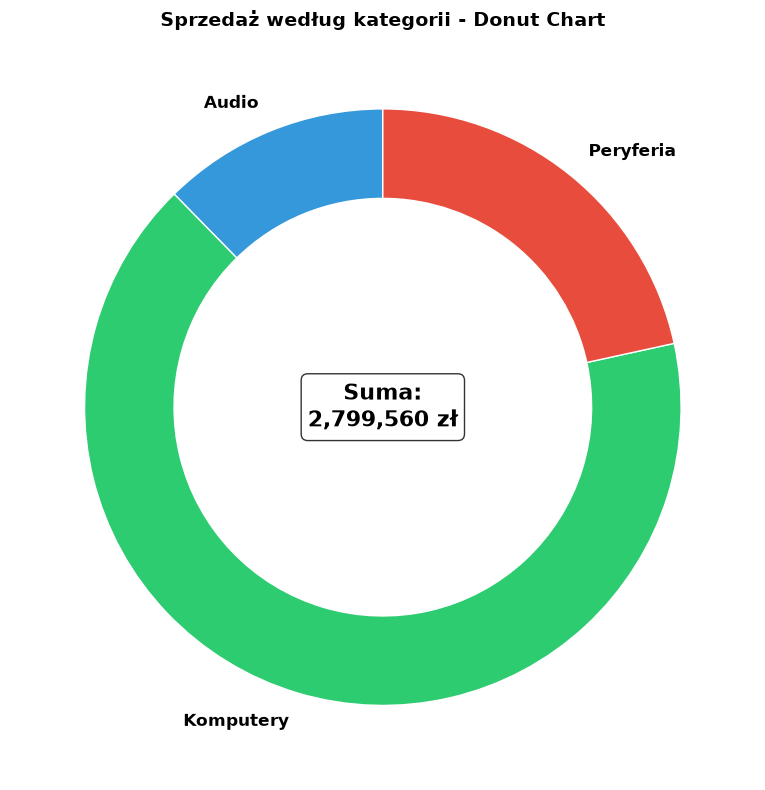

💡 Kluczowe parametry:
  • wedgeprops={'width': 0.3} - tworzy dziurę (width = grubość pierścienia)
  • width=0.3 → wąski pierścień, width=0.5 → szerszy
  • edgecolor='white' → białe obramowanie między wycinkami
  • Tekst w środku dodany przez ax.text(0, 0, ...)


In [39]:
# Dane - te same co w podstawowym pie chart
sprzedaz_kat = df_sprzedaz.groupby('kategoria')['wartosc_sprzedazy'].sum()

# Donut chart - zauważ parametr wedgeprops
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#3498db', '#2ecc71', '#e74c3c']

wedges, texts, autotexts = ax.pie(
    sprzedaz_kat.values, 
    labels=sprzedaz_kat.index, 
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'width': 0.3, 'edgecolor': 'white'}  # <- TO TWORZY DONUT!
)

# Stylizacja tekstów
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Sprzedaż według kategorii - Donut Chart', fontsize=14, fontweight='bold')

# Dodaj tekst w środku - całkowita sprzedaż
total = sprzedaz_kat.sum()
ax.text(0, 0, f'Suma:\n{total:,.0f} zł', 
        ha='center', va='center', 
        fontsize=16, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("💡 Kluczowe parametry:")
print("  • wedgeprops={'width': 0.3} - tworzy dziurę (width = grubość pierścienia)")
print("  • width=0.3 → wąski pierścień, width=0.5 → szerszy")
print("  • edgecolor='white' → białe obramowanie między wycinkami")
print("  • Tekst w środku dodany przez ax.text(0, 0, ...)")

### Przykład 2: Różne grubości donut - parametr `width`

Zobaczmy jak parametr `width` wpływa na wygląd:

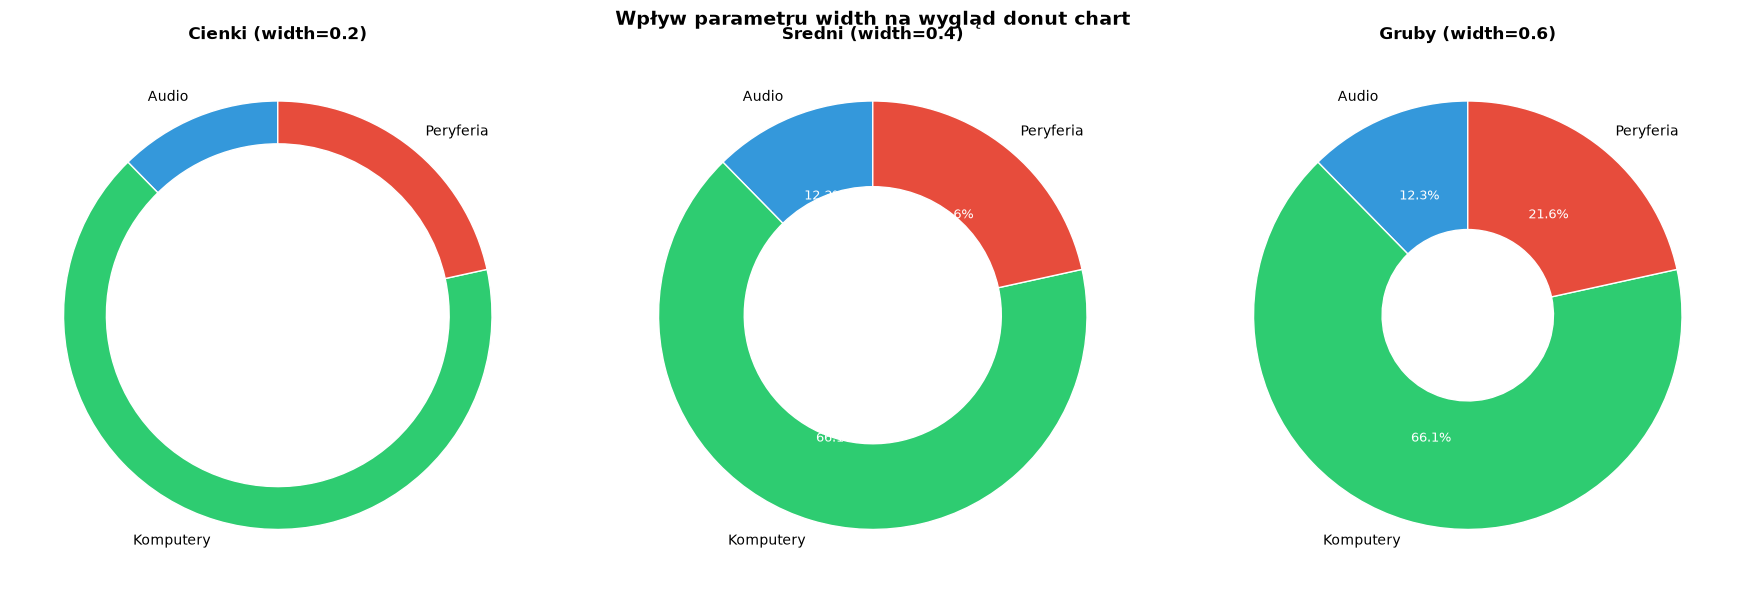

📊 Która szerokość jest najlepsza?
  • width=0.2-0.3 → dobrze gdy chcesz dużo tekstu w środku
  • width=0.4-0.5 → uniwersalna, najbardziej 'donutowa'
  • width=0.6+ → gdy proporcje są ważniejsze niż estetyka


In [40]:
# Porównanie różnych szerokości donut
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

widths = [0.2, 0.4, 0.6]
titles = ['Cienki (width=0.2)', 'Średni (width=0.4)', 'Gruby (width=0.6)']

for ax, width, title in zip(axes, widths, titles):
    wedges, texts, autotexts = ax.pie(
        sprzedaz_kat.values,
        labels=sprzedaz_kat.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        wedgeprops={'width': width, 'edgecolor': 'white'}
    )
    
    # Stylizacja
    for text in texts:
        text.set_fontsize(10)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(9)
    
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Wpływ parametru width na wygląd donut chart', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Która szerokość jest najlepsza?")
print("  • width=0.2-0.3 → dobrze gdy chcesz dużo tekstu w środku")
print("  • width=0.4-0.5 → uniwersalna, najbardziej 'donutowa'")
print("  • width=0.6+ → gdy proporcje są ważniejsze niż estetyka")

### Przykład 3: Nested Donut Chart - kategorie i produkty jednocześnie!

**Zaawansowana technika**: Możesz nałożyć dwa donut charts, tworząc hierarchię:
- **Zewnętrzny pierścień** - produkty
- **Wewnętrzny pierścień** - kategorie

To pozwala pokazać 2 poziomy informacji na jednym wykresie!

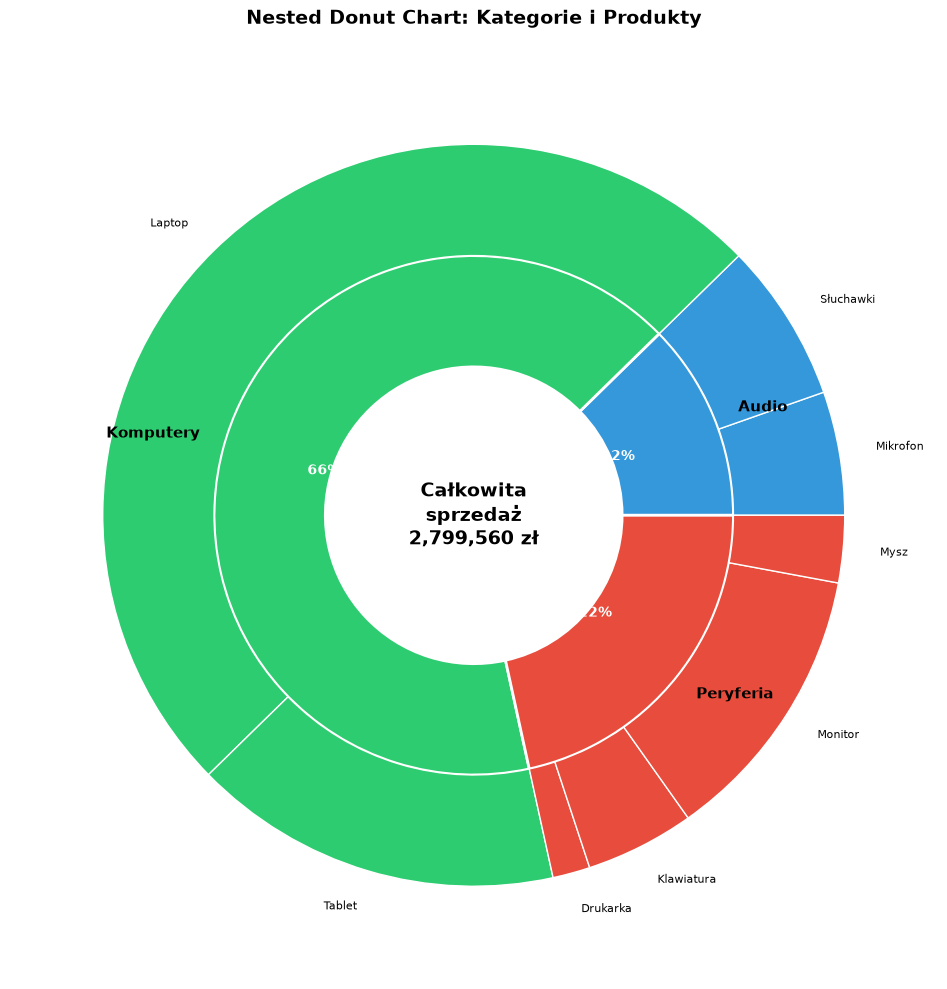

🎯 Nested Donut Chart:
  • Wewnętrzny pierścień = kategorie (szeroki przegląd)
  • Zewnętrzny pierścień = produkty (szczegóły)
  • Kolory zewnętrznego odpowiadają kolorom wewnętrznego
  • Idealne do pokazania hierarchii!


In [41]:
# Nested donut: Wewnętrzny = kategorie, Zewnętrzny = produkty

# Przygotuj dane
sprzedaz_prod = df_sprzedaz.groupby(['kategoria', 'produkt'])['wartosc_sprzedazy'].sum()

# Dane dla wewnętrznego donut (kategorie)
kategorie_wartosci = df_sprzedaz.groupby('kategoria')['wartosc_sprzedazy'].sum()

# Dane dla zewnętrznego donut (produkty w ramach kategorii)
produkty_wartosci = sprzedaz_prod.values
produkty_nazwy = [f"{kat}:{prod}" for kat, prod in sprzedaz_prod.index]

fig, ax = plt.subplots(figsize=(12, 10))

size_inner = 0.3  # Grubość wewnętrznego pierścienia
size_outer = 0.3  # Grubość zewnętrznego pierścienia

# Kolory dla kategorii (wewnętrzny)
kolory_kategorii = ['#3498db', '#2ecc71', '#e74c3c']

# Kolory dla produktów (zewnętrzny) - odcienie kategorii
import matplotlib.cm as cm
kolory_produkty = []
for i, kat in enumerate(kategorie_wartosci.index):
    liczba_prod = len([p for k, p in sprzedaz_prod.index if k == kat])
    # Generuj odcienie tego samego koloru
    base_color = kolory_kategorii[i]
    kolory_produkty.extend([base_color] * liczba_prod)

# Wewnętrzny donut (kategorie)
wedges_inner, texts_inner, autotexts_inner = ax.pie(
    kategorie_wartosci.values,
    radius=1-size_outer,  # Mniejszy promień
    labels=kategorie_wartosci.index,
    autopct='%1.0f%%',
    colors=kolory_kategorii,
    wedgeprops={'width': size_inner, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

# Zewnętrzny donut (produkty)
wedges_outer, texts_outer = ax.pie(
    produkty_wartosci,
    radius=1,  # Pełny promień
    labels=[prod for _, prod in sprzedaz_prod.index],
    colors=kolory_produkty,
    wedgeprops={'width': size_outer, 'edgecolor': 'white', 'linewidth': 1},
    textprops={'fontsize': 8},
    labeldistance=1.1
)

# Stylizacja
for autotext in autotexts_inner:
    autotext.set_color('white')
    autotext.set_fontsize(10)

ax.set_title('Nested Donut Chart: Kategorie i Produkty', 
             fontsize=14, fontweight='bold', pad=20)

# Tekst w środku
ax.text(0, 0, f'Całkowita\nsprzedaż\n{kategorie_wartosci.sum():,.0f} zł', 
        ha='center', va='center', 
        fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("🎯 Nested Donut Chart:")
print("  • Wewnętrzny pierścień = kategorie (szeroki przegląd)")
print("  • Zewnętrzny pierścień = produkty (szczegóły)")
print("  • Kolory zewnętrznego odpowiadają kolorom wewnętrznego")
print("  • Idealne do pokazania hierarchii!")

---
## Ćwiczenie 5.1.1 (w trakcie) - Donut chart dla top 5 produktów z tekstem w środku

**Cel:** Stworzyć stylowy donut chart pokazujący udział top 5 produktów w sprzedaży.

**Kontekst zadania:**  
Szef marketingu przygotowuje prezentację dla zarządu. Chce pokazać udział 5 najlepszych produktów w sprzedaży, ale w nowoczesnej, profesjonalnej formie (nie zwykły pie chart).

**Zadanie krok po kroku:**
1. Znajdź top 5 produktów według wartości sprzedaży
   - Użyj `df_sprzedaz.groupby('produkt')['wartosc_sprzedazy'].sum().nlargest(5)`
2. Utwórz donut chart:
   - `wedgeprops={'width': 0.4, 'edgecolor': 'white'}`
   - `autopct='%1.1f%%'`
   - Użyj kolorów: `['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']`
   - `startangle=90`
3. Dodaj tekst w środku pokazujący całkowitą wartość sprzedaży top 5
   - `ax.text(0, 0, f'Top 5:\n{total:,.0f} zł', ...)`
4. Dodaj tytuł: "Top 5 Produktów - Donut Chart"
5. Stylizuj tekst (autopct) na biały, bold

**Bonus:** Oblicz jaki procent całkowitej sprzedaży stanowi top 5

**Czas:** 15 minut

In [ ]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Krok 1: Top 5 produktów
top5_prod = df_sprzedaz.groupby('produkt')['wartosc_sprzedazy'].sum().nlargest(5)

print("Top 5 produktów:")
print(top5_prod)
print()

# Krok 2-5: Donut chart
fig, ax = plt.subplots(figsize=(10, 8))

kolory = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

wedges, texts, autotexts = ax.pie(
    top5_prod.values,
    labels=top5_prod.index,
    autopct='%1.1f%%',
    colors=kolory,
    startangle=90,
    wedgeprops={'width': 0.4, 'edgecolor': 'white'}
)

# Stylizacja tekstów
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Top 5 Produktów - Donut Chart', fontsize=14, fontweight='bold')

# Tekst w środku
total_top5 = top5_prod.sum()
ax.text(0, 0, f'Top 5:\n{total_top5:,.0f} zł', 
        ha='center', va='center', 
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3))

plt.tight_layout()
plt.show()

# Bonus: Procent całkowitej sprzedaży
total_all = df_sprzedaz['wartosc_sprzedazy'].sum()
procent_top5 = (total_top5 / total_all) * 100

print(f"\n📊 Analiza:")
print(f"  Całkowita sprzedaż: {total_all:,.0f} zł")
print(f"  Top 5 produktów: {total_top5:,.0f} zł")
print(f"  Udział top 5: {procent_top5:.1f}%")
print(f"\n  ➡️ Top 5 produktów stanowi {procent_top5:.0f}% całej sprzedaży!")
```

</details>

**Kluczowe spostrzeżenia z Donut Chart:**

✅ **Donut chart świetnie:**
- Wygląda nowocześniej niż zwykły pie chart
- Pozwala dodać tekst/wartość w środku (np. sumę, KPI)
- Łatwiej czytać proporcje (cieńszy pierścień)
- Idealny do prezentacji i raportów biznesowych

⚠️ **Ale pamiętaj:**
- To wciąż pie chart - ma te same wady (trudno porównać podobne wartości)
- Nie używaj dla więcej niż 5-6 kategorii
- Nested donut może być trudny do odczytania (używaj ostrożnie)
- Dla wielu kategorii lepszy jest bar chart

**Najważniejsze parametry:**
- `wedgeprops={'width': 0.3}` - tworzy donut (width = grubość pierścienia)
  - `width=0.2-0.3` → cienki pierścień (dużo miejsca w środku)
  - `width=0.4-0.5` → średni (klasyczny donut)
  - `width=0.6+` → gruby (prawie jak pie chart)
- `edgecolor='white'` - białe obramowanie między wycinkami
- `ax.text(0, 0, ...)` - tekst w środku donut

**Donut vs Pie chart:**
- **Używaj donut gdy:** prezentacja biznesowa, potrzebujesz tekstu w środku, nowoczesny wygląd
- **Używaj pie gdy:** tradycyjna prezentacja, nie potrzebujesz tekstu w środku

**Nested donut (zaawansowane):**
- Wymaga 2 wywołań `ax.pie()` z różnymi `radius`
- Wewnętrzny: `radius=0.7`, zewnętrzny: `radius=1.0`
- Kolory zewnętrznego powinny pasować do wewnętrznego (odcienie)
- Idealne do hierarchii: kategorie → podkategorie

**Kiedy używać donut chart:**
- ✅ Dashboard biznesowy (KPI w środku)
- ✅ Prezentacje (nowoczesny wygląd)
- ✅ Raporty roczne (pokazać procenty + sumę)
- ✅ Analiza portfela (udział aktywów)
- ❌ NIE: dane naukowe (używaj bar chart)
- ❌ NIE: wiele kategorii (>6)

---
## Podsumowanie - Część 3

W tej części nauczyłeś się:

✅ **Histogramów (`hist`):**
  - Analiza rozkładu wartości zmiennej
  - Parametr `bins` - liczba przedziałów (domyślnie 10)
  - Dobór odpowiedniej liczby bins dla czytelności
  - Wykrywanie rozkładów (normalny, równomierny, skośny)

✅ **Wykresów punktowych (`scatter`):**
  - Badanie zależności między dwiema zmiennymi
  - Wykrywanie korelacji (dodatniej, ujemnej, braku)
  - Kolorowanie punktów według kategorii (`c=kategorie`)
  - Parametry: `s` (rozmiar), `c` (kolor), `alpha` (przezroczystość), `marker` (kształt)

✅ **Wykresów kołowych (`pie`):**
  - Pokazywanie proporcji i procentów
  - Parametry: `autopct`, `startangle`, `explode`, `colors`
  - **Ważne ograniczenia:**
    - Używaj TYLKO dla 2-5 kategorii
    - Trudno porównać podobne wartości
    - Zazwyczaj bar chart jest lepszy!
  - Donut chart - nowocześniejsza alternatywa (`wedgeprops={'width': 0.4}`)

### Kluczowe wnioski:

- **Histogram** → rozkład zmiennej, dobierz odpowiednią liczbę bins (10-30 dla większości przypadków)
- **Scatter plot** → zależności między zmiennymi, szukaj korelacji, koloruj według kategorii
- **Pie chart** → używaj RZADKO i tylko dla 2-5 kategorii, bar chart zazwyczaj lepszy
- **Donut chart** → nowocześniejszy niż pie, można dodać tekst w środku

### Kiedy używać którego wykresu?

| Typ wykresu | Kiedy używać | Przykład |
|-------------|--------------|----------|
| **Histogram** | Rozkład jednej zmiennej | Rozkład wieku pracowników |
| **Scatter** | Zależność 2 zmiennych | Związek wieku z pensją |
| **Pie** | Proporcje 2-5 kategorii (RZADKO!) | Podział budżetu (tylko jeśli konieczne) |
| **Bar** | Porównanie kategorii (LEPIEJ NIŻ PIE!) | Sprzedaż według kategorii |

### Co dalej?

W **Części 4** nauczysz się:
- Zaawansowanego stylowania wykresów
- Tworzenia subplots (wiele wykresów na jednym Figure)
- Zapisywania wykresów do plików
- Dostosowywania każdego elementu wykresu

**Gotowy kontynuować? Przejdź do Part 4!** 🚀